# Measuring emission line fluxes

In [198]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import lmfit
from lmfit import minimize, Parameters
from astropy.io import fits

import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy as upy

import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian, to_vel, FWHM, dV, save_catalog
from magE.plotutils import * 
from magE.constutils import *

PATH = '/home/benjamin/Documents/analogs/specs/final_subspecs/'
os.chdir(PATH)
os.getcwd()

'/home/benjamin/Documents/analogs/specs/final_subspecs'

In [199]:
# For intrinsic broadening
# J0021 merged specs in 4976

wcal_red = fits.open('/home/benjamin/Documents/pypeit18/redux_J0021/red/magellan_mage_A/Calibrations/WaveCalib_A_0_DET01.fits')
wcal_blue = fits.open('/home/benjamin/Documents/pypeit18/redux_J0021/blue/magellan_mage_A/Calibrations/WaveCalib_A_0_DET01.fits')

In [200]:
z_BN[igal]

0.0987

In [201]:
# read the data
import pandas as pd
galname = 'J0021'
j0021 = pd.read_csv(galname + '.csv')

wave = j0021['wave'].to_numpy()
flux = j0021['flux'].to_numpy()
err = j0021['err'].to_numpy()
igal = np.argmax(np.array(galnames) == 'J0021')

class SpecPiece(object):
    
    def __init__(self, name, wavelength, flux, noise):
        self.name = name
        self.wavelength = wavelength
        self.flux = flux
        self.noise = noise

# Main lines
        
# [NII]6548 + Ha + [NII]6584
select = (wave > 7160 / (1 + z_BN[igal])) * (wave < 7265 / (1 + z_BN[igal]))
ha_nii = SpecPiece('ha+nii', wave[select], flux[select], err[select])

# [OIII]5007
select = (wave > 5470 / (1 + z_BN[igal])) * (wave < 5535 / (1 + z_BN[igal]))
oiii_hei = SpecPiece('oiii+hei', wave[select], flux[select], err[select])


# Low ionization lines

# [OII]7319 + [OII]7330
select = (wave > 8020 / (1 + z_BN[igal])) * (wave < 8080 / (1 + z_BN[igal]))
#select = (wave > 7920) * (wave < 8180)
oii_7320 = SpecPiece('oii7330', wave[select], flux[select], err[select])

# [SII]6716 + [SII]6731
select = (wave > 7345 / (1 + z_BN[igal])) * (wave < 7435 / (1 + z_BN[igal]))
sii = SpecPiece('sii', wave[select], flux[select], err[select])

# [NII]5755
select = (wave > 6310 / (1 + z_BN[igal])) * (wave < 6340 / (1 + z_BN[igal]))
nii_5755 = SpecPiece('nii5755', wave[select], flux[select], err[select])

# Hb
select = (wave > 5315 / (1 + z_BN[igal])) * (wave < 5365 / (1 + z_BN[igal]))
hbeta = SpecPiece('hb', wave[select], flux[select], err[select])

# Hg
select = (wave > 4755 / (1 + z_BN[igal])) * (wave < 4785 / (1 + z_BN[igal]))
hgamma = SpecPiece('hg', wave[select], flux[select], err[select])

# Hd
select = (wave > 4490 / (1 + z_BN[igal])) * (wave < 4525 / (1 + z_BN[igal]))
hdelta = SpecPiece('hd', wave[select], flux[select], err[select])

# [SII]4068 + [SII]4076
select = (wave > 4455 / (1 + z_BN[igal])) * (wave < 4495 / (1 + z_BN[igal]))
sii2 = SpecPiece('sii2', wave[select], flux[select], err[select])

# [OII]3726 + [OII]3729
select = (wave > 4080 / (1 + z_BN[igal])) * (wave < 4110 / (1 + z_BN[igal]))
oii_3727 = SpecPiece('oii3727', wave[select], flux[select], err[select])

# [OII]
select = ((wave > 4080 / (1 + z_BN[igal])) * (wave < 4110 / (1 + z_BN[igal]))) + ((wave > 8020 / (1 + z_BN[igal])) * (wave < 8080 / (1 + z_BN[igal])))
oii = SpecPiece('oii', wave[select], flux[select], err[select])

# High Ionization lines

# [SIII]9532
select = (wave > 10425 / (1 + z_BN[igal])) * (wave < 10520 / (1 + z_BN[igal]))
siii_9532 = SpecPiece('siiia', wave[select], flux[select], err[select])

# [SIII]9069
select = (wave > 9920 / (1 + z_BN[igal])) * (wave < 10000 / (1 + z_BN[igal]))
siii_9069 = SpecPiece('siiib', wave[select], flux[select], err[select])

# [OI]6300 + [SIII]6312
select = (wave > 6895 / (1 + z_BN[igal])) * (wave < 6965 / (1 + z_BN[igal]))
oi_siii = SpecPiece('oi+siiic', wave[select], flux[select], err[select])

# [OIII]4959
select = (wave > 5425 / (1 + z_BN[igal])) * (wave < 5475 / (1 + z_BN[igal]))
oiii_4959 = SpecPiece('oiiib', wave[select], flux[select], err[select])

# [OIII]4363
select = (wave > 4780 / (1 + z_BN[igal])) * (wave < 4805 / (1 + z_BN[igal]))
#select = (wave > 4580) * (wave < 5005)
oiii_4363 = SpecPiece('oiiic', wave[select], flux[select], err[select])

# [NeIII]3868
select = (wave > 4235 / (1 + z_BN[igal])) * (wave < 4265 / (1 + z_BN[igal]))
neiii_3868 = SpecPiece('neiiia', wave[select], flux[select], err[select])

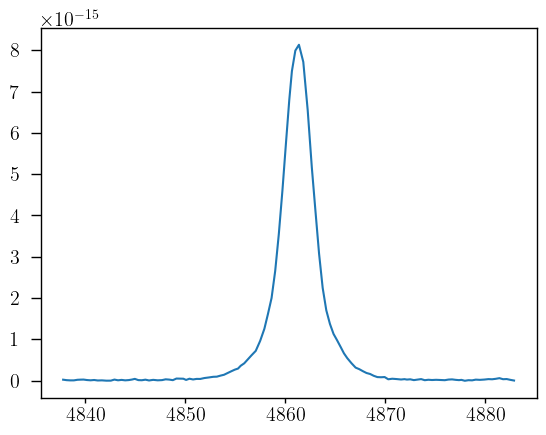

In [202]:
plt.plot(hbeta.wavelength, hbeta.flux)
#plt.xlim(4490, 4525)
#plt.axvline((1 + z_BN[igal])*wave_cat['Hd'], ls='--')
#plt.yscale('log')

---------

# Two component model fit for [OIII] 4959

In [203]:
wcal_blue.info()

Filename: /home/benjamin/Documents/pypeit18/redux_J0021/blue/magellan_mage_A/Calibrations/WaveCalib_A_0_DET01.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      13   ()      
  1  SPAT_IDS      1 ImageHDU        26   (12,)   int64   
  2  SPAT_ID-325_WAVEFIT    1 BinTableHDU     40   1R x 6C   [82D, 82D, 82J, 2048D, 2048D, 124D]   
  3  SPAT_ID-325_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [82D, 82D, 1K, 82D, 5D, 82K]   
  4  SPAT_ID-409_WAVEFIT    1 BinTableHDU     40   1R x 6C   [84D, 84D, 84J, 2048D, 2048D, 117D]   
  5  SPAT_ID-409_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [84D, 84D, 1K, 84D, 5D, 84K]   
  6  SPAT_ID-487_WAVEFIT    1 BinTableHDU     40   1R x 6C   [93D, 93D, 93J, 2048D, 2048D, 119D]   
  7  SPAT_ID-487_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [93D, 93D, 1K, 93D, 5D, 93K]   
  8  SPAT_ID-559_WAVEFIT    1 BinTableHDU     40   1R x 6C   [103D, 103D, 103J, 2048D, 2048D, 119D]   
  9  SPAT_ID-559_PYPEITFI

(0.0, 5000.0)

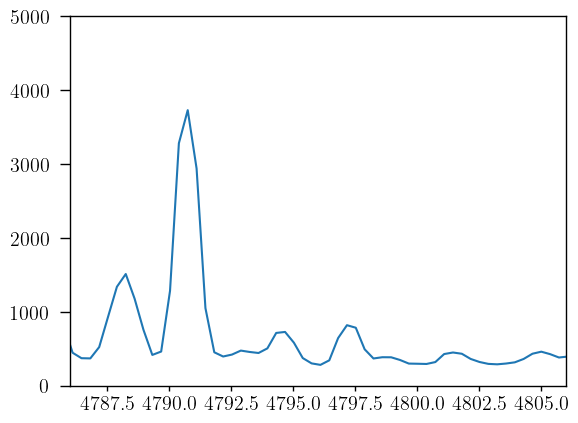

In [204]:
plt.plot(wcal_blue[10].data['wave_soln'][0], wcal_blue[27].data[:, 4])
plt.xlim(4786, 4806)
plt.ylim(0, 5000)

# [OIII]4959

### Arc lines

In [205]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_4959 = [wave_cat['[OIII]4959']*(1 + z_BN[igal]) - 10, wave_cat['[OIII]4959']*(1 + z_BN[igal]) + 10]
mask_arc_4959 = (wcal_red[8].data['wave_soln'][0] >= wlims_4959[0]) & (wcal_red[8].data['wave_soln'][0] < wlims_4959[1])

# Arc spectra around the fitted line
x_arc_4959 = wcal_red[8].data['wave_soln'][0][mask_arc_4959]
y_arc_4959 = wcal_red[21].data[:, 3][mask_arc_4959]

100%|███████████████████████████████████████| 2500/2500 [00:32<00:00, 77.83it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 87.69633754  40.85882209  80.94711054 116.26560408  60.67675518
  44.22286837  70.37254163  68.28266931]


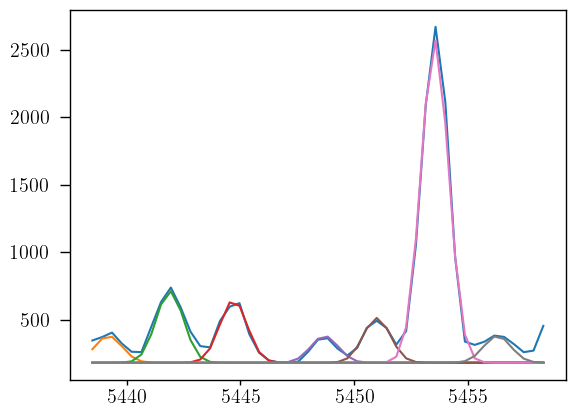

In [206]:
plt.plot(x_arc_4959, y_arc_4959)
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, 300, 5439.2, 0, 0.6))
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, 800, 5441.9, 0, 0.6))
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, 700, 5444.7, 0, 0.6))
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, 300, 5448.7, 0, 0.6))
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, 500, 5451, 0, 0.6))
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, 3600, 5453.55, 0, 0.6))
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, 300, 5456.3, 0, 0.6))

params_arc_4959 = Parameters()
params_arc_4959.add('z', value=0.0, vary=False)
params_arc_4959.add('mu1', value=5439.2, vary=False)
params_arc_4959.add('mu2', value=5441.9, vary=False)
params_arc_4959.add('mu3', value=5444.7, vary=False)
params_arc_4959.add('mu4', value=5448.7, vary=False)
params_arc_4959.add('mu5', value=5451, vary=False)
params_arc_4959.add('mu6', value=5453.55, vary=False)
params_arc_4959.add('mu7', value=5456.3, vary=False)
params_arc_4959.add('arc1', value=300, min=0.)
params_arc_4959.add('arc2', value=800, min=0.)
params_arc_4959.add('arc3', value=700, min=0.)
params_arc_4959.add('arc4', value=300, min=0.)
params_arc_4959.add('arc5', value=500, min=0.)
params_arc_4959.add('arc6', value=3600, min=0.)
params_arc_4959.add('arc7', value=300, min=0.)
params_arc_4959.add('sigma', value=0.7, min=0.)
params_arc_4959.add('bkg', value=180, vary=False)

def residual_arc_4959(params_arc_4959, x, data, uncertainty):
    
    z = params_arc_4959['z']
    mu1 = params_arc_4959['mu1']
    mu2 = params_arc_4959['mu2']
    mu3 = params_arc_4959['mu3']
    mu4 = params_arc_4959['mu4']
    mu5 = params_arc_4959['mu5']
    mu6 = params_arc_4959['mu6']
    mu7 = params_arc_4959['mu7']
    flux1 = params_arc_4959['arc1']
    flux2 = params_arc_4959['arc2']
    flux3 = params_arc_4959['arc3']
    flux4 = params_arc_4959['arc4']
    flux5 = params_arc_4959['arc5']
    flux6 = params_arc_4959['arc6']
    flux7 = params_arc_4959['arc7']
    sigma = params_arc_4959['sigma']
    bkg = params_arc_4959['bkg']
    
    x = x_arc_4959
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model6 = gaussian(x, flux6, mu6, z, sigma)
    model7 = gaussian(x, flux7, mu7, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5 + model6 + model7
    return (model - y_arc_4959) / 10

np.random.seed(21)
out_arc_4959 = minimize(residual_arc_4959, params_arc_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

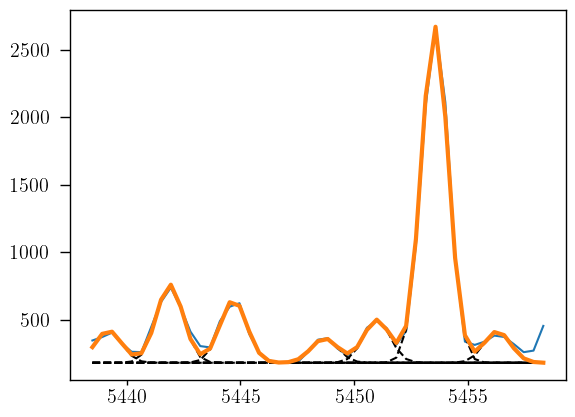

In [207]:
arc1_4959 = out_arc_4959.flatchain.arc1.mean()
arc2_4959 = out_arc_4959.flatchain.arc2.mean()
arc3_4959 = out_arc_4959.flatchain.arc3.mean()
arc4_4959 = out_arc_4959.flatchain.arc4.mean()
arc5_4959 = out_arc_4959.flatchain.arc5.mean()
arc6_4959 = out_arc_4959.flatchain.arc6.mean()
arc7_4959 = out_arc_4959.flatchain.arc7.mean()
sigma_arc_4959 = out_arc_4959.flatchain.sigma.mean()

plt.plot(x_arc_4959, y_arc_4959)

plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, arc1_4959, 5439.2, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, arc2_4959, 5441.9, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, arc3_4959, 5444.7, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, arc4_4959, 5448.7, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, arc5_4959, 5451, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, arc6_4959, 5453.55, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, arc7_4959, 5456.3, 0, sigma_arc_4959), ls='--', color='black')

plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, arc1_4959, 5439.2, 0, sigma_arc_4959) \
         + gaussian(x_arc_4959, arc2_4959, 5441.9, 0, sigma_arc_4959) \
         + gaussian(x_arc_4959, arc3_4959, 5444.7, 0, sigma_arc_4959) \
         + gaussian(x_arc_4959, arc4_4959, 5448.7, 0, sigma_arc_4959) \
         + gaussian(x_arc_4959, arc5_4959, 5451, 0, sigma_arc_4959) \
         + gaussian(x_arc_4959, arc6_4959, 5453.55, 0, sigma_arc_4959) \
         + gaussian(x_arc_4959, arc7_4959, 5456.3, 0, sigma_arc_4959), lw=3
)

### Line fitting

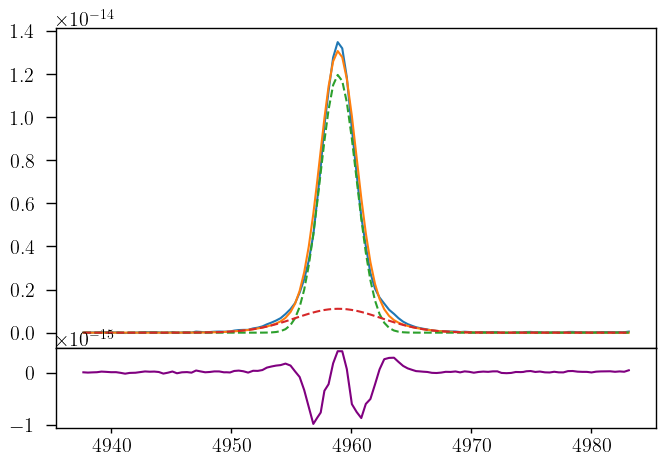

In [208]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4959.wavelength, oiii_4959.flux)

oiiib_nar = gaussian(oiii_4959.wavelength, 4500e-17, wave_cat['[OIII]4959'], z=0.0, sigma=1.5)
oiiib_brd = gaussian(oiii_4959.wavelength, 1000e-17, wave_cat['[OIII]4959'], z=0.0, sigma=3.6)

ax.plot(oiii_4959.wavelength, oiiib_nar + oiiib_brd)
ax.plot(oiii_4959.wavelength, oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - oiiib_nar - oiiib_brd, color='purple')
#ax.set_yscale('log')

In [209]:
params_oiii_4959 = Parameters()
params_oiii_4959.add('z_nar', value=0.0001)
params_oiii_4959.add('z_brd', value=0.0001)
params_oiii_4959.add('sigma_nar', value=1.5, min=0.)
params_oiii_4959.add('sigma_brd', value=3.6, min=0.)
params_oiii_4959.add('Oiiib_nar', value=4500e-17, min=0.)
params_oiii_4959.add('Oiiib_brd', value=1000e-17, min=0.)

def residual_oiii_4959(params_oiii_4959, x, data, uncertainty):
    
    z_nar = params_oiii_4959['z_nar']
    z_brd = params_oiii_4959['z_brd']
    sigma_nar = params_oiii_4959['sigma_nar']
    sigma_brd = params_oiii_4959['sigma_brd']
    oiiib_nar = params_oiii_4959['Oiiib_nar']
    oiiib_brd = params_oiii_4959['Oiiib_brd']
    
    x = oiii_4959.wavelength
    model = gaussian(x, oiiib_nar, wave_cat['[OIII]4959'], z_nar, sigma_nar) \
          + gaussian(x, oiiib_brd, wave_cat['[OIII]4959'], z_brd, sigma_brd)
    
    return (model - oiii_4959.flux) / oiii_4959.noise

In [210]:
np.random.seed(21)
out_oiii_4959 = minimize(residual_oiii_4959, params_oiii_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:16<00:00, 149.27it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 87.49714315 115.81211713  99.89407531 108.3865485  112.61343484
 118.57169538]


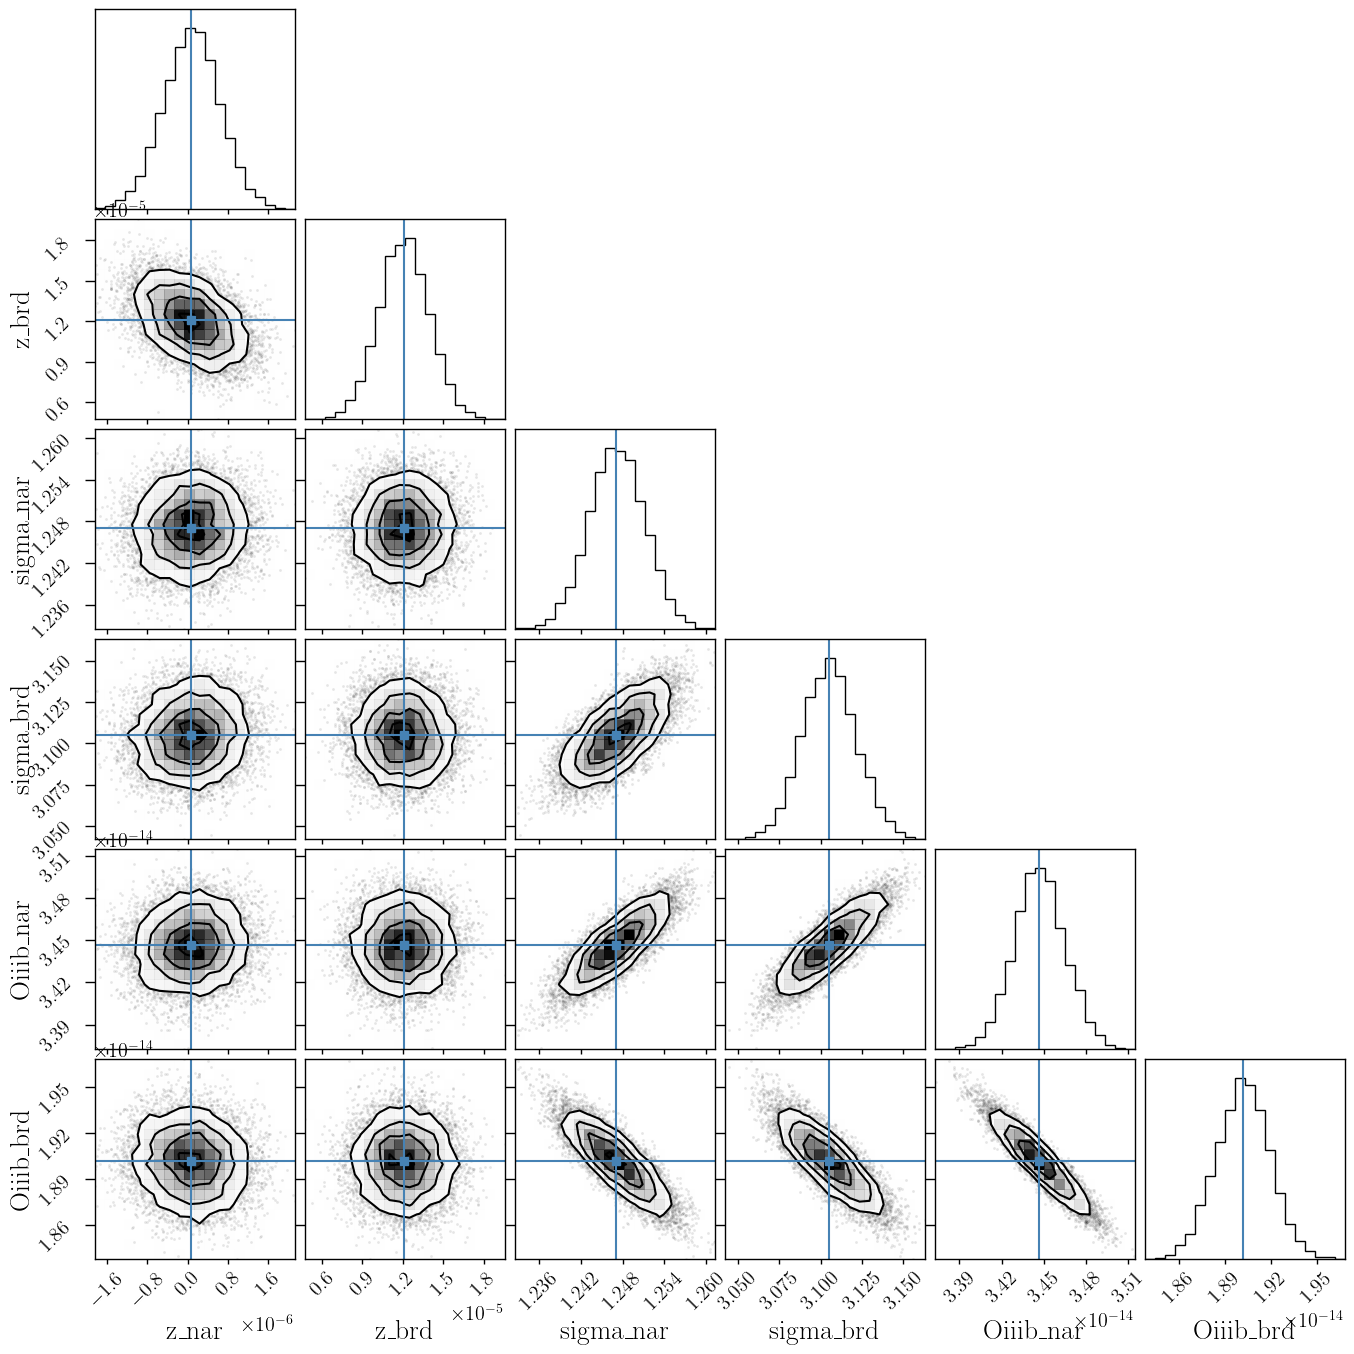

In [211]:
corner.corner(out_oiii_4959.flatchain, labels=out_oiii_4959.var_names,
             truths=list(out_oiii_4959.params.valuesdict().values()));
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [212]:
out_oiii_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,6.9561e-08,5.6243e-07,(808.55%),0.0001,-inf,inf,True
z_brd,1.2073e-05,1.8451e-06,(15.28%),0.0001,-inf,inf,True
sigma_nar,1.24710508,0.00398588,(0.32%),1.5,0.00000000,inf,True
sigma_brd,3.10511715,0.01635569,(0.53%),3.6,0.00000000,inf,True
Oiiib_nar,3.4465e-14,1.8111e-16,(0.53%),4.5e-14,0.00000000,inf,True
Oiiib_brd,1.9019e-14,1.7626e-16,(0.93%),1e-14,0.00000000,inf,True


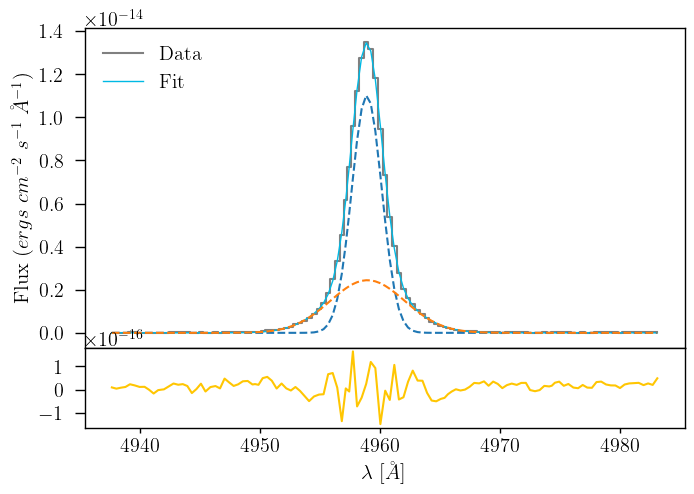

In [213]:
oiiib_nar_flux = out_oiii_4959.flatchain.Oiiib_nar.mean()
oiiib_nar_std = out_oiii_4959.flatchain.Oiiib_nar.std()

oiiib_brd_flux = out_oiii_4959.flatchain.Oiiib_brd.mean()
oiiib_brd_std = out_oiii_4959.flatchain.Oiiib_brd.std()

z_nar_oiii_4959 = out_oiii_4959.flatchain.z_nar.mean()
z_nar_oiii_4959_std = out_oiii_4959.flatchain.z_nar.std()

z_brd_oiii_4959 = out_oiii_4959.flatchain.z_brd.mean()
z_brd_oiii_4959_std = out_oiii_4959.flatchain.z_brd.std()

sigma_nar_oiii_4959 = out_oiii_4959.flatchain.sigma_nar.mean()
sigma_nar_oiii_4959_std = out_oiii_4959.flatchain.sigma_nar.std()

sigma_brd_oiii_4959 = out_oiii_4959.flatchain.sigma_brd.mean()
sigma_brd_oiii_4959_std = out_oiii_4959.flatchain.sigma_brd.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4959.wavelength, oiii_4959.flux,
            color='gray', label='Data', where='mid')

oiiib_nar = gaussian(oiii_4959.wavelength, oiiib_nar_flux, wave_cat['[OIII]4959'], z_nar_oiii_4959, sigma_nar_oiii_4959)
oiiib_brd = gaussian(oiii_4959.wavelength, oiiib_brd_flux, wave_cat['[OIII]4959'], z_brd_oiii_4959, sigma_brd_oiii_4959)
oiiib = oiiib_nar + oiiib_brd

ax.plot(oiii_4959.wavelength, oiiib,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_4959.wavelength, oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - oiiib,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.legend(loc='upper left')

In [214]:
# Correcting sigma by instrumental broadening

# Intrinsic from the galaxy
sigma_nar_intrinsic = upy.sqrt((ufloat(sigma_nar_oiii_4959, sigma_nar_oiii_4959_std)**2) - (sigma_arc_4959**2))
sigma_brd_intrinsic = upy.sqrt((ufloat(sigma_brd_oiii_4959, sigma_brd_oiii_4959_std)**2) - (sigma_arc_4959**2)) 

In [215]:
# FWHM
FWHM_4959_nar = FWHM(sigma_nar_intrinsic, wave_cat['[OIII]4959']*(1 + ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std)))
FWHM_4959_brd = FWHM(sigma_brd_intrinsic, wave_cat['[OIII]4959']*(1 + ufloat(z_brd_oiii_4959, z_brd_oiii_4959_std)))

# velocity shift
dV_4959 = dV(ufloat(z_brd_oiii_4959, z_brd_oiii_4959_std),
             ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std))

# Ratio to fix velocity shifts between components
z_ratio = z_brd_oiii_4959 / z_nar_oiii_4959

# Ratio to distribute the flux between components in no detection
brd_to_nar = oiiib_brd_flux / oiiib_nar_flux

# Dispersion for the whole spectra
dLam = (np.max(wave) - np.min(wave)) / len(wave)

In [216]:
print('Redshift of the narrow component: {:.4f}'.format(ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std)))

Redshift of the narrow component: 0.0000+/-0.0000


In [217]:
dLam

0.4591951112867424

# [NII]6548 + H$\alpha$ + [NII]6584

### Arc lines

In [218]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_ha = [wave_cat['Ha']*(1 + z_BN[igal]) - 10, wave_cat['Ha']*(1 + z_BN[igal]) + 10]
mask_arc_ha = (wcal_red[12].data['wave_soln'][0] >= wlims_ha[0]) & (wcal_red[12].data['wave_soln'][0] < wlims_ha[1])

# Arc spectra around the fitted line
x_arc_ha = wcal_red[12].data['wave_soln'][0][mask_arc_ha]
y_arc_ha = wcal_red[21].data[:, 5][mask_arc_ha]

100%|███████████████████████████████████████| 2500/2500 [00:26<00:00, 95.55it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [91.41069451 50.79096291 75.65013989 86.51923111 19.68615736 66.6185604 ]


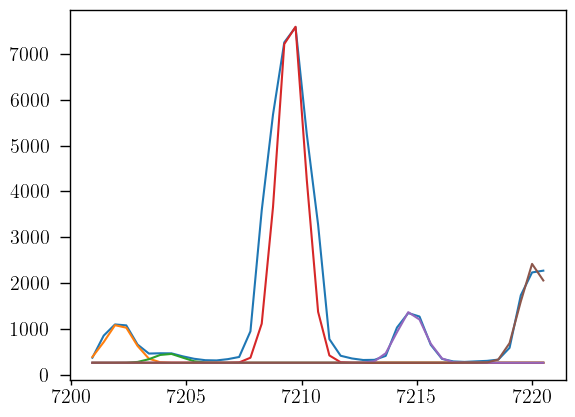

In [219]:
plt.plot(x_arc_ha, y_arc_ha)
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, 1300, 7202.1, 0, 0.6))
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, 300, 7204.2, 0, 0.6))
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, 11700, 7209.53, 0, 0.6))
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, 1700, 7214.75, 0, 0.6))
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, 3300, 7220.1, 0, 0.6))

params_arc_ha = Parameters()
params_arc_ha.add('z', value=0.0, vary=False)
params_arc_ha.add('mu1', value=7202.1, vary=False)
params_arc_ha.add('mu2', value=7204.2, vary=False)
params_arc_ha.add('mu3', value=7209.53, vary=False)
params_arc_ha.add('mu4', value=7214.75, vary=False)
params_arc_ha.add('mu5', value=7220.1, vary=False)
params_arc_ha.add('arc1', value=1300, min=0.)
params_arc_ha.add('arc2', value=300, min=0.)
params_arc_ha.add('arc3', value=11700, min=0.)
params_arc_ha.add('arc4', value=1700, min=0.)
params_arc_ha.add('arc5', value=3300, min=0.)
params_arc_ha.add('sigma', value=0.6, min=0.)
params_arc_ha.add('bkg', value=260, vary=False)

def residual_arc_ha(params_arc_ha, x, data, uncertainty):
    
    z = params_arc_ha['z']
    mu1 = params_arc_ha['mu1']
    mu2 = params_arc_ha['mu2']
    mu3 = params_arc_ha['mu3']
    mu4 = params_arc_ha['mu4']
    mu5 = params_arc_ha['mu5']
    flux1 = params_arc_ha['arc1']
    flux2 = params_arc_ha['arc2']
    flux3 = params_arc_ha['arc3']
    flux4 = params_arc_ha['arc4']
    flux5 = params_arc_ha['arc5']
    sigma = params_arc_ha['sigma']
    bkg = params_arc_ha['bkg']
    
    x = x_arc_ha
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5
    return (model - y_arc_ha) / 10

np.random.seed(21)
out_arc_ha = minimize(residual_arc_ha, params_arc_ha, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

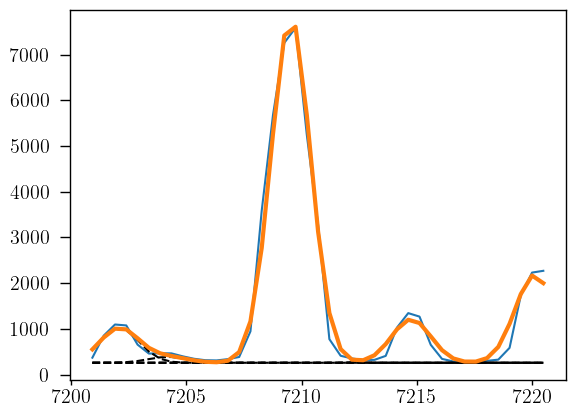

In [220]:
arc1_ha = out_arc_ha.flatchain.arc1.mean()
arc2_ha = out_arc_ha.flatchain.arc2.mean()
arc3_ha = out_arc_ha.flatchain.arc3.mean()
arc4_ha = out_arc_ha.flatchain.arc4.mean()
arc5_ha = out_arc_ha.flatchain.arc5.mean()
sigma_arc_ha = out_arc_ha.flatchain.sigma.mean()

plt.plot(x_arc_ha, y_arc_ha)

plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, arc1_ha, 7202.1, 0, sigma_arc_ha), ls='--', color='black')
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, arc2_ha, 7204.2, 0, sigma_arc_ha), ls='--', color='black')
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, arc3_ha, 7209.53, 0, sigma_arc_ha), ls='--', color='black')
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, arc4_ha, 7214.75, 0, sigma_arc_ha), ls='--', color='black')
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, arc5_ha, 7220.1, 0, sigma_arc_ha), ls='--', color='black')

plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, arc1_ha, 7202.1, 0, sigma_arc_ha) \
         + gaussian(x_arc_ha, arc2_ha, 7204.2, 0, sigma_arc_ha) \
         + gaussian(x_arc_ha, arc3_ha, 7209.53, 0, sigma_arc_ha) \
         + gaussian(x_arc_ha, arc4_ha, 7214.75, 0, sigma_arc_ha) \
         + gaussian(x_arc_ha, arc5_ha, 7220.1, 0, sigma_arc_ha), lw=3
)

### Line fitting

In [221]:
sigma_nar_ha = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_ha**2))
sigma_brd_ha = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_ha**2))

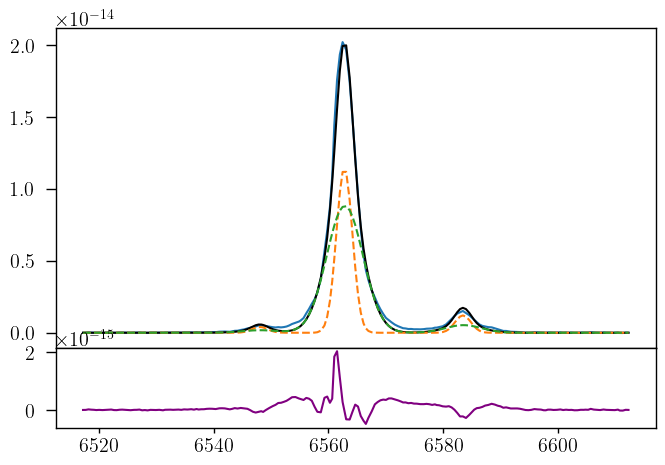

In [222]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ha_nii.wavelength, ha_nii.flux)

ha_nar = gaussian(ha_nii.wavelength, 4e-14, wave_cat['Ha'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
ha_brd = gaussian(ha_nii.wavelength, 7e-14, wave_cat['Ha'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

niib_nar = gaussian(ha_nii.wavelength, 1.4e-15, wave_cat['[NII]6548'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
niib_brd = gaussian(ha_nii.wavelength, 1.4e-15, wave_cat['[NII]6548'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

niia_nar = gaussian(ha_nii.wavelength, 4.2e-15, wave_cat['[NII]6584'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_ha))
niia_brd = gaussian(ha_nii.wavelength, 4.2e-15, wave_cat['[NII]6584'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_ha))

ha = ha_nar + ha_brd
niib = niib_nar + niib_brd
niia = niia_nar + niia_brd

ax.plot(ha_nii.wavelength, niib + ha + niia, color='black')
ax.plot(ha_nii.wavelength, niib_nar + ha_nar + niia_nar, ls='--')
ax.plot(ha_nii.wavelength, niib_brd + ha_brd + niia_brd, ls='--')
ax1.plot(ha_nii.wavelength, ha_nii.flux - niib - ha - niia, color='purple')

#ax.axvline(7175)
#ax.axvline(7247)
#ax.set_yscale('log')

In [223]:
params_ha_nii = Parameters()
params_ha_nii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_ha_nii.add('z_ratio', value=z_ratio, vary=False)
params_ha_nii.add('sigma_6584_nar', value=upy.nominal_values(sigma_nar_ha), vary=False)
params_ha_nii.add('sigma_6584_brd', value=upy.nominal_values(sigma_brd_ha), vary=False)
params_ha_nii.add('sigma_ha_nar', value=upy.nominal_values(sigma_nar_ha), vary=False)
params_ha_nii.add('sigma_ha_brd', value=upy.nominal_values(sigma_brd_ha), vary=False)
params_ha_nii.add('sigma_6548_nar', value=upy.nominal_values(sigma_nar_ha), vary=False)
params_ha_nii.add('sigma_6548_brd', value=upy.nominal_values(sigma_brd_ha), vary=False)
params_ha_nii.add('Ha_nar', value=4e-14, min=0.)
params_ha_nii.add('Ha_brd', value=7e-14, min=0.)
params_ha_nii.add('Niia_nar', value=4.2e-15, min=0.)
params_ha_nii.add('Niia_brd', value=4.2e-15, min=0.)
params_ha_nii.add('Niib_to_niia', value=1/3, min=0., max=1.)

def residual_ha_nii(params_ha_nii, x, data, uncertainty):
    
    z_nar = params_ha_nii['z_nar']
    z_brd = params_ha_nii['z_nar'] * params_ha_nii['z_ratio']
    sigma_6584_nar = params_ha_nii['sigma_6584_nar']
    sigma_6584_brd = params_ha_nii['sigma_6584_brd']
    sigma_ha_nar = params_ha_nii['sigma_ha_nar']
    sigma_ha_brd = params_ha_nii['sigma_ha_brd']
    sigma_6548_nar = params_ha_nii['sigma_6548_nar']
    sigma_6548_brd = params_ha_nii['sigma_6548_brd']
    ha_nar = params_ha_nii['Ha_nar']
    ha_brd = params_ha_nii['Ha_brd']
    niia_nar = params_ha_nii['Niia_nar']
    niia_brd = params_ha_nii['Niia_brd']
    niib_nar = params_ha_nii['Niia_nar']*params_ha_nii['Niib_to_niia']
    niib_brd = params_ha_nii['Niia_brd']*params_ha_nii['Niib_to_niia']
    
    x = ha_nii.wavelength
    
    model_ha = gaussian(x, ha_nar, wave_cat['Ha'], z_nar, sigma_ha_nar) \
             + gaussian(x, ha_brd, wave_cat['Ha'], z_brd, sigma_ha_brd)
    
    model_niia = gaussian(x, niia_nar, wave_cat['[NII]6584'], z_nar, sigma_6584_nar) \
               + gaussian(x, niia_brd, wave_cat['[NII]6584'], z_brd, sigma_6584_brd)
    
    model_niib = gaussian(x, niib_nar, wave_cat['[NII]6548'], z_nar, sigma_6548_nar) \
               + gaussian(x, niib_brd, wave_cat['[NII]6548'], z_brd, sigma_6548_brd)
    model = model_niib + model_ha + model_niia
    
    return (model - ha_nii.flux) / ha_nii.noise

In [224]:
np.random.seed(21)
out_ha_nii = minimize(residual_ha_nii, params_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1000, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:33<00:00, 75.37it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 95.09788179  33.86698479 102.04405494 148.1665402  147.96195368
 158.39613674]


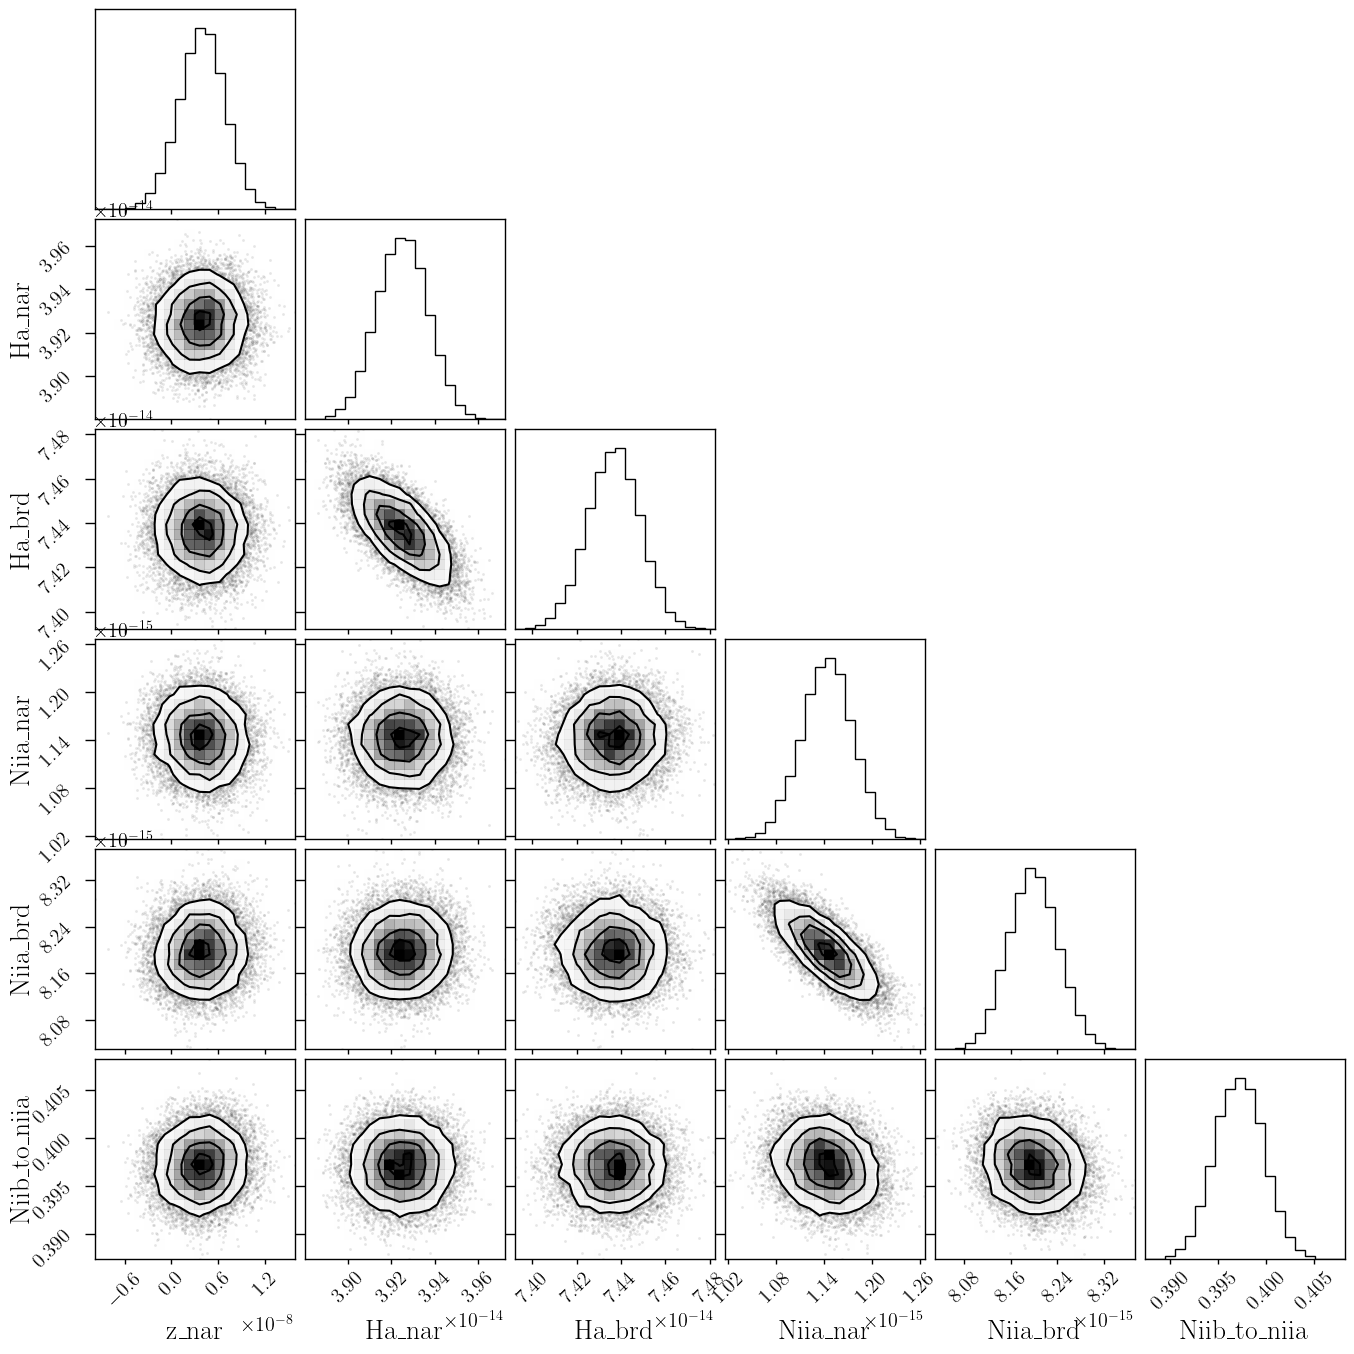

In [225]:
corner.corner(out_ha_nii.flatchain, labels=out_ha_nii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [226]:
out_ha_nii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,3.9096e-09,2.9400e-09,(75.20%),6.760336358548223e-08,-inf,inf,True
z_ratio,178.554400,,,178.55439986698758,-inf,inf,False
sigma_6584_nar,1.39088599,,,1.390885994136678,-inf,inf,False
sigma_6584_brd,3.16571912,,,3.16571912222556,-inf,inf,False
sigma_ha_nar,1.39088599,,,1.390885994136678,-inf,inf,False
sigma_ha_brd,3.16571912,,,3.16571912222556,-inf,inf,False
sigma_6548_nar,1.39088599,,,1.390885994136678,-inf,inf,False
sigma_6548_brd,3.16571912,,,3.16571912222556,-inf,inf,False
Ha_nar,3.9249e-14,1.1779e-16,(0.30%),4e-14,0.00000000,inf,True
Ha_brd,7.4366e-14,1.1820e-16,(0.16%),7e-14,0.00000000,inf,True


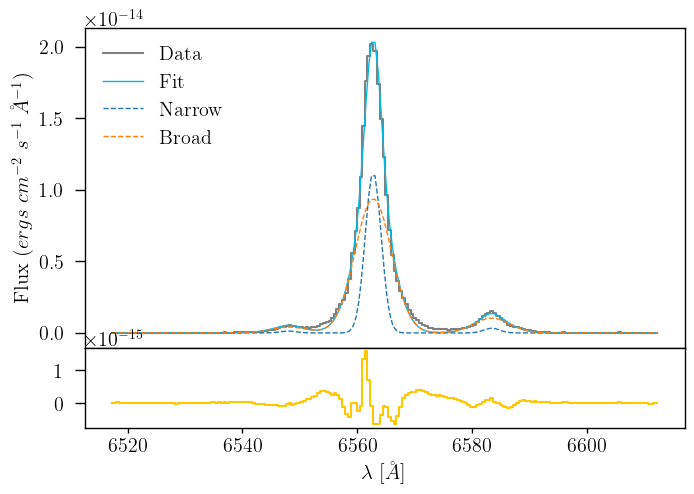

In [227]:
ha_nar_flux = out_ha_nii.flatchain.Ha_nar.mean()
ha_nar_std = out_ha_nii.flatchain.Ha_nar.std()

ha_brd_flux = out_ha_nii.flatchain.Ha_brd.mean()
ha_brd_std = out_ha_nii.flatchain.Ha_brd.std()

niia_nar_flux = out_ha_nii.flatchain.Niia_nar.mean()
niia_nar_std = out_ha_nii.flatchain.Niia_nar.std()

niia_brd_flux = out_ha_nii.flatchain.Niia_brd.mean()
niia_brd_std = out_ha_nii.flatchain.Niia_brd.std()

niib_nar_flux = (niia_nar_flux * out_ha_nii.flatchain.Niib_to_niia).mean()
niib_nar_std = (niia_nar_flux * out_ha_nii.flatchain.Niib_to_niia).std()

niib_brd_flux = (niia_brd_flux * out_ha_nii.flatchain.Niib_to_niia).mean()
niib_brd_std = (niia_brd_flux * out_ha_nii.flatchain.Niib_to_niia).std()

z_ha_nii = out_ha_nii.flatchain.z_nar.mean()
z_ha_nii_std = out_ha_nii.flatchain.z_nar.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(ha_nii.wavelength, ha_nii.flux,
            color='gray', label='Data', where='mid')

ha_nar = gaussian(ha_nii.wavelength, ha_nar_flux, wave_cat['Ha'], z_ha_nii, upy.nominal_values(sigma_nar_ha))
ha_brd = gaussian(ha_nii.wavelength, ha_brd_flux, wave_cat['Ha'], z_ha_nii * z_ratio, upy.nominal_values(sigma_brd_ha))

niia_nar = gaussian(ha_nii.wavelength, niia_nar_flux, wave_cat['[NII]6584'], z_ha_nii, upy.nominal_values(sigma_nar_ha))
niia_brd = gaussian(ha_nii.wavelength, niia_brd_flux, wave_cat['[NII]6584'], z_ha_nii * z_ratio, upy.nominal_values(sigma_brd_ha))

niib_nar = gaussian(ha_nii.wavelength, niib_nar_flux, wave_cat['[NII]6548'], z_ha_nii, upy.nominal_values(sigma_nar_ha))
niib_brd = gaussian(ha_nii.wavelength, niib_brd_flux, wave_cat['[NII]6548'], z_ha_nii * z_ratio, upy.nominal_values(sigma_brd_ha))

niia = niia_nar + niia_brd
ha = ha_nar + ha_brd
niib = niib_nar + niib_brd

ax.plot(ha_nii.wavelength, niia + ha + niib,
        lw=1, color=c[0], label='Fit')

ax.plot(ha_nii.wavelength, niia_nar + ha_nar + niib_nar,
        ls='--', lw=1, label='Narrow')
ax.plot(ha_nii.wavelength, niia_brd + ha_brd + niib_brd,
        ls='--', lw=1, label='Broad')

ax1.step(ha_nii.wavelength, ha_nii.flux - niia - ha - niib,
         color=c[3], where='mid')
#ax1.set_ylim(-5*bkg_ha_nii, 5*bkg_ha_nii)
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
#ax.set_yscale('log')
ax.legend(loc='upper left')

# [OII]7319 + [OII]7330

### Arc lines

In [57]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_7330 = [wave_cat['[OII]7330']*(1 + z_BN[igal]) - 10, wave_cat['[OII]7330']*(1 + z_BN[igal]) + 10]
mask_arc_7330 = (wcal_red[14].data['wave_soln'][0] >= wlims_7330[0]) & (wcal_red[14].data['wave_soln'][0] < wlims_7330[1])

# Arc spectra around the fitted line
x_arc_7330 = wcal_red[14].data['wave_soln'][0][mask_arc_7330]
y_arc_7330 = wcal_red[21].data[:, 6][mask_arc_7330]

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 121.96it/s]


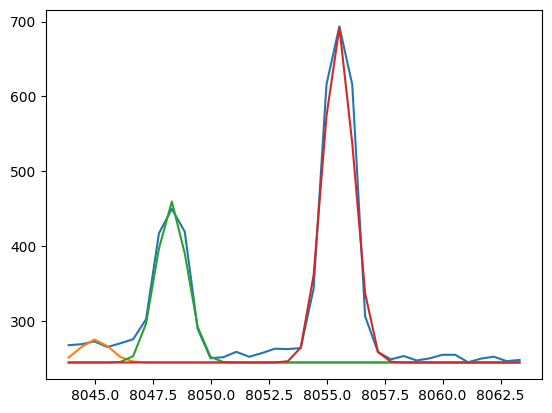

In [58]:
plt.plot(x_arc_7330, y_arc_7330)
plt.plot(x_arc_7330, 245 + gaussian(x_arc_7330, 50, 8045, 0, 0.65))
plt.plot(x_arc_7330, 245 + gaussian(x_arc_7330, 350, 8048.3, 0, 0.65))
plt.plot(x_arc_7330, 245 + gaussian(x_arc_7330, 730, 8055.5, 0, 0.65))

params_arc_7330 = Parameters()
params_arc_7330.add('z', value=0.0, vary=False)
params_arc_7330.add('mu1', value=8045, vary=False)
params_arc_7330.add('mu2', value=8048.3, vary=False)
params_arc_7330.add('mu3', value=8055.5, vary=False)
params_arc_7330.add('arc1', value=50, min=0.)
params_arc_7330.add('arc2', value=350, min=0.)
params_arc_7330.add('arc3', value=730, min=0.)
params_arc_7330.add('sigma', value=0.65, min=0.)
params_arc_7330.add('bkg', value=245, vary=False)

def residual_arc_7330(params_arc_7330, x, data, uncertainty):
    
    z = params_arc_7330['z']
    mu1 = params_arc_7330['mu1']
    mu2 = params_arc_7330['mu2']
    mu3 = params_arc_7330['mu3']
    flux1 = params_arc_7330['arc1']
    flux2 = params_arc_7330['arc2']
    flux3 = params_arc_7330['arc3']
    sigma = params_arc_7330['sigma']
    bkg = params_arc_7330['bkg']
    
    x = x_arc_7330
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_7330) / 10

np.random.seed(21)
out_arc_7330 = minimize(residual_arc_7330, params_arc_7330, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

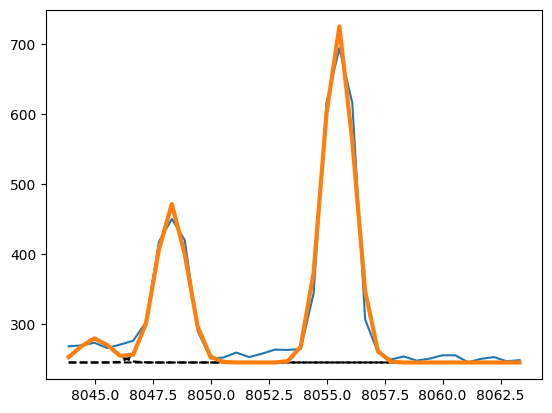

In [59]:
arc1_7330 = out_arc_7330.flatchain.arc1.mean()
arc2_7330 = out_arc_7330.flatchain.arc2.mean()
arc3_7330 = out_arc_7330.flatchain.arc3.mean()
sigma_arc_7330 = out_arc_7330.flatchain.sigma.mean()

plt.plot(x_arc_7330, y_arc_7330)

plt.plot(x_arc_7330, 245 + gaussian(x_arc_7330, arc1_7330, 8045, 0, sigma_arc_7330), ls='--', color='black')
plt.plot(x_arc_7330, 245 + gaussian(x_arc_7330, arc2_7330, 8048.3, 0, sigma_arc_7330), ls='--', color='black')
plt.plot(x_arc_7330, 245 + gaussian(x_arc_7330, arc3_7330, 8055.5, 0, sigma_arc_7330), ls='--', color='black')

plt.plot(x_arc_7330, 245 + gaussian(x_arc_7330, arc1_7330, 8045, 0, sigma_arc_7330) \
         + gaussian(x_arc_7330, arc2_7330, 8048.3, 0, sigma_arc_7330) \
         + gaussian(x_arc_7330, arc3_7330, 8055.5, 0, sigma_arc_7330), lw=3
)

### Line fitting

In [60]:
sigma_nar_7330 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_7330**2))
sigma_brd_7330 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_7330**2))

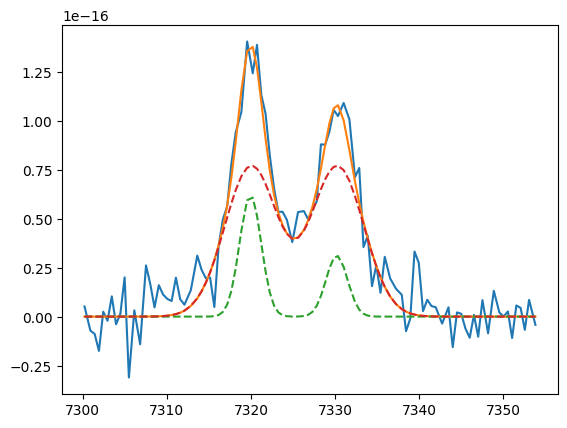

In [62]:
# Search for good initial guess

plt.plot(oii_7320.wavelength, oii_7320.flux)

oiia_nar = gaussian(oii_7320.wavelength, 1e-16, wave_cat['[OII]7330'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7330))
oiia_brd = gaussian(oii_7320.wavelength, 6e-16, wave_cat['[OII]7330'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7330))

oiib_nar = gaussian(oii_7320.wavelength, 2e-16, wave_cat['[OII]7319'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_7330))
oiib_brd = gaussian(oii_7320.wavelength, 6e-16, wave_cat['[OII]7319'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_7330))

oiia = oiia_nar + oiia_brd
oiib = oiib_nar + oiib_brd

plt.plot(oii_7320.wavelength, oiib + oiia)
plt.plot(oii_7320.wavelength, oiib_nar + oiia_nar, ls='--')
plt.plot(oii_7320.wavelength, oiib_brd + oiia_brd, ls='--')

#plt.yscale('log')

In [63]:
params_oii_7320 = Parameters()

params_oii_7320.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oii_7320.add('z_ratio', value=z_ratio, vary=False)
params_oii_7320.add('sigma_7330_nar', value=upy.nominal_values(sigma_nar_7330), vary=False)
params_oii_7320.add('sigma_7330_brd', value=upy.nominal_values(sigma_brd_7330), vary=False)
params_oii_7320.add('sigma_7319_nar', value=upy.nominal_values(sigma_nar_7330), vary=False)
params_oii_7320.add('sigma_7319_brd', value=upy.nominal_values(sigma_brd_7330), vary=False)
params_oii_7320.add('Oiia_nar', value=1.0e-16, min=0.)
params_oii_7320.add('Oiia_brd', value=6.0e-16, min=0.)
params_oii_7320.add('Oiib_nar', value=2.0e-16, min=0.)
params_oii_7320.add('Oiib_brd', value=6.0e-16, min=0.)

def residual_oii_7320(params_oii_7320, x, data, uncertainty):
    
    z_nar = params_oii_7320['z_nar']
    z_brd = params_oii_7320['z_nar'] * params_oii_7320['z_ratio']
    sigma_7330_nar = params_oii_7320['sigma_7330_nar']
    sigma_7330_brd = params_oii_7320['sigma_7330_brd']
    sigma_7319_nar = params_oii_7320['sigma_7319_nar']
    sigma_7319_brd = params_oii_7320['sigma_7319_brd']
    oiia_nar_flux = params_oii_7320['Oiia_nar']
    oiia_brd_flux = params_oii_7320['Oiia_brd']
    oiib_nar_flux = params_oii_7320['Oiib_nar']
    oiib_brd_flux = params_oii_7320['Oiib_brd']
    
    x = oii_7320.wavelength
    model_oiia = gaussian(x, oiia_nar_flux, wave_cat['[OII]7330'], z_nar, sigma_7330_nar) + \
                 gaussian(x, oiia_brd_flux, wave_cat['[OII]7330'], z_brd, sigma_7330_brd)
    model_oiib = gaussian(x, oiib_nar_flux, wave_cat['[OII]7319'], z_nar, sigma_7319_nar) + \
                 gaussian(x, oiib_brd_flux, wave_cat['[OII]7319'], z_brd, sigma_7319_brd)
    model = model_oiia + model_oiib
    return (model - oii_7320.flux) / oii_7320.noise

In [64]:
np.random.seed(21)
out_oii_7320 = minimize(residual_oii_7320, params_oii_7320, args=(1, 1, 1),
                         method='emcee', burn=1000, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:23<00:00, 106.61it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [48.37895796 48.60194245 52.17962295 45.96423579 45.59815918]


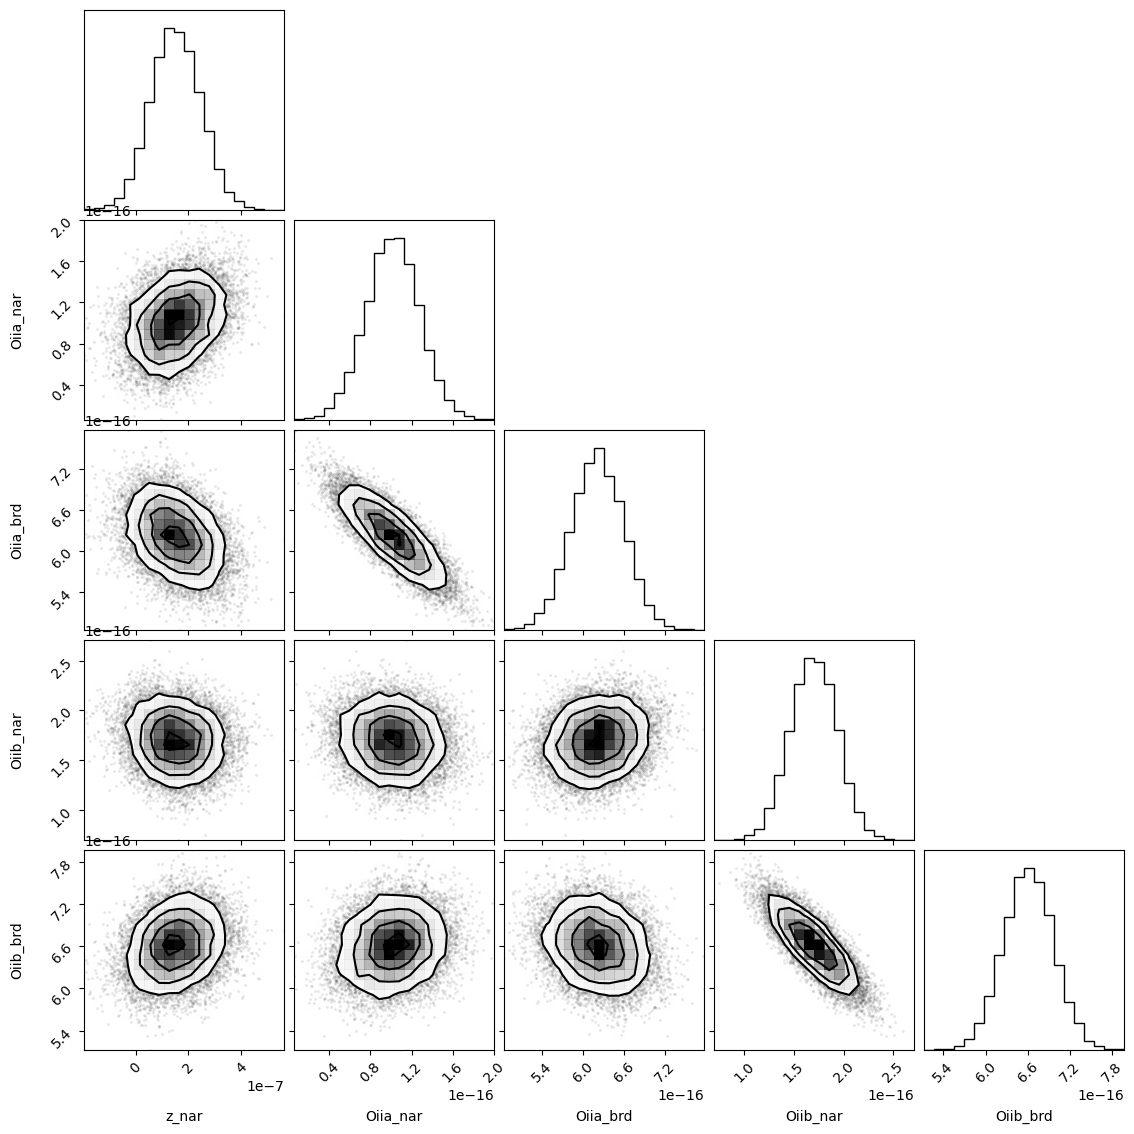

In [65]:
corner.corner(out_oii_7320.flatchain, labels=out_oii_7320.var_names);

In [66]:
out_oii_7320.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,1.5108e-07,9.3433e-08,(61.84%),6.760336358548223e-08,-inf,inf,True
z_ratio,178.554400,,,178.55439986698758,-inf,inf,False
sigma_7330_nar,1.28208179,,,1.2820817865193987,-inf,inf,False
sigma_7330_brd,3.11944665,,,3.1194466527677256,-inf,inf,False
sigma_7319_nar,1.28208179,,,1.2820817865193987,-inf,inf,False
sigma_7319_brd,3.11944665,,,3.1194466527677256,-inf,inf,False
Oiia_nar,1.0174e-16,2.5734e-17,(25.30%),1e-16,0.00000000,inf,True
Oiia_brd,6.2178e-16,3.8210e-17,(6.15%),6e-16,0.00000000,inf,True
Oiib_nar,1.6988e-16,2.3420e-17,(13.79%),2e-16,0.00000000,inf,True
Oiib_brd,6.6129e-16,3.5486e-17,(5.37%),6e-16,0.00000000,inf,True


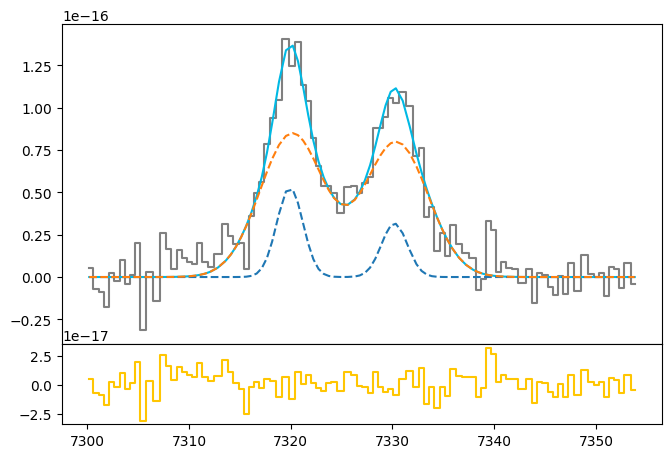

In [67]:
oiia_nar_flux = out_oii_7320.flatchain.Oiia_nar.mean()
oiia_nar_std = out_oii_7320.flatchain.Oiia_nar.std()

oiia_brd_flux = out_oii_7320.flatchain.Oiia_brd.mean()
oiia_brd_std = out_oii_7320.flatchain.Oiia_brd.std()

oiib_nar_flux = out_oii_7320.flatchain.Oiib_nar.mean()
oiib_nar_std = out_oii_7320.flatchain.Oiib_nar.std()

oiib_brd_flux = out_oii_7320.flatchain.Oiib_brd.mean()
oiib_brd_std = out_oii_7320.flatchain.Oiib_brd.std()

z_oii_7320 = out_oii_7320.flatchain.z_nar.mean()
z_oii_7320_std = out_oii_7320.flatchain.z_nar.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oii_7320.wavelength, oii_7320.flux, color='gray', label='Data', where='mid')

oiia_nar = gaussian(oii_7320.wavelength, oiia_nar_flux, wave_cat['[OII]7330'], z_oii_7320, upy.nominal_values(sigma_nar_7330))
oiib_nar = gaussian(oii_7320.wavelength, oiib_nar_flux, wave_cat['[OII]7319'], z_oii_7320, upy.nominal_values(sigma_nar_7330))

oiia_brd = gaussian(oii_7320.wavelength, oiia_brd_flux, wave_cat['[OII]7330'], z_oii_7320 * z_ratio, upy.nominal_values(sigma_brd_7330))
oiib_brd = gaussian(oii_7320.wavelength, oiib_brd_flux, wave_cat['[OII]7319'], z_oii_7320 * z_ratio, upy.nominal_values(sigma_brd_7330))

oiia = oiia_nar + oiia_brd
oiib = oiib_nar + oiib_brd

ax.plot(oii_7320.wavelength, oiia + oiib, color=c[0])
ax.plot(oii_7320.wavelength, oiia_nar + oiib_nar, ls='--')
ax.plot(oii_7320.wavelength, oiia_brd + oiib_brd, ls='--')
#plt.yscale('log')
ax1.step(oii_7320.wavelength, oii_7320.flux - oiia - oiib, color=c[3], where='mid')

# [SII]6716 + [SII]6730

### Arc lines

In [68]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_6730 = [wave_cat['[SII]6730']*(1 + z_BN[igal]) - 5, wave_cat['[SII]6730']*(1 + z_BN[igal]) + 20]
mask_arc_6730 = (wcal_red[14].data['wave_soln'][0] >= wlims_6730[0]) & (wcal_red[14].data['wave_soln'][0] < wlims_6730[1])

# Arc spectra around the fitted line
x_arc_6730 = wcal_red[14].data['wave_soln'][0][mask_arc_6730]
y_arc_6730 = wcal_red[21].data[:, 6][mask_arc_6730]

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 121.48it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [56.19851786 70.01279174 70.58865673 59.99323256]


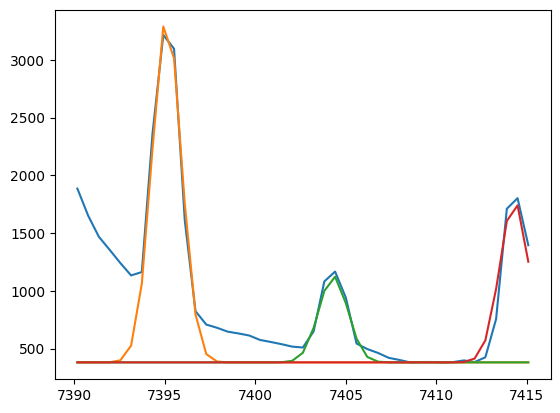

In [69]:
plt.plot(x_arc_6730, y_arc_6730)
plt.plot(x_arc_6730, 380 + gaussian(x_arc_6730, 6000, 7395.1, 0, 0.8))
plt.plot(x_arc_6730, 380 + gaussian(x_arc_6730, 1500, 7404.3, 0, 0.8))
plt.plot(x_arc_6730, 380 + gaussian(x_arc_6730, 2800, 7414.3, 0, 0.8))

params_arc_6730 = Parameters()
params_arc_6730.add('z', value=0.0, vary=False)
params_arc_6730.add('mu1', value=7395.1, vary=False)
params_arc_6730.add('mu2', value=7404.3, vary=False)
params_arc_6730.add('mu3', value=7414.3, vary=False)
params_arc_6730.add('arc1', value=6000, min=0.)
params_arc_6730.add('arc2', value=1500, min=0.)
params_arc_6730.add('arc3', value=2800, min=0.)
params_arc_6730.add('sigma', value=0.8, min=0.)
params_arc_6730.add('bkg', value=380, vary=False)

def residual_arc_6730(params_arc_6730, x, data, uncertainty):
    
    z = params_arc_6730['z']
    mu1 = params_arc_6730['mu1']
    mu2 = params_arc_6730['mu2']
    mu3 = params_arc_6730['mu3']
    flux1 = params_arc_6730['arc1']
    flux2 = params_arc_6730['arc2']
    flux3 = params_arc_6730['arc3']
    sigma = params_arc_6730['sigma']
    bkg = params_arc_6730['bkg']
    
    x = x_arc_6730
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_6730) / 10

np.random.seed(21)
out_arc_6730 = minimize(residual_arc_6730, params_arc_6730, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

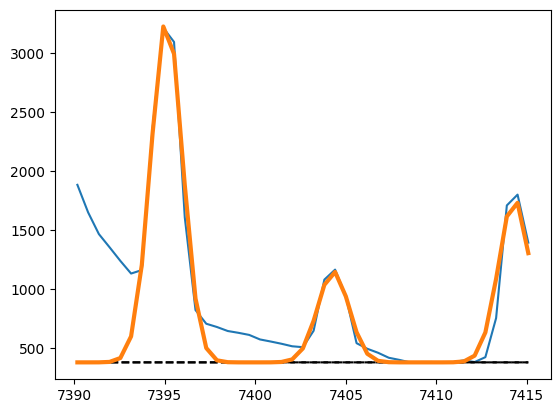

In [70]:
arc1_6730 = out_arc_6730.flatchain.arc1.mean()
arc2_6730 = out_arc_6730.flatchain.arc2.mean()
arc3_6730 = out_arc_6730.flatchain.arc3.mean()
sigma_arc_6730 = out_arc_6730.flatchain.sigma.mean()

plt.plot(x_arc_6730, y_arc_6730)

plt.plot(x_arc_6730, 380 + gaussian(x_arc_6730, arc1_6730, 7395.1, 0, sigma_arc_6730), ls='--', color='black')
plt.plot(x_arc_6730, 380 + gaussian(x_arc_6730, arc2_6730, 7404.3, 0, sigma_arc_6730), ls='--', color='black')
plt.plot(x_arc_6730, 380 + gaussian(x_arc_6730, arc3_6730, 7414.3, 0, sigma_arc_6730), ls='--', color='black')

plt.plot(x_arc_6730, 380 + gaussian(x_arc_6730, arc1_6730, 7395.1, 0, sigma_arc_6730) \
         + gaussian(x_arc_6730, arc2_6730, 7404.3, 0, sigma_arc_6730) \
         + gaussian(x_arc_6730, arc3_6730, 7414.3, 0, sigma_arc_6730), lw=3
)

### Line fitting

In [71]:
sigma_nar_6730 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_6730**2))
sigma_brd_6730 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_6730**2))

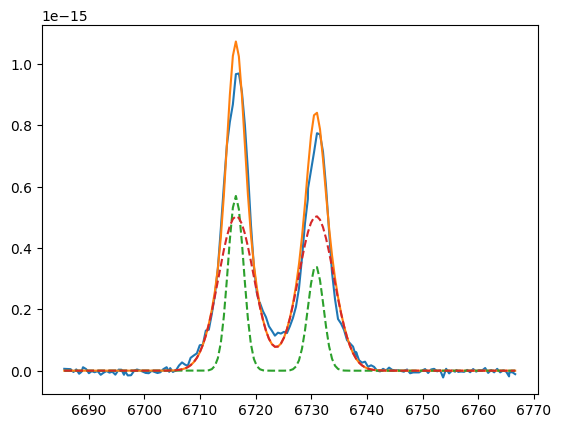

In [73]:
plt.plot(sii.wavelength, sii.flux)

siia_nar = gaussian(sii.wavelength, 1.2e-15, wave_cat['[SII]6730'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6730))
siia_brd = gaussian(sii.wavelength, 4e-15, wave_cat['[SII]6730'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6730))

siib_nar = gaussian(sii.wavelength, 2.0e-15, wave_cat['[SII]6716'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6730))
siib_brd = gaussian(sii.wavelength, 4.0e-15, wave_cat['[SII]6716'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6730))

siia = siia_nar + siia_brd
siib = siib_nar + siib_brd

plt.plot(sii.wavelength, siia + siib)
plt.plot(sii.wavelength, siia_nar + siib_nar, ls='--')
plt.plot(sii.wavelength, siia_brd + siib_brd, ls='--')
#plt.yscale('log')

In [79]:
params_sii = Parameters()
params_sii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_sii.add('z_ratio', value=z_ratio, vary=False)
params_sii.add('sigma_6730_nar', value=upy.nominal_values(sigma_nar_6730), vary=False)
params_sii.add('sigma_6730_brd', value=upy.nominal_values(sigma_brd_6730), vary=False)
params_sii.add('sigma_6716_nar', value=upy.nominal_values(sigma_nar_6730), vary=False)
params_sii.add('sigma_6716_brd', value=upy.nominal_values(sigma_brd_6730), vary=False)
params_sii.add('Siia_nar', value=1.2e-15, min=0.)
params_sii.add('Siia_brd', value=4.0e-15, min=0.)
params_sii.add('Siib_nar', value=2.0e-15, min=0.)
params_sii.add('Siib_brd', value=4.0e-15, min=0.)


def residual_sii(params_sii, x, data, uncertainty):
    
    z_nar = params_sii['z_nar']
    z_brd = params_sii['z_nar'] * params_sii['z_ratio']
    sigma_6730_nar = params_sii['sigma_6730_nar']
    sigma_6730_brd = params_sii['sigma_6730_brd']
    sigma_6716_nar = params_sii['sigma_6716_nar']
    sigma_6716_brd = params_sii['sigma_6716_brd']
    siia_nar_flux = params_sii['Siia_nar']
    siia_brd_flux = params_sii['Siia_brd']
    siib_nar_flux = params_sii['Siib_nar']
    siib_brd_flux = params_sii['Siib_brd']
    
    x = sii.wavelength
    model_siia = gaussian(x, siia_nar_flux, wave_cat['[SII]6730'], z_nar, sigma_6730_nar) + \
                 gaussian(x, siia_brd_flux, wave_cat['[SII]6730'], z_brd, sigma_6730_brd)
    model_siib = gaussian(x, siib_nar_flux, wave_cat['[SII]6716'], z_nar, sigma_6716_nar) + \
                 gaussian(x, siib_brd_flux, wave_cat['[SII]6716'], z_brd, sigma_6716_brd)
    model = model_siia + model_siib
    return (model - sii.flux) / sii.noise

In [80]:
np.random.seed(21)
out_sii = minimize(residual_sii, params_sii, args=(1, 1, 1),
                    method='emcee', burn=1000, steps=2500, thin=30)

100%|██████████████████████████████████████| 2500/2500 [00:24<00:00, 100.15it/s]

The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [123.67786408  69.9316477   75.05424772  53.21516126  48.61314099]


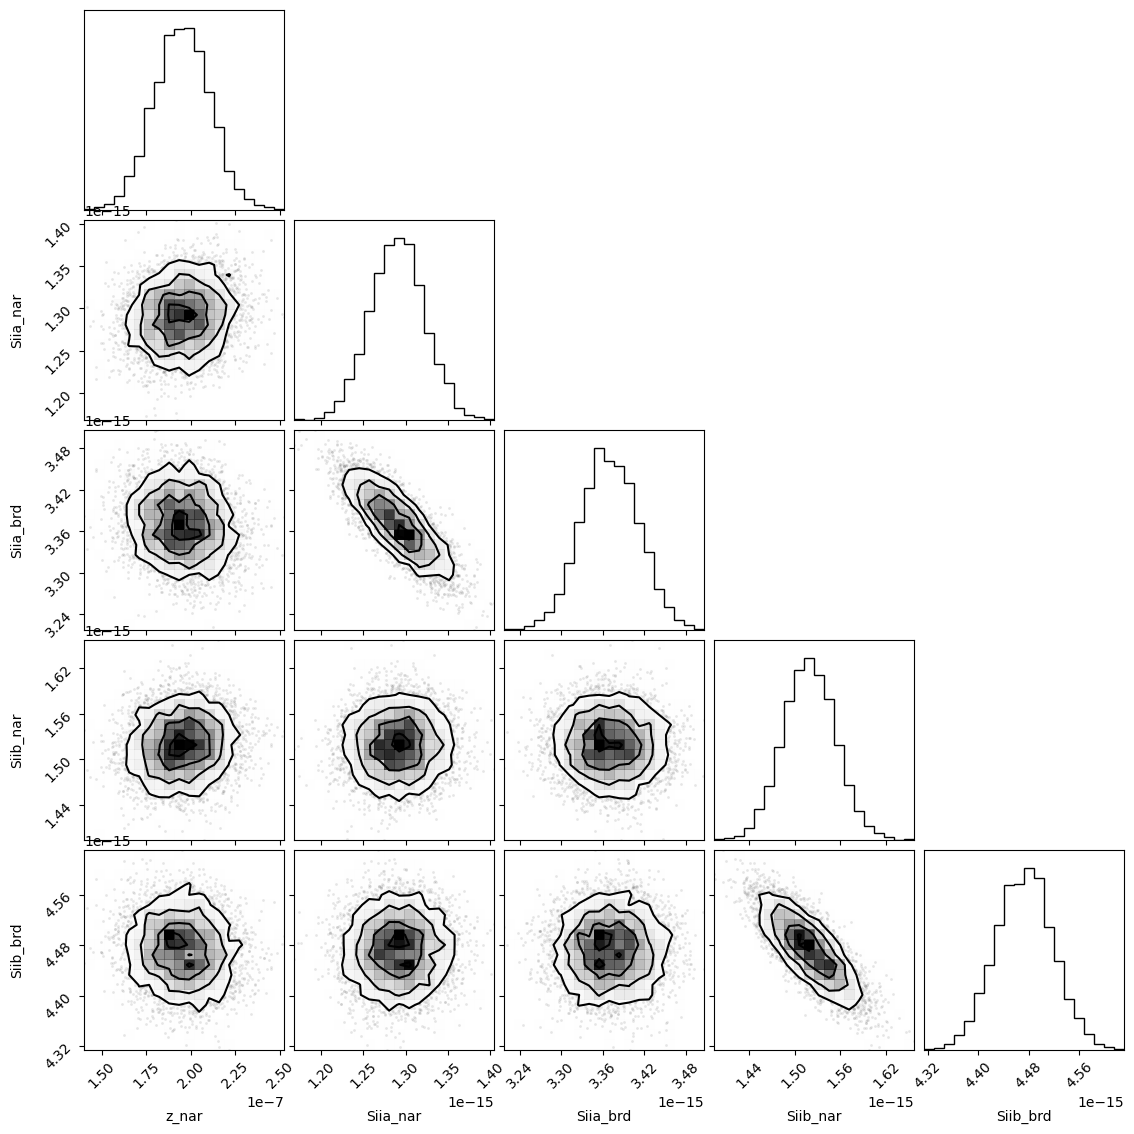

In [81]:
corner.corner(out_sii.flatchain, labels=out_sii.var_names);

In [82]:
out_sii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,1.9507e-07,1.5722e-08,(8.06%),6.760336358548223e-08,-inf,inf,True
z_ratio,178.554400,,,178.55439986698758,-inf,inf,False
sigma_6730_nar,1.40134543,,,1.4013454302543455,-inf,inf,False
sigma_6730_brd,3.17032849,,,3.1703284888215815,-inf,inf,False
sigma_6716_nar,1.40134543,,,1.4013454302543455,-inf,inf,False
sigma_6716_brd,3.17032849,,,3.1703284888215815,-inf,inf,False
Siia_nar,1.2903e-15,3.1699e-17,(2.46%),1.2e-15,0.00000000,inf,True
Siia_brd,3.3694e-15,4.1855e-17,(1.24%),4e-15,0.00000000,inf,True
Siib_nar,1.5186e-15,3.4057e-17,(2.24%),2e-15,0.00000000,inf,True
Siib_brd,4.4736e-15,4.5110e-17,(1.01%),4e-15,0.00000000,inf,True


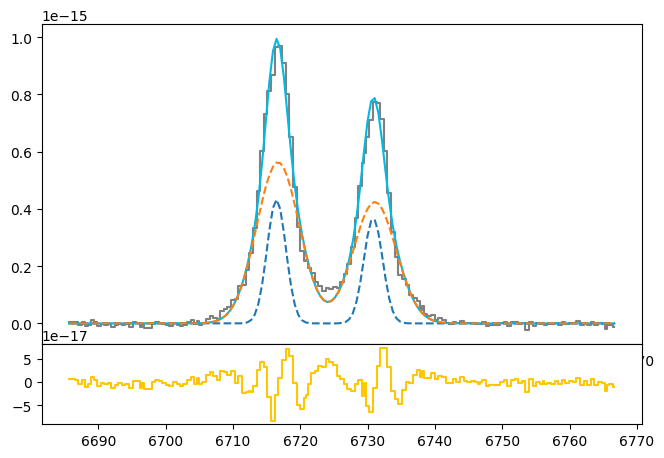

In [83]:
siia_nar_flux = out_sii.flatchain.Siia_nar.mean()
siia_nar_std = out_sii.flatchain.Siia_nar.std()

siia_brd_flux = out_sii.flatchain.Siia_brd.mean()
siia_brd_std = out_sii.flatchain.Siia_brd.std()

siib_nar_flux = out_sii.flatchain.Siib_nar.mean()
siib_nar_std = out_sii.flatchain.Siib_nar.std()

siib_brd_flux = out_sii.flatchain.Siib_brd.mean()
siib_brd_std = out_sii.flatchain.Siib_brd.std()

z_sii = out_sii.flatchain.z_nar.mean()
z_sii_std = out_sii.flatchain.z_nar.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(sii.wavelength, sii.flux, color='gray', label='Data', where='mid')

siia_nar = gaussian(sii.wavelength, siia_nar_flux, wave_cat['[SII]6730'], z_sii, upy.nominal_values(sigma_nar_6730))
siib_nar = gaussian(sii.wavelength, siib_nar_flux, wave_cat['[SII]6716'], z_sii, upy.nominal_values(sigma_nar_6730))

siia_brd = gaussian(sii.wavelength, siia_brd_flux, wave_cat['[SII]6730'], z_sii * z_ratio, upy.nominal_values(sigma_brd_6730))
siib_brd = gaussian(sii.wavelength, siib_brd_flux, wave_cat['[SII]6716'], z_sii * z_ratio, upy.nominal_values(sigma_brd_6730))

siia = siia_nar + siia_brd
siib = siib_nar + siib_brd

ax.plot(sii.wavelength, siia + siib, color=c[0])
ax.plot(sii.wavelength, siia_nar + siib_nar, ls='--')
ax.plot(sii.wavelength, siia_brd + siib_brd, ls='--')
#plt.yscale('log')
ax1.step(sii.wavelength, sii.flux - siia - siib, color=c[3], where='mid')

# H$\beta$

### Arc lines

In [84]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_hb = [wave_cat['Hb']*(1 + z_BN[igal]) - 20, wave_cat['Hb']*(1 + z_BN[igal]) + 20]
mask_arc_hb = (wcal_red[8].data['wave_soln'][0] >= wlims_hb[0]) & (wcal_red[8].data['wave_soln'][0] < wlims_hb[1])

# Arc spectra around the fitted line
x_arc_hb = wcal_red[8].data['wave_soln'][0][mask_arc_hb]
y_arc_hb = wcal_red[21].data[:, 3][mask_arc_hb]

100%|██████████████████████████████████████| 2500/2500 [00:21<00:00, 115.54it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [68.78052945 52.03564052 62.43344232 69.60317048]


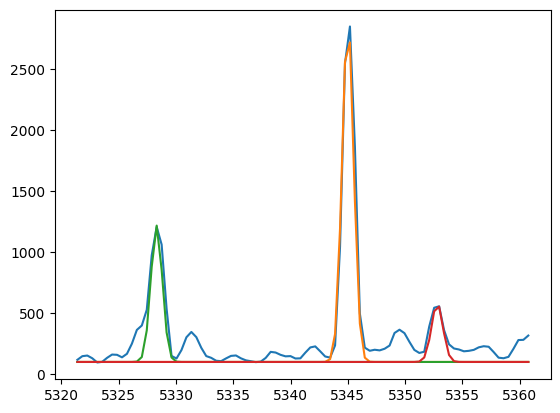

In [85]:
plt.plot(x_arc_hb, y_arc_hb)
plt.plot(x_arc_hb, 100 + gaussian(x_arc_hb, 3500, 5345, 0, 0.5))
plt.plot(x_arc_hb, 100 + gaussian(x_arc_hb, 1400, 5328.3, 0, 0.5))
plt.plot(x_arc_hb, 100 + gaussian(x_arc_hb, 600, 5352.8, 0, 0.5))

params_arc_hb = Parameters()
params_arc_hb.add('z', value=0.0, vary=False)
params_arc_hb.add('mu1', value=5345, vary=False)
params_arc_hb.add('mu2', value=5328.3, vary=False)
params_arc_hb.add('mu3', value=5352.8, vary=False)
params_arc_hb.add('arc1', value=3500, min=0.)
params_arc_hb.add('arc2', value=1400, min=0.)
params_arc_hb.add('arc3', value=600, min=0.)
params_arc_hb.add('sigma', value=0.5, min=0.)
params_arc_hb.add('bkg', value=100, vary=False)

def residual_arc_hb(params_arc_hb, x, data, uncertainty):
    
    z = params_arc_hb['z']
    mu1 = params_arc_hb['mu1']
    mu2 = params_arc_hb['mu2']
    mu3 = params_arc_hb['mu3']
    flux1 = params_arc_hb['arc1']
    flux2 = params_arc_hb['arc2']
    flux3 = params_arc_hb['arc3']
    sigma = params_arc_hb['sigma']
    bkg = params_arc_hb['bkg']
    
    x = x_arc_hb
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_hb) / 10

np.random.seed(21)
out_arc_hb = minimize(residual_arc_hb, params_arc_hb, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

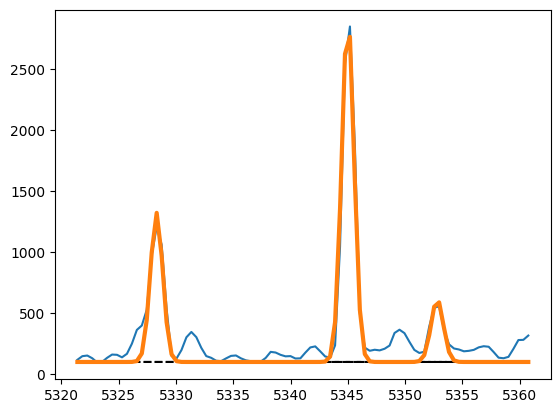

In [86]:
arc1_hb = out_arc_hb.flatchain.arc1.mean()
arc2_hb = out_arc_hb.flatchain.arc2.mean()
arc3_hb = out_arc_hb.flatchain.arc3.mean()
sigma_arc_hb = out_arc_hb.flatchain.sigma.mean()

plt.plot(x_arc_hb, y_arc_hb)

plt.plot(x_arc_hb, 100 + gaussian(x_arc_hb, arc1_hb, 5345, 0, sigma_arc_hb), ls='--', color='black')
plt.plot(x_arc_hb, 100 + gaussian(x_arc_hb, arc2_hb, 5328.3, 0, sigma_arc_hb), ls='--', color='black')
plt.plot(x_arc_hb, 100 + gaussian(x_arc_hb, arc3_hb, 5352.8, 0, sigma_arc_hb), ls='--', color='black')

plt.plot(x_arc_hb, 100 + gaussian(x_arc_hb, arc1_hb, 5345, 0, sigma_arc_hb) \
         + gaussian(x_arc_hb, arc2_hb, 5328.3, 0, sigma_arc_hb) \
         + gaussian(x_arc_hb, arc3_hb, 5352.8, 0, sigma_arc_hb), lw=3
)

### Line fitting

In [87]:
sigma_nar_hb = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_hb**2))
sigma_brd_hb = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_hb**2))

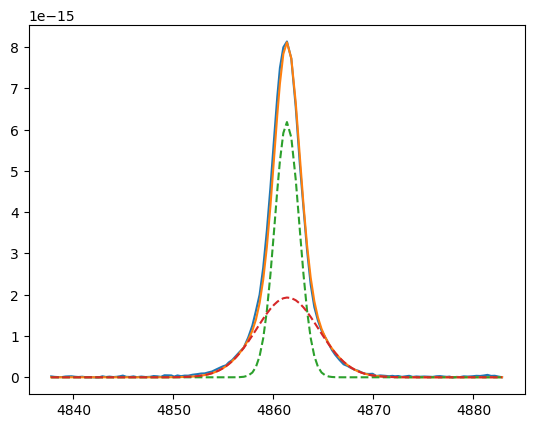

In [90]:
plt.plot(hbeta.wavelength, hbeta.flux)
bkg = 3.8e-16

hb_nar = gaussian(hbeta.wavelength, 1.9e-14, wave_cat['Hb'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_hb))
hb_brd = gaussian(hbeta.wavelength, 1.5e-14, wave_cat['Hb'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_hb))

hb = hb_nar + hb_brd

plt.plot(hbeta.wavelength, hb)
plt.plot(hbeta.wavelength, hb_nar, ls='--')
plt.plot(hbeta.wavelength, hb_brd, ls='--')
#plt.yscale('log')

In [91]:
params_hb = Parameters()
params_hb.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_hb.add('z_ratio', value=z_ratio, vary=False)
params_hb.add('sigma_hb_nar', value=upy.nominal_values(sigma_nar_hb), vary=False)
params_hb.add('sigma_hb_brd', value=upy.nominal_values(sigma_brd_hb), vary=False)
params_hb.add('Hb_nar', value=1.9e-14, min=0.)
params_hb.add('Hb_brd', value=1.5e-14, min=0.)

def residual_hb(params_hb, x, data, uncertainty):
    
    z_nar = params_hb['z_nar']
    z_brd = params_hb['z_nar'] * params_hb['z_ratio']
    sigma_hb_nar = params_hb['sigma_hb_nar']
    sigma_hb_brd = params_hb['sigma_hb_brd']
    hb_nar_flux = params_hb['Hb_nar']
    hb_brd_flux = params_hb['Hb_brd']
    
    x = hbeta.wavelength
    model = gaussian(x, hb_nar_flux, wave_cat['Hb'], z_nar, sigma_hb_nar) + \
            gaussian(x, hb_brd_flux, wave_cat['Hb'], z_brd, sigma_hb_brd)
    return (model - hbeta.flux) / hbeta.noise

In [92]:
np.random.seed(21)
out_hb = minimize(residual_hb, params_hb, args=(1, 1, 1),
                   method='emcee', burn=1000, steps=2500, thin=30)

100%|██████████████████████████████████████| 2500/2500 [00:17<00:00, 142.28it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [77.483589   29.88108063 44.3155732 ]


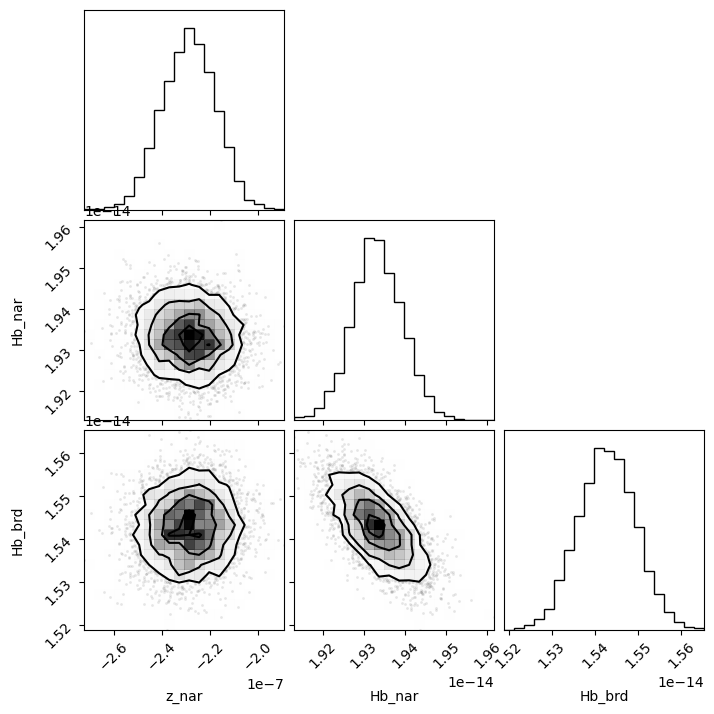

In [93]:
corner.corner(out_hb.flatchain, labels=out_hb.var_names);

In [94]:
out_hb.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,-2.2860e-07,1.1166e-08,(4.88%),6.760336358548223e-08,-inf,inf,True
z_ratio,178.554400,,,178.55439986698758,-inf,inf,False
sigma_hb_nar,1.22593084,,,1.2259308433071456,-inf,inf,False
sigma_hb_brd,3.09679191,,,3.0967919117549316,-inf,inf,False
Hb_nar,1.9331e-14,6.0085e-17,(0.31%),1.9e-14,0.00000000,inf,True
Hb_brd,1.5428e-14,6.6110e-17,(0.43%),1.5e-14,0.00000000,inf,True


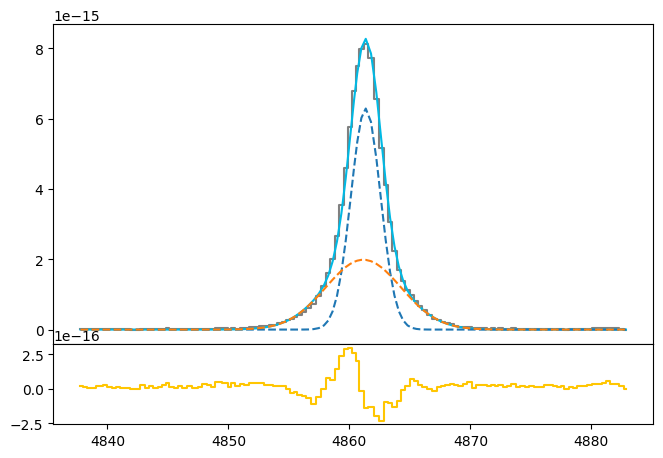

In [95]:
hb_nar_flux = out_hb.flatchain.Hb_nar.mean()
hb_nar_std = out_hb.flatchain.Hb_nar.std()

hb_brd_flux = out_hb.flatchain.Hb_brd.mean()
hb_brd_std = out_hb.flatchain.Hb_brd.std()

z_hb = out_hb.flatchain.z_nar.mean()
z_hb_std = out_hb.flatchain.z_nar.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(hbeta.wavelength, hbeta.flux, color='gray', label='Data', where='mid')

hb_nar = gaussian(hbeta.wavelength, hb_nar_flux, wave_cat['Hb'], z_hb, upy.nominal_values(sigma_nar_hb))
hb_brd = gaussian(hbeta.wavelength, hb_brd_flux, wave_cat['Hb'], z_hb * z_ratio, upy.nominal_values(sigma_brd_hb))

hb = hb_nar + hb_brd

ax.plot(hbeta.wavelength, hb, color=c[0])
ax.plot(hbeta.wavelength, hb_nar, ls='--')
ax.plot(hbeta.wavelength, hb_brd, ls='--')
#ax.set_yscale('log')
ax1.step(hbeta.wavelength, hbeta.flux - hb, color=c[3], where='mid')

# [OII]3726 + [OII]3729

### Arc lines

In [96]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_3729 = [wave_cat['[OII]3729']*(1 + z_BN[igal]) - 10, wave_cat['[OII]3729']*(1 + z_BN[igal]) + 10]
mask_arc_3729 = (wcal_blue[6].data['wave_soln'][0] >= wlims_3729[0]) & (wcal_blue[6].data['wave_soln'][0] < wlims_3729[1])

# Arc spectra around the fitted line
x_arc_3729 = wcal_blue[6].data['wave_soln'][0][mask_arc_3729]
y_arc_3729 = wcal_blue[27].data[:, 2][mask_arc_3729]

100%|███████████████████████████████████████| 2500/2500 [00:32<00:00, 76.32it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 56.96894038  88.81713093 145.99239809  63.64365113 121.81365773
  59.14712544  60.66126412  76.95906489]


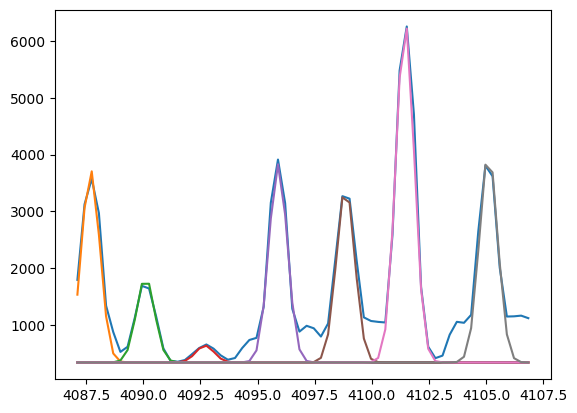

In [97]:
plt.plot(x_arc_3729, y_arc_3729)
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, 3400, 4087.7, 0, 0.4))
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, 1500, 4090.1, 0, 0.4))
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, 300, 4092.7, 0, 0.4))
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, 3500, 4095.9, 0, 0.4))
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, 3100, 4098.85, 0, 0.4))
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, 6000, 4101.45, 0, 0.4))
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, 3700, 4105.1, 0, 0.4))

params_arc_3729 = Parameters()
params_arc_3729.add('z', value=0.0, vary=False)
params_arc_3729.add('mu1', value=4087.7, vary=False)
params_arc_3729.add('mu2', value=4090.1, vary=False)
params_arc_3729.add('mu3', value=4092.7, vary=False)
params_arc_3729.add('mu4', value=4095.9, vary=False)
params_arc_3729.add('mu5', value=4098.85, vary=False)
params_arc_3729.add('mu6', value=4101.45, vary=False)
params_arc_3729.add('mu7', value=4105.1, vary=False)
params_arc_3729.add('arc1', value=3400, min=0.)
params_arc_3729.add('arc2', value=1500, min=0.)
params_arc_3729.add('arc3', value=300, min=0.)
params_arc_3729.add('arc4', value=3500, min=0.)
params_arc_3729.add('arc5', value=3100, min=0.)
params_arc_3729.add('arc6', value=6000, min=0.)
params_arc_3729.add('arc7', value=3700, min=0.)
params_arc_3729.add('sigma', value=0.4, min=0.)
params_arc_3729.add('bkg', value=340, vary=False)

def residual_arc_3729(params_arc_3729, x, data, uncertainty):
    
    z = params_arc_3729['z']
    mu1 = params_arc_3729['mu1']
    mu2 = params_arc_3729['mu2']
    mu3 = params_arc_3729['mu3']
    mu4 = params_arc_3729['mu4']
    mu5 = params_arc_3729['mu5']
    mu6 = params_arc_3729['mu6']
    mu7 = params_arc_3729['mu7']
    flux1 = params_arc_3729['arc1']
    flux2 = params_arc_3729['arc2']
    flux3 = params_arc_3729['arc3']
    flux4 = params_arc_3729['arc4']
    flux5 = params_arc_3729['arc5']
    flux6 = params_arc_3729['arc6']
    flux7 = params_arc_3729['arc7']
    sigma = params_arc_3729['sigma']
    bkg = params_arc_3729['bkg']
    
    x = x_arc_3729
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model6 = gaussian(x, flux6, mu6, z, sigma)
    model7 = gaussian(x, flux7, mu7, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5 + model6 + model7
    return (model - y_arc_3729) / 10

np.random.seed(21)
out_arc_3729 = minimize(residual_arc_3729, params_arc_3729, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

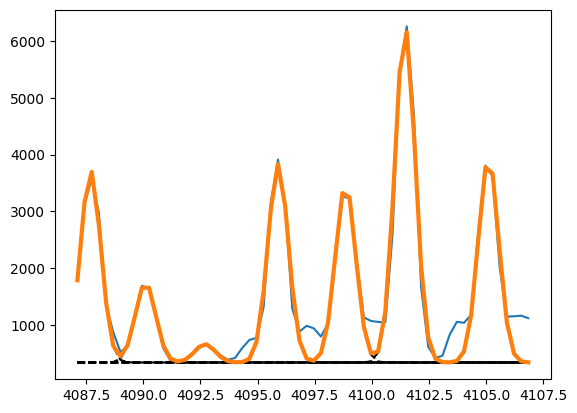

In [98]:
arc1_3729 = out_arc_3729.flatchain.arc1.mean()
arc2_3729 = out_arc_3729.flatchain.arc2.mean()
arc3_3729 = out_arc_3729.flatchain.arc3.mean()
arc4_3729 = out_arc_3729.flatchain.arc4.mean()
arc5_3729 = out_arc_3729.flatchain.arc5.mean()
arc6_3729 = out_arc_3729.flatchain.arc6.mean()
arc7_3729 = out_arc_3729.flatchain.arc7.mean()
sigma_arc_3729 = out_arc_3729.flatchain.sigma.mean()

plt.plot(x_arc_3729, y_arc_3729)

plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, arc1_3729, 4087.7, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, arc2_3729, 4090.1, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, arc3_3729, 4092.7, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, arc4_3729, 4095.9, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, arc5_3729, 4098.85, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, arc6_3729, 4101.45, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, arc7_3729, 4105.1, 0, sigma_arc_3729), ls='--', color='black')

plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, arc1_3729, 4087.7, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc2_3729, 4090.1, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc3_3729, 4092.7, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc4_3729, 4095.9, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc5_3729, 4098.85, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc6_3729, 4101.45, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc7_3729, 4105.1, 0, sigma_arc_3729), lw=3
)

### Line fitting

In [99]:
sigma_nar_3729 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_3729**2))
sigma_brd_3729 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_3729**2))

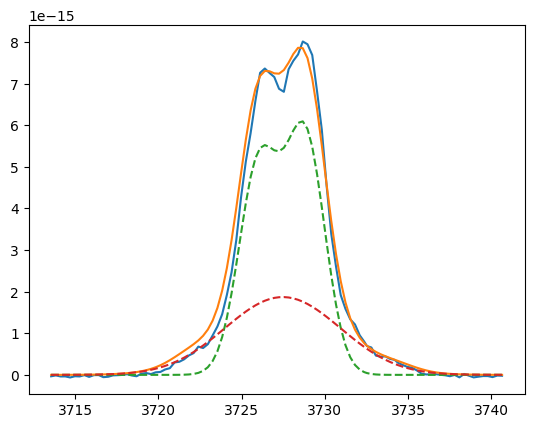

In [103]:
# Search for good initial guess

plt.plot(oii_3727.wavelength, oii_3727.flux)

h13 = gaussian(oii_3727.wavelength, 3e-16, wave_cat['H13'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))

oiic_nar = gaussian(oii_3727.wavelength, 1.7e-14, wave_cat['[OII]3729'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))
oiic_brd = gaussian(oii_3727.wavelength, 0.8e-14, wave_cat['[OII]3729'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3729))

oiid_nar = gaussian(oii_3727.wavelength, 1.5e-14, wave_cat['[OII]3726'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))
oiid_brd = gaussian(oii_3727.wavelength, 0.8e-14, wave_cat['[OII]3726'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_3729))

h14 = gaussian(oii_3727.wavelength, 0.5e-15, wave_cat['H14'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_3729))

oiic = oiic_nar + oiic_brd
oiid = oiid_nar + oiid_brd

plt.plot(oii_3727.wavelength, oiid + oiic + h13 + h14)
plt.plot(oii_3727.wavelength, oiid_nar + oiic_nar, ls='--')
plt.plot(oii_3727.wavelength, oiid_brd + oiic_brd, ls='--')

In [104]:
params_oii_3727 = Parameters()

params_oii_3727.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oii_3727.add('z_ratio', value=z_ratio, vary=False)
params_oii_3727.add('sigma_3729_nar', value=upy.nominal_values(sigma_nar_3729), vary=False)
params_oii_3727.add('sigma_3729_brd', value=upy.nominal_values(sigma_brd_3729), vary=False)
params_oii_3727.add('sigma_3726_nar', value=upy.nominal_values(sigma_nar_3729), vary=False)
params_oii_3727.add('sigma_3726_brd', value=upy.nominal_values(sigma_brd_3729), vary=False)
params_oii_3727.add('H13', value=3.0e-16, min=0.)
params_oii_3727.add('H14', value=0.5e-15, min=0.)
params_oii_3727.add('Oiic_nar', value=1.7e-14, min=0.)
params_oii_3727.add('Oiic_brd', value=0.8e-14, min=0.)
params_oii_3727.add('Oiid_nar', value=1.5e-14, min=0.)
params_oii_3727.add('Oiid_brd', value=0.8e-14, min=0.)

def residual_oii_3727(params_oii_3727, x, data, uncertainty):
    
    z_nar = params_oii_3727['z_nar']
    z_brd = params_oii_3727['z_nar'] * params_oii_3727['z_ratio']
    sigma_3729_nar = params_oii_3727['sigma_3729_nar']
    sigma_3729_brd = params_oii_3727['sigma_3729_brd']
    sigma_3726_nar = params_oii_3727['sigma_3726_nar']
    sigma_3726_brd = params_oii_3727['sigma_3726_brd']
    
    h13_flux = params_oii_3727['H13']
    oiic_nar_flux = params_oii_3727['Oiic_nar']
    oiic_brd_flux = params_oii_3727['Oiic_brd']
    oiid_nar_flux = params_oii_3727['Oiid_nar']
    oiid_brd_flux = params_oii_3727['Oiid_brd']
    h14_flux = params_oii_3727['H14']
    
    x = oii_3727.wavelength
    model_h13 = gaussian(x, h13_flux, wave_cat['H13'], z_nar, sigma_3729_nar)
    model_h14 = gaussian(x, h14_flux, wave_cat['H14'], z_nar, sigma_3729_nar)
    model_oiic = gaussian(x, oiic_nar_flux, wave_cat['[OII]3729'], z_nar, sigma_3729_nar) + \
                 gaussian(x, oiic_brd_flux, wave_cat['[OII]3729'], z_brd, sigma_3729_brd)
    model_oiid = gaussian(x, oiid_nar_flux, wave_cat['[OII]3726'], z_nar, sigma_3726_nar) + \
                 gaussian(x, oiid_brd_flux, wave_cat['[OII]3726'], z_brd, sigma_3726_brd)
    
    model = model_h13 + model_oiic + model_oiid + model_h14
    return (model - oii_3727.flux) / oii_3727.noise

In [105]:
np.random.seed(21)
out_oii_3727 = minimize(residual_oii_3727, params_oii_3727, args=(1, 1, 1),
                         method='emcee', burn=1000, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:25<00:00, 98.48it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 82.63750956 136.51264788 118.46338937  65.02924243  82.29211815
 108.56644088 100.73187851]


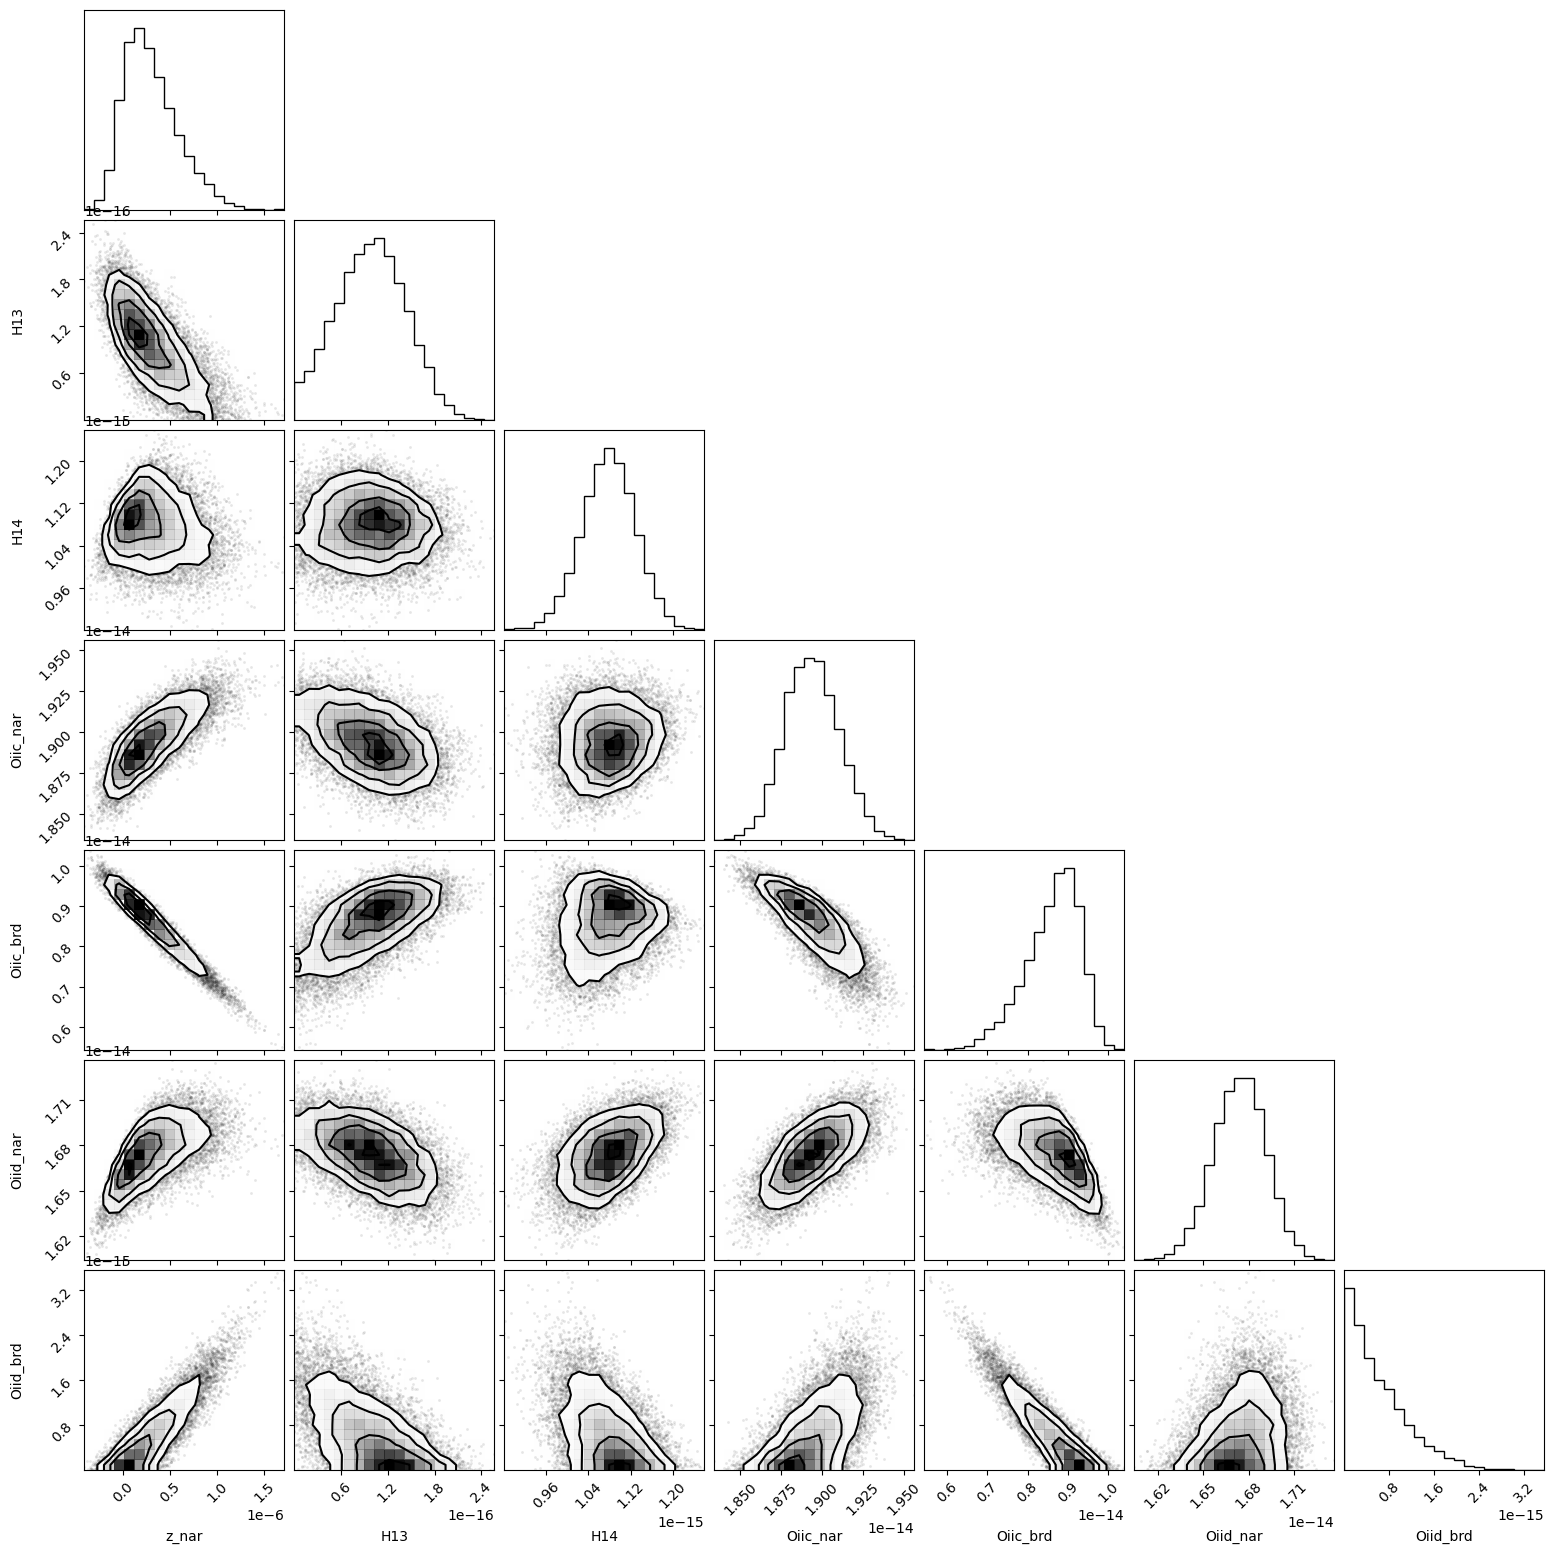

In [106]:
corner.corner(out_oii_3727.flatchain, labels=out_oii_3727.var_names);

In [107]:
out_oii_3727.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,2.5528e-07,2.8582e-07,(111.96%),6.760336358548223e-08,-inf,inf,True
z_ratio,178.554400,,,178.55439986698758,-inf,inf,False
sigma_3729_nar,1.18765732,,,1.187657322214878,-inf,inf,False
sigma_3729_brd,3.08184095,,,3.0818409477371818,-inf,inf,False
sigma_3726_nar,1.18765732,,,1.187657322214878,-inf,inf,False
sigma_3726_brd,3.08184095,,,3.0818409477371818,-inf,inf,False
H13,9.9306e-17,4.6156e-17,(46.48%),3e-16,0.00000000,inf,True
H14,1.0793e-15,5.0326e-17,(4.66%),5e-16,0.00000000,inf,True
Oiic_nar,1.8935e-14,1.6638e-16,(0.88%),1.7e-14,0.00000000,inf,True
Oiic_brd,8.7207e-15,6.6741e-16,(7.65%),8e-15,0.00000000,inf,True


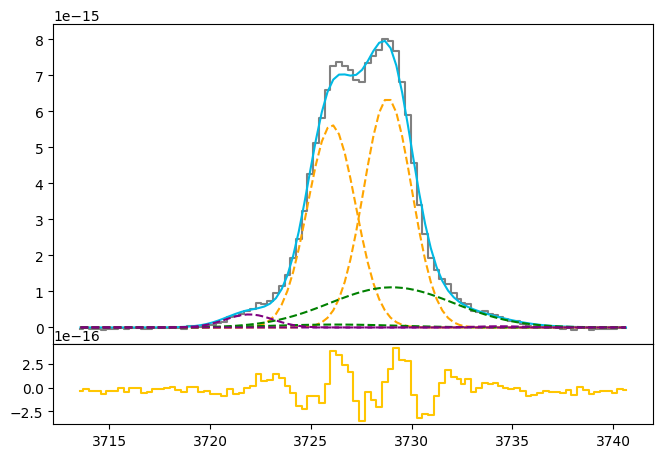

In [109]:
h13_flux = out_oii_3727.flatchain.H13.mean()
h13_std = out_oii_3727.flatchain.H13.std()

oiic_nar_flux = out_oii_3727.flatchain.Oiic_nar.mean()
oiic_nar_std = out_oii_3727.flatchain.Oiic_nar.std()

oiic_brd_flux = out_oii_3727.flatchain.Oiic_brd.mean()
oiic_brd_std = out_oii_3727.flatchain.Oiic_brd.std()

oiid_nar_flux = out_oii_3727.flatchain.Oiid_nar.mean()
oiid_nar_std = out_oii_3727.flatchain.Oiid_nar.std()

oiid_brd_flux = out_oii_3727.flatchain.Oiid_brd.mean()
oiid_brd_std = out_oii_3727.flatchain.Oiid_brd.std()

h14_flux = out_oii_3727.flatchain.H14.mean()
h14_std = out_oii_3727.flatchain.H14.std()

z_oii_3727 = out_oii_3727.flatchain.z_nar.mean()
z_oii_3727_std = out_oii_3727.flatchain.z_nar.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oii_3727.wavelength, oii_3727.flux, color='gray', label='Data', where='mid')

h13 = gaussian(oii_3727.wavelength, h13_flux, wave_cat['H13'], z_oii_3727, upy.nominal_values(sigma_nar_3729))

oiic_nar = gaussian(oii_3727.wavelength, oiic_nar_flux, wave_cat['[OII]3729'], z_oii_3727, upy.nominal_values(sigma_nar_3729))
oiic_brd = gaussian(oii_3727.wavelength, oiic_brd_flux, wave_cat['[OII]3729'], z_oii_3727 * z_ratio, upy.nominal_values(sigma_brd_3729))

oiid_nar = gaussian(oii_3727.wavelength, oiid_nar_flux, wave_cat['[OII]3726'], z_oii_3727, upy.nominal_values(sigma_nar_3729))
oiid_brd = gaussian(oii_3727.wavelength, oiid_brd_flux, wave_cat['[OII]3726'], z_oii_3727 * z_ratio, upy.nominal_values(sigma_brd_3729))

h14 = gaussian(oii_3727.wavelength, h14_flux, wave_cat['H14'], z_oii_3727, upy.nominal_values(sigma_nar_3729))

oiic = oiic_nar + oiic_brd
oiid = oiid_nar + oiid_brd

ax.plot(oii_3727.wavelength, h13 + oiic + oiid + h14, color=c[0])
ax.plot(oii_3727.wavelength, oiic_nar, ls='--', color='orange')
ax.plot(oii_3727.wavelength, oiid_nar, ls='--', color='orange')
ax.plot(oii_3727.wavelength, oiic_brd, ls='--', color='green')
ax.plot(oii_3727.wavelength, oiid_brd, ls='--', color='green')
ax.plot(oii_3727.wavelength, h13, ls='--', color='purple')
ax.plot(oii_3727.wavelength, h14, ls='--', color='purple')

#ax.set_yscale('log')
ax1.step(oii_3727.wavelength, oii_3727.flux - oiic - oiid - h13 - h14, color=c[3], where='mid')

# [NII]5755

### Arc lines

In [110]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_5755 = [wave_cat['[NII]5755']*(1 + z_BN[igal]) - 5, wave_cat['[NII]5755']*(1 + z_BN[igal]) + 20]
mask_arc_5755 = (wcal_red[10].data['wave_soln'][0] >= wlims_5755[0]) & (wcal_red[10].data['wave_soln'][0] < wlims_5755[1])

# Arc spectra around the fitted line
x_arc_5755 = wcal_red[10].data['wave_soln'][0][mask_arc_5755]
y_arc_5755 = wcal_red[21].data[:, 4][mask_arc_5755]

100%|██████████████████████████████████████| 2500/2500 [00:23<00:00, 107.59it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [87.52536076 57.71430344 40.25134037 45.26160528 65.28724211]


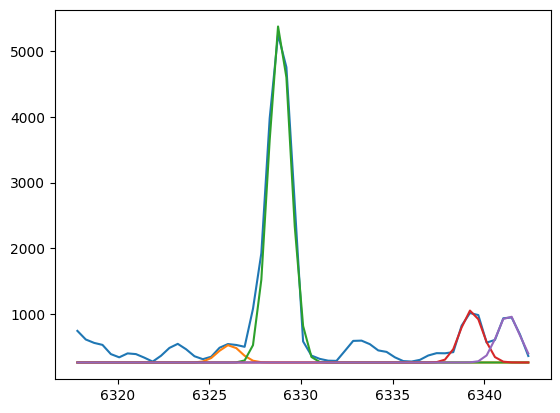

In [111]:
plt.plot(x_arc_5755, y_arc_5755)
plt.plot(x_arc_5755, 260 + gaussian(x_arc_5755, 400, 6326.1, 0, 0.6))
plt.plot(x_arc_5755, 260 + gaussian(x_arc_5755, 7800, 6328.85, 0, 0.6))
plt.plot(x_arc_5755, 260 + gaussian(x_arc_5755, 1200, 6339.3, 0, 0.6))
plt.plot(x_arc_5755, 260 + gaussian(x_arc_5755, 1100, 6341.3, 0, 0.6))

params_arc_5755 = Parameters()
params_arc_5755.add('z', value=0.0, vary=False)
params_arc_5755.add('mu1', value=6326.1, vary=False)
params_arc_5755.add('mu2', value=6328.85, vary=False)
params_arc_5755.add('mu3', value=6339.3, vary=False)
params_arc_5755.add('mu4', value=6341.3, vary=False)
params_arc_5755.add('arc1', value=400, min=0.)
params_arc_5755.add('arc2', value=7800, min=0.)
params_arc_5755.add('arc3', value=1200, min=0.)
params_arc_5755.add('arc4', value=1100, min=0.)
params_arc_5755.add('sigma', value=0.6, min=0.)
params_arc_5755.add('bkg', value=260, vary=False)

def residual_arc_5755(params_arc_5755, x, data, uncertainty):
    
    z = params_arc_5755['z']
    mu1 = params_arc_5755['mu1']
    mu2 = params_arc_5755['mu2']
    mu3 = params_arc_5755['mu3']
    mu4 = params_arc_5755['mu4']
    flux1 = params_arc_5755['arc1']
    flux2 = params_arc_5755['arc2']
    flux3 = params_arc_5755['arc3']
    flux4 = params_arc_5755['arc4']
    sigma = params_arc_5755['sigma']
    bkg = params_arc_5755['bkg']
    
    x = x_arc_5755
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model = bkg + model1 + model2 + model3 + model4
    return (model - y_arc_5755) / 10

np.random.seed(21)
out_arc_5755 = minimize(residual_arc_5755, params_arc_5755, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [112]:
out_arc_5755.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,6326.10000,,,6326.1,-inf,inf,False
mu2,6328.85000,,,6328.85,-inf,inf,False
mu3,6339.30000,,,6339.3,-inf,inf,False
mu4,6341.30000,,,6341.3,-inf,inf,False
arc1,533.884335,10.5510871,(1.98%),400,0.00000000,inf,True
arc2,8457.88168,12.4196985,(0.15%),7800,0.00000000,inf,True
arc3,1204.06970,10.3985637,(0.86%),1200,0.00000000,inf,True
arc4,1073.42681,10.3894249,(0.97%),1100,0.00000000,inf,True
sigma,0.65238597,0.00107532,(0.16%),0.6,0.00000000,inf,True


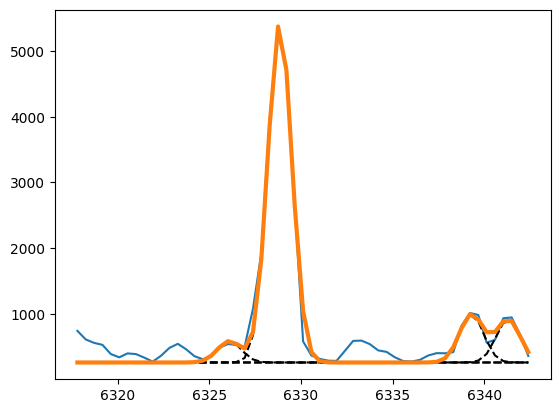

In [113]:
arc1_5755 = out_arc_5755.flatchain.arc1.mean()
arc2_5755 = out_arc_5755.flatchain.arc2.mean()
arc3_5755 = out_arc_5755.flatchain.arc3.mean()
arc4_5755 = out_arc_5755.flatchain.arc4.mean()
sigma_arc_5755 = out_arc_5755.flatchain.sigma.mean()

plt.plot(x_arc_5755, y_arc_5755)

plt.plot(x_arc_5755, 260 + gaussian(x_arc_5755, arc1_5755, 6326.1, 0, sigma_arc_5755), ls='--', color='black')
plt.plot(x_arc_5755, 260 + gaussian(x_arc_5755, arc2_5755, 6328.85, 0, sigma_arc_5755), ls='--', color='black')
plt.plot(x_arc_5755, 260 + gaussian(x_arc_5755, arc3_5755, 6339.3, 0, sigma_arc_5755), ls='--', color='black')
plt.plot(x_arc_5755, 260 + gaussian(x_arc_5755, arc4_5755, 6341.3, 0, sigma_arc_5755), ls='--', color='black')

plt.plot(x_arc_5755, 260 + gaussian(x_arc_5755, arc1_5755, 6326.1, 0, sigma_arc_5755) \
         + gaussian(x_arc_5755, arc2_5755, 6328.85, 0, sigma_arc_5755) \
         + gaussian(x_arc_5755, arc3_5755, 6339.3, 0, sigma_arc_5755) \
         + gaussian(x_arc_5755, arc4_5755, 6341.3, 0, sigma_arc_5755), lw=3
)

### Line fitting

In [114]:
sigma_nar_5755 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_5755**2))
sigma_brd_5755 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_5755**2))

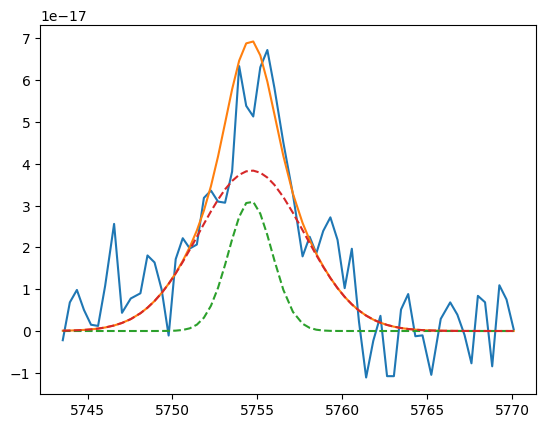

In [115]:
plt.plot(nii_5755.wavelength, nii_5755.flux)
bkg = 2.65e-16

niic_nar = gaussian(nii_5755.wavelength, 1e-16, wave_cat['[NII]5755'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_5755))
niic_brd = gaussian(nii_5755.wavelength, 3e-16, wave_cat['[NII]5755'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_5755))

niic = niic_nar + niic_brd

plt.plot(nii_5755.wavelength, niic)
plt.plot(nii_5755.wavelength, niic_nar, ls='--')
plt.plot(nii_5755.wavelength, niic_brd, ls='--')
#plt.yscale('log')

In [116]:
params_nii = Parameters()
params_nii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_nii.add('z_ratio', value=z_ratio, vary=False)
params_nii.add('sigma_5755_nar', value=upy.nominal_values(sigma_nar_5755), vary=False)
params_nii.add('sigma_5755_brd', value=upy.nominal_values(sigma_brd_5755), vary=False)
params_nii.add('Niic_nar', value=1.0e-16, min=0.)
params_nii.add('Niic_brd', value=3.0e-16, min=0.)

def residual_nii(params_nii, x, data, uncertainty):
    
    z_nar = params_nii['z_nar']
    z_brd = params_nii['z_nar'] * params_nii['z_ratio']
    sigma_5755_nar = params_nii['sigma_5755_nar']
    sigma_5755_brd = params_nii['sigma_5755_brd']
    niic_nar_flux = params_nii['Niic_nar']
    niic_brd_flux = params_nii['Niic_brd']
    
    x = nii_5755.wavelength
    model = gaussian(x, niic_nar_flux, wave_cat['[NII]5755'], z_nar, sigma_5755_nar) + \
            gaussian(x, niic_brd_flux, wave_cat['[NII]5755'], z_brd, sigma_5755_brd)
    return (model - nii_5755.flux) / nii_5755.noise

In [117]:
np.random.seed(21)
out_nii = minimize(residual_nii, params_nii, args=(1, 1, 1),
                   method='emcee', burn=1000, steps=2500, thin=30)

100%|██████████████████████████████████████| 2500/2500 [00:16<00:00, 149.36it/s]


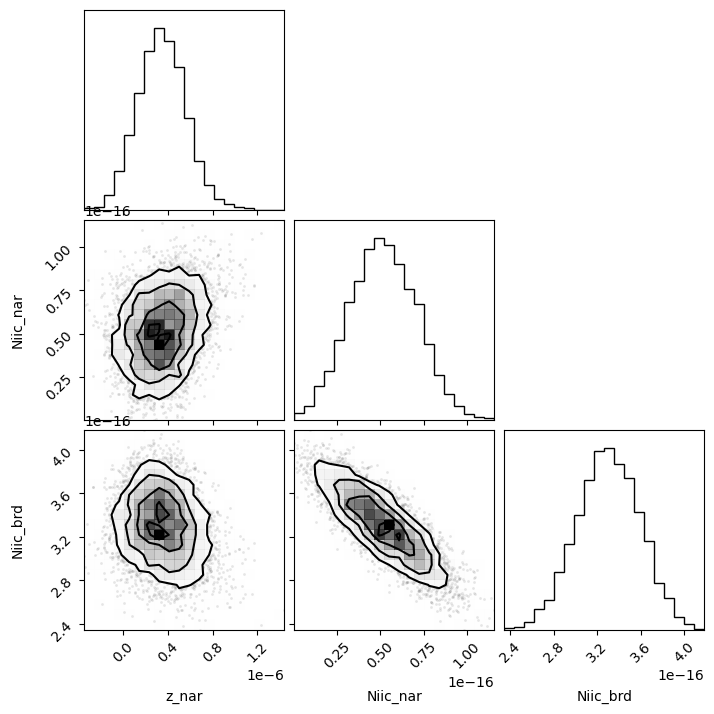

In [118]:
corner.corner(out_nii.flatchain, labels=out_nii.var_names);

In [119]:
out_nii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,3.4557e-07,2.1230e-07,(61.43%),6.760336358548223e-08,-inf,inf,True
z_ratio,178.554400,,,178.55439986698758,-inf,inf,False
sigma_5755_nar,1.28019907,,,1.2801990677784598,-inf,inf,False
sigma_5755_brd,3.11867333,,,3.1186733341726947,-inf,inf,False
Niic_nar,5.1531e-17,1.9584e-17,(38.00%),1e-16,0.00000000,inf,True
Niic_brd,3.3034e-16,2.9073e-17,(8.80%),3e-16,0.00000000,inf,True


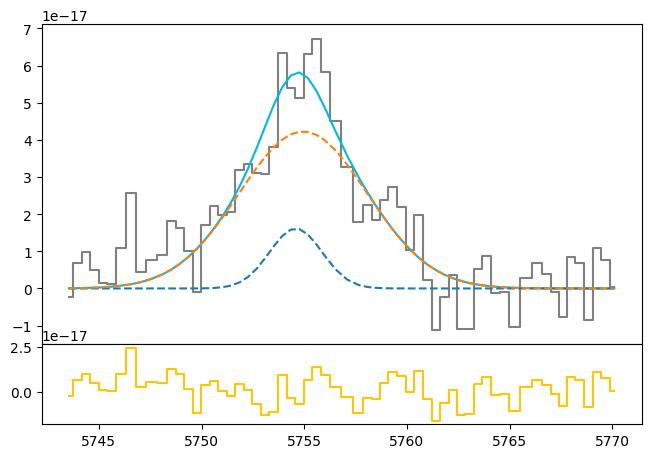

In [120]:
niic_nar_flux = out_nii.flatchain.Niic_nar.mean()
niic_nar_std = out_nii.flatchain.Niic_nar.std()

niic_brd_flux = out_nii.flatchain.Niic_brd.mean()
niic_brd_std = out_nii.flatchain.Niic_brd.std()

z_nii = out_nii.flatchain.z_nar.mean()
z_nii_std = out_nii.flatchain.z_nar.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(nii_5755.wavelength, nii_5755.flux, color='gray', label='Data', where='mid')

niic_nar = gaussian(nii_5755.wavelength, niic_nar_flux, wave_cat['[NII]5755'], z_nii, upy.nominal_values(sigma_nar_5755))
niic_brd = gaussian(nii_5755.wavelength, niic_brd_flux, wave_cat['[NII]5755'], z_nii * z_ratio, upy.nominal_values(sigma_brd_5755))

niic = niic_nar + niic_brd

ax.plot(nii_5755.wavelength, niic, color=c[0])
ax.plot(nii_5755.wavelength, niic_nar, ls='--')
ax.plot(nii_5755.wavelength, niic_brd, ls='--')
#ax.set_yscale('log')
ax1.step(nii_5755.wavelength, nii_5755.flux - niic, color=c[3], where='mid')

# [SIII]9532

### Arc lines

In [121]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_9532 = [wave_cat['[SIII]9532']*(1 + z_BN[igal]) - 10, wave_cat['[SIII]9532']*(1 + z_BN[igal]) + 10]
mask_arc_9532 = (wcal_red[18].data['wave_soln'][0] >= wlims_9532[0]) & (wcal_red[18].data['wave_soln'][0] < wlims_9532[1])

# Arc spectra around the fitted line
x_arc_9532 = wcal_red[18].data['wave_soln'][0][mask_arc_9532]
y_arc_9532 = wcal_red[21].data[:, 8][mask_arc_9532]

100%|██████████████████████████████████████| 2500/2500 [00:13<00:00, 179.02it/s]


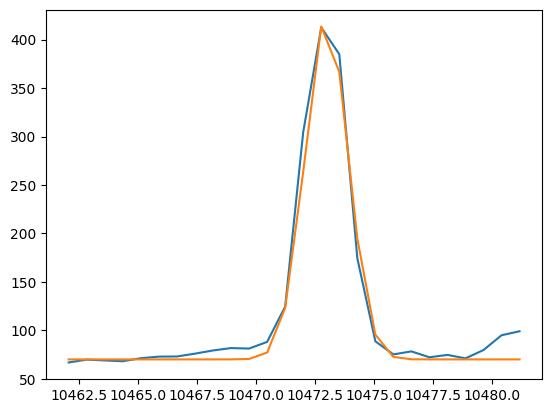

In [123]:
plt.plot(x_arc_9532, y_arc_9532)
plt.plot(x_arc_9532, 70 + gaussian(x_arc_9532, 800, 10473, 0, 0.9))

params_arc_9532 = Parameters()
params_arc_9532.add('z', value=0.0, vary=False)
params_arc_9532.add('mu', value=10473, vary=False)
params_arc_9532.add('arc', value=800, min=0.)
params_arc_9532.add('sigma', value=0.9, min=0.)
params_arc_9532.add('bkg', value=70, vary=False)

def residual_arc_9532(params_arc_9532, x, data, uncertainty):
    
    z = params_arc_9532['z']
    mu = params_arc_9532['mu']
    flux = params_arc_9532['arc']
    sigma = params_arc_9532['sigma']
    bkg = params_arc_9532['bkg']
    
    x = x_arc_9532
    model = bkg + gaussian(x, flux, mu, z, sigma)
    return (model - y_arc_9532) / 10

np.random.seed(21)
out_arc_9532 = minimize(residual_arc_9532, params_arc_9532, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

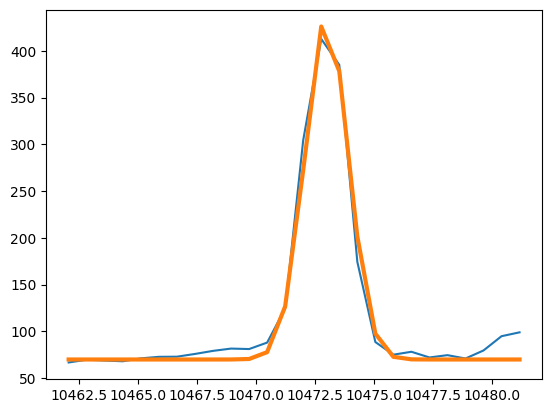

In [124]:
arc_9532 = out_arc_9532.flatchain.arc.mean()
sigma_arc_9532 = out_arc_9532.flatchain.sigma.mean()

plt.plot(x_arc_9532, y_arc_9532)

plt.plot(x_arc_9532, 70 + gaussian(x_arc_9532, arc_9532, 10473, 0, sigma_arc_9532), lw=3
)

### Line fitting

In [125]:
sigma_nar_9532 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_9532**2))
sigma_brd_9532 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_9532**2))

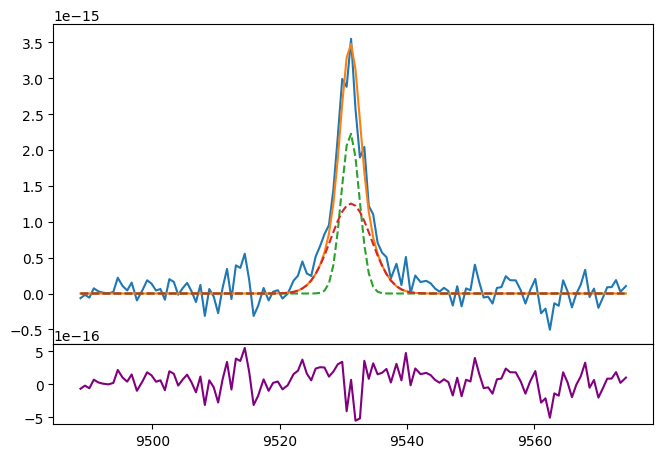

In [128]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(siii_9532.wavelength, siii_9532.flux)
bkg = 1e-16

siiia_nar = gaussian(siii_9532.wavelength, 8e-15, wave_cat['[SIII]9532'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_9532))
siiia_brd = gaussian(siii_9532.wavelength, 10e-15, wave_cat['[SIII]9532'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_9532))

ax.plot(siii_9532.wavelength, siiia_nar + siiia_brd)
ax.plot(siii_9532.wavelength, siiia_nar, ls='--')
ax.plot(siii_9532.wavelength, siiia_brd, ls='--')
ax1.plot(siii_9532.wavelength, siii_9532.flux - siiia_nar - siiia_brd, color='purple')

In [129]:
params_siiia = Parameters()
params_siiia.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_siiia.add('z_ratio', value=z_ratio, vary=False)
params_siiia.add('sigma_9532_nar', value=upy.nominal_values(sigma_nar_9532), vary=False)
params_siiia.add('sigma_9532_brd', value=upy.nominal_values(sigma_brd_9532), vary=False)
params_siiia.add('Siiia_nar', value=8e-15, min=0.)
params_siiia.add('Siiia_brd', value=10e-15, min=0.)

def residual_siiia(params_siiia, x, data, uncertainty):
    
    z_nar = params_siiia['z_nar']
    z_brd = params_siiia['z_nar'] * params_siiia['z_ratio']
    sigma_9532_nar = params_siiia['sigma_9532_nar']
    sigma_9532_brd = params_siiia['sigma_9532_brd']
    siiia_nar_flux = params_siiia['Siiia_nar']
    siiia_brd_flux = params_siiia['Siiia_brd']
    
    x = siii_9532.wavelength
    model = gaussian(x, siiia_nar_flux, wave_cat['[SIII]9532'], z_nar, sigma_9532_nar) + \
            gaussian(x, siiia_brd_flux, wave_cat['[SIII]9532'], z_brd, sigma_9532_brd)
    
    return (model - siii_9532.flux) / siii_9532.noise

In [130]:
np.random.seed(21)
out_siiia = minimize(residual_siiia, params_siiia, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:17<00:00, 144.08it/s]


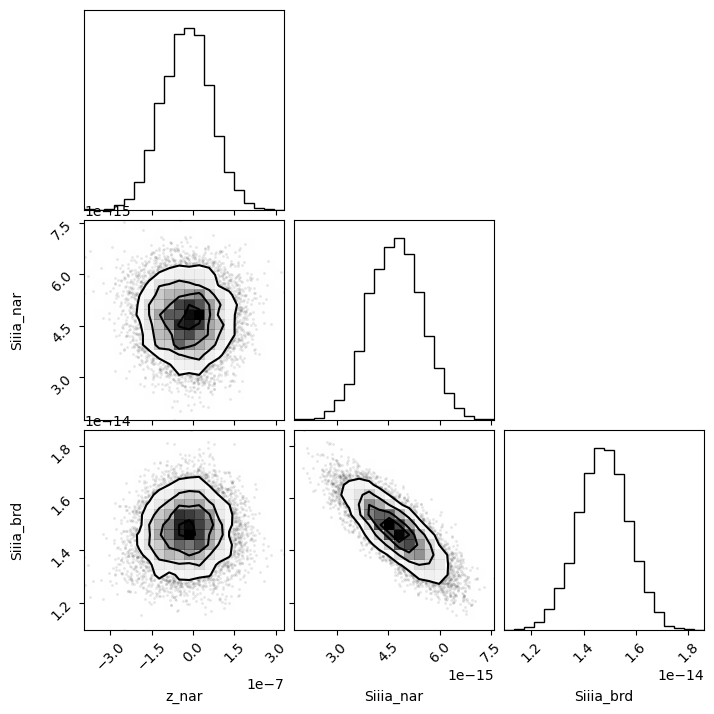

In [131]:
corner.corner(out_siiia.flatchain, labels=out_siiia.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [132]:
out_siiia.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,-2.1386e-08,8.7830e-08,(410.69%),6.760336358548223e-08,-inf,inf,True
z_ratio,178.554400,,,178.55439986698758,-inf,inf,False
sigma_9532_nar,1.42740826,,,1.4274082580228384,-inf,inf,False
sigma_9532_brd,3.18193464,,,3.181934639053855,-inf,inf,False
Siiia_nar,4.7249e-15,7.7788e-16,(16.46%),8e-15,0.00000000,inf,True
Siiia_brd,1.4764e-14,9.6260e-16,(6.52%),1e-14,0.00000000,inf,True


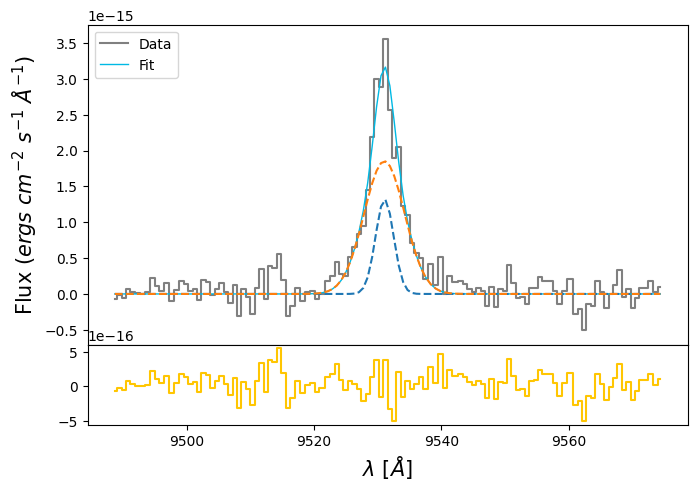

In [134]:
siiia_nar_flux = out_siiia.flatchain.Siiia_nar.mean()
siiia_nar_std = out_siiia.flatchain.Siiia_nar.std()

siiia_brd_flux = out_siiia.flatchain.Siiia_brd.mean()
siiia_brd_std = out_siiia.flatchain.Siiia_brd.std()

z_siiia = out_siiia.flatchain.z_nar.mean()
z_siiia_std = out_siiia.flatchain.z_nar.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(siii_9532.wavelength, siii_9532.flux,
            color='gray', label='Data', where='mid')

siiia_nar = gaussian(siii_9532.wavelength, siiia_nar_flux, wave_cat['[SIII]9532'], z_siiia, upy.nominal_values(sigma_nar_9532))
siiia_brd = gaussian(siii_9532.wavelength, siiia_brd_flux, wave_cat['[SIII]9532'], z_siiia * z_ratio, upy.nominal_values(sigma_brd_9532))
siiia = siiia_nar + siiia_brd

ax.plot(siii_9532.wavelength, siiia, lw=1, color=c[0], label='Fit')
ax.plot(siii_9532.wavelength, siiia_nar, ls='--')
ax.plot(siii_9532.wavelength, siiia_brd, ls='--')
ax1.step(siii_9532.wavelength, siii_9532.flux - siiia, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
#ax.set_yscale('log')
ax.legend(loc='upper left')

# [SIII]9069

### Arc lines

In [135]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_9069 = [wave_cat['[SIII]9069']*(1 + z_BN[igal]) + 70, wave_cat['[SIII]9069']*(1 + z_BN[igal]) + 100]
mask_arc_9069 = (wcal_red[18].data['wave_soln'][0] >= wlims_9069[0]) & (wcal_red[18].data['wave_soln'][0] < wlims_9069[1])

# Arc spectra around the fitted line
x_arc_9069 = wcal_red[18].data['wave_soln'][0][mask_arc_9069]
y_arc_9069 = wcal_red[21].data[:, 8][mask_arc_9069]

100%|██████████████████████████████████████| 2500/2500 [00:13<00:00, 181.23it/s]


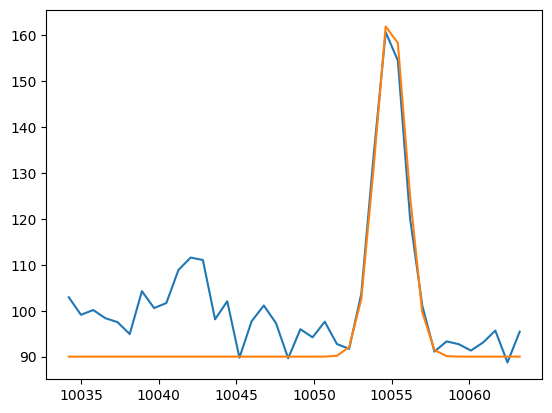

In [136]:
plt.plot(x_arc_9069, y_arc_9069)
plt.plot(x_arc_9069, 90 + gaussian(x_arc_9069, 190, 10054.95, 0, 1.0))

params_arc_9069 = Parameters()
params_arc_9069.add('z', value=0.0, vary=False)
params_arc_9069.add('mu', value=10054.95, vary=False)
params_arc_9069.add('arc', value=190, min=0.)
params_arc_9069.add('sigma', value=1.0, min=0.)
params_arc_9069.add('bkg', value=90, vary=False)

def residual_arc_9069(params_arc_9069, x, data, uncertainty):
    
    z = params_arc_9069['z']
    mu = params_arc_9069['mu']
    flux = params_arc_9069['arc']
    sigma = params_arc_9069['sigma']
    bkg = params_arc_9069['bkg']
    
    x = x_arc_9069
    model = bkg + gaussian(x, flux, mu, z, sigma)
    return (model - y_arc_9069) / 10

np.random.seed(21)
out_arc_9069 = minimize(residual_arc_9069, params_arc_9069, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

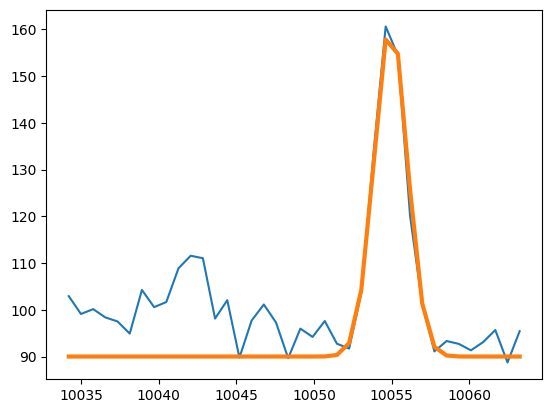

In [137]:
arc_9069 = out_arc_9069.flatchain.arc.mean()
sigma_arc_9069 = out_arc_9069.flatchain.sigma.mean()

plt.plot(x_arc_9069, y_arc_9069)
plt.plot(x_arc_9069, 90 + gaussian(x_arc_9069, arc_9069, 10054.95, 0, sigma_arc_9069), lw=3)

### Line fitting

In [138]:
sigma_nar_9069 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_9069**2))
sigma_brd_9069 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_9069**2))

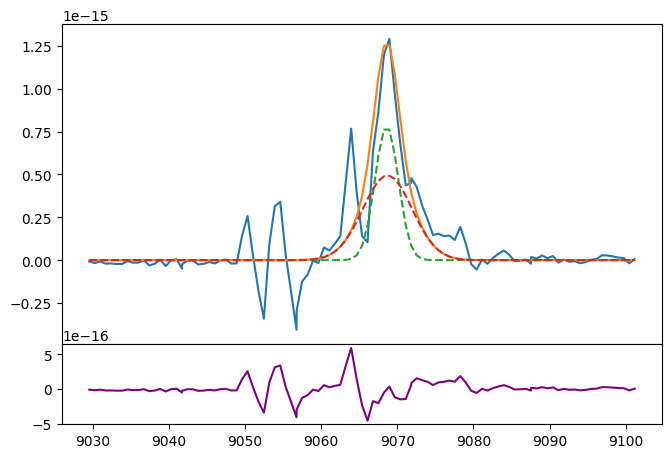

In [140]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(siii_9069.wavelength, siii_9069.flux)

siiib_nar = gaussian(siii_9069.wavelength, 3e-15, wave_cat['[SIII]9069'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_9069))
siiib_brd = gaussian(siii_9069.wavelength, 4e-15, wave_cat['[SIII]9069'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_9069))

ax.plot(siii_9069.wavelength, siiib_nar + siiib_brd)
ax.plot(siii_9069.wavelength, siiib_nar, ls='--')
ax.plot(siii_9069.wavelength, siiib_brd, ls='--')
ax1.plot(siii_9069.wavelength, siii_9069.flux - siiib_nar - siiib_brd, color='purple')
#ax.set_yscale('log')

In [141]:
params_siiib = Parameters()
params_siiib.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_siiib.add('z_ratio', value=z_ratio, vary=False)
params_siiib.add('sigma_9069_nar', value=upy.nominal_values(sigma_nar_9069), vary=False)
params_siiib.add('sigma_9069_brd', value=upy.nominal_values(sigma_brd_9069), vary=False)
params_siiib.add('Siiib_nar', value=3e-15, min=0.)
params_siiib.add('Siiib_brd', value=4e-15, min=0.)


def residual_siiib(params_siiib, x, data, uncertainty):
    
    z_nar = params_siiib['z_nar']
    z_brd = params_siiib['z_nar'] * params_siiib['z_ratio']
    sigma_9069_nar = params_siiib['sigma_9069_nar']
    sigma_9069_brd = params_siiib['sigma_9069_brd']
    siiib_nar_flux = params_siiib['Siiib_nar']
    siiib_brd_flux = params_siiib['Siiib_brd']
    
    x = siii_9069.wavelength
    model = gaussian(x, siiib_nar_flux, wave_cat['[SIII]9069'], z_nar, sigma_9069_nar) + \
            gaussian(x, siiib_brd_flux, wave_cat['[SIII]9069'], z_brd, sigma_9069_brd)
    
    return (model - siii_9069.flux) / siii_9069.noise

In [142]:
np.random.seed(21)
out_siiib = minimize(residual_siiib, params_siiib, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:17<00:00, 144.90it/s]


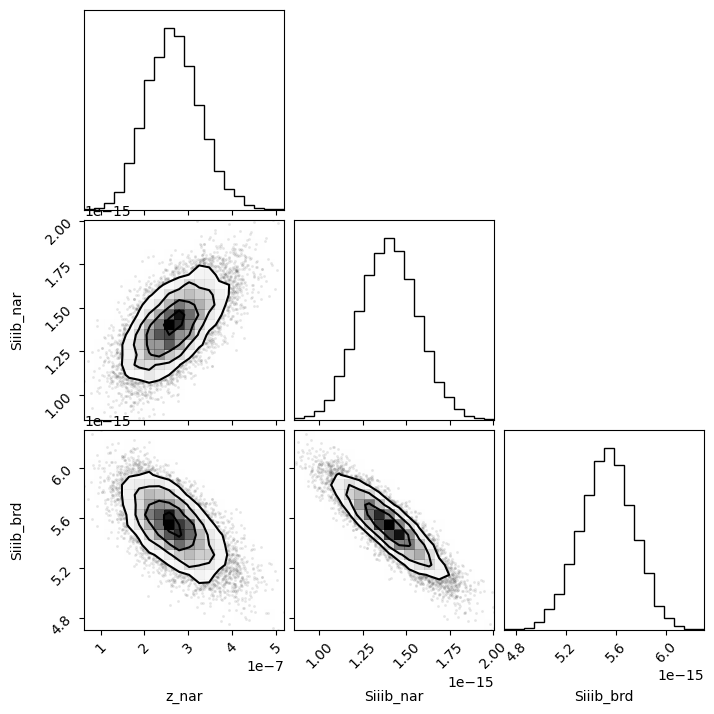

In [143]:
corner.corner(out_siiib.flatchain, labels=out_siiib.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [144]:
out_siiib.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,2.6488e-07,6.0209e-08,(22.73%),6.760336358548223e-08,-inf,inf,True
z_ratio,178.554400,,,178.55439986698758,-inf,inf,False
sigma_9069_nar,1.52797846,,,1.5279784623933055,-inf,inf,False
sigma_9069_brd,3.22830170,,,3.228301704252068,-inf,inf,False
Siiib_nar,1.3999e-15,1.6492e-16,(11.78%),3e-15,0.00000000,inf,True
Siiib_brd,5.5302e-15,2.1511e-16,(3.89%),4e-15,0.00000000,inf,True


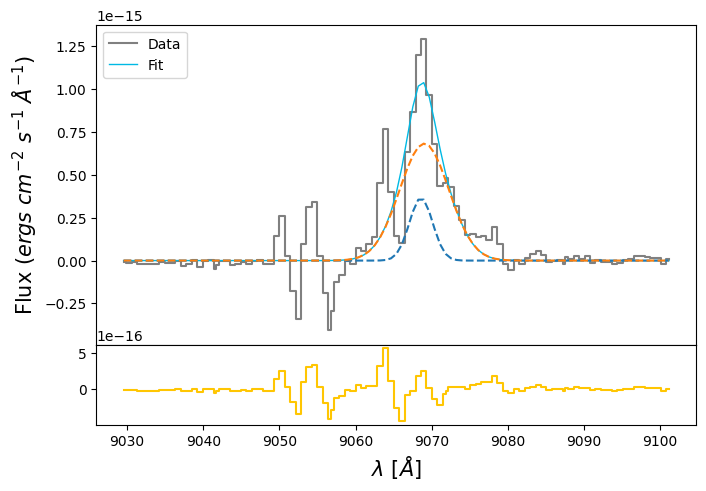

In [146]:
siiib_nar_flux = out_siiib.flatchain.Siiib_nar.mean()
siiib_nar_std = out_siiib.flatchain.Siiib_nar.std()

siiib_brd_flux = out_siiib.flatchain.Siiib_brd.mean()
siiib_brd_std = out_siiib.flatchain.Siiib_brd.std()

z_siiib = out_siiib.flatchain.z_nar.mean()
z_siiib_std = out_siiib.flatchain.z_nar.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(siii_9069.wavelength, siii_9069.flux,
            color='gray', label='Data', where='mid')

siiib_nar = gaussian(siii_9069.wavelength, siiib_nar_flux, wave_cat['[SIII]9069'], z_siiib, upy.nominal_values(sigma_nar_9069))
siiib_brd = gaussian(siii_9069.wavelength, siiib_brd_flux, wave_cat['[SIII]9069'], z_siiib * z_ratio, upy.nominal_values(sigma_brd_9069))
siiib = siiib_nar + siiib_brd

ax.plot(siii_9069.wavelength, siiib, lw=1, color=c[0], label='Fit')
ax.plot(siii_9069.wavelength, siiib_nar, ls='--')
ax.plot(siii_9069.wavelength, siiib_brd, ls='--')
ax1.step(siii_9069.wavelength, siii_9069.flux - siiib, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
#ax.set_yscale('log')
ax.legend(loc='upper left')

# [OI]6300 + [SIII]6312

### Arc lines

In [147]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_6312 = [wave_cat['[SIII]6312']*(1 + z_BN[igal]), wave_cat['[SIII]6312']*(1 + z_BN[igal]) + 25]
mask_arc_6312 = (wcal_red[12].data['wave_soln'][0] >= wlims_6312[0]) & (wcal_red[12].data['wave_soln'][0] < wlims_6312[1])

# Arc spectra around the fitted line
x_arc_6312 = wcal_red[12].data['wave_soln'][0][mask_arc_6312]
y_arc_6312 = wcal_red[21].data[:, 5][mask_arc_6312]

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 122.91it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [58.69398607 70.71223921 43.33333218 70.55339608]


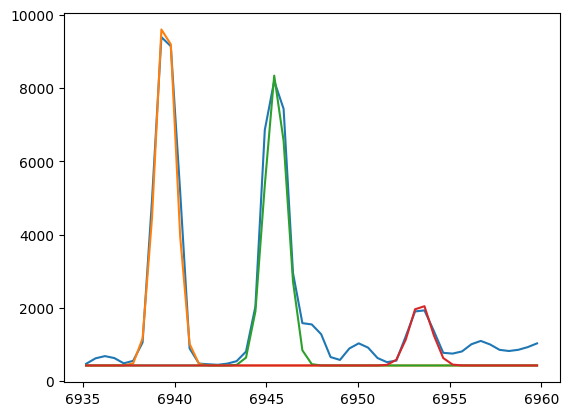

In [148]:
plt.plot(x_arc_6312, y_arc_6312)
plt.plot(x_arc_6312, 430 + gaussian(x_arc_6312, 13800, 6939.5, 0, 0.55))
plt.plot(x_arc_6312, 430 + gaussian(x_arc_6312, 12000, 6945.5, 0, 0.6))
plt.plot(x_arc_6312, 430 + gaussian(x_arc_6312, 2600, 6953.4, 0, 0.6))

params_arc_6312 = Parameters()
params_arc_6312.add('z', value=0.0, vary=False)
params_arc_6312.add('mu1', value=6939.5, vary=False)
params_arc_6312.add('mu2', value=6945.5, vary=False)
params_arc_6312.add('mu3', value=6953.4, vary=False)
params_arc_6312.add('arc1', value=13800, min=0.)
params_arc_6312.add('arc2', value=12000, min=0.)
params_arc_6312.add('arc3', value=2600, min=0.)
params_arc_6312.add('sigma', value=0.57, min=0.)
params_arc_6312.add('bkg', value=430, vary=False)

def residual_arc_6312(params_arc_6312, x, data, uncertainty):
    
    z = params_arc_6312['z']
    mu1 = params_arc_6312['mu1']
    mu2 = params_arc_6312['mu2']
    mu3 = params_arc_6312['mu3']
    flux1 = params_arc_6312['arc1']
    flux2 = params_arc_6312['arc2']
    flux3 = params_arc_6312['arc3']
    sigma = params_arc_6312['sigma']
    bkg = params_arc_6312['bkg']
    
    x = x_arc_6312
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3 
    return (model - y_arc_6312) / 10

np.random.seed(21)
out_arc_6312 = minimize(residual_arc_6312, params_arc_6312, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

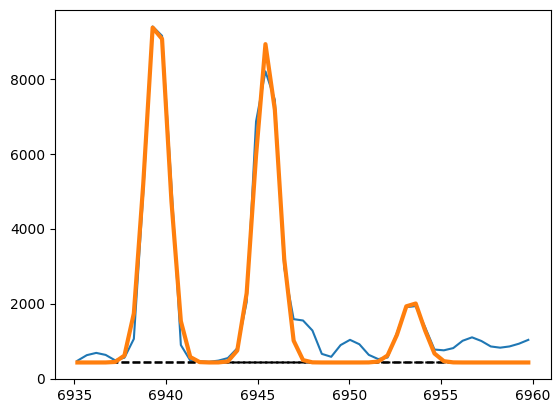

In [149]:
arc1_6312 = out_arc_6312.flatchain.arc1.mean()
arc2_6312 = out_arc_6312.flatchain.arc2.mean()
arc3_6312 = out_arc_6312.flatchain.arc3.mean()
sigma_arc_6312 = out_arc_6312.flatchain.sigma.mean()

plt.plot(x_arc_6312, y_arc_6312)

plt.plot(x_arc_6312, 430 + gaussian(x_arc_6312, arc1_6312, 6939.5, 0, sigma_arc_6312), ls='--', color='black')
plt.plot(x_arc_6312, 430 + gaussian(x_arc_6312, arc2_6312, 6945.5, 0, sigma_arc_6312), ls='--', color='black')
plt.plot(x_arc_6312, 430 + gaussian(x_arc_6312, arc3_6312, 6953.4, 0, sigma_arc_6312), ls='--', color='black')

plt.plot(x_arc_6312, 430 + gaussian(x_arc_6312, arc1_6312, 6939.5, 0, sigma_arc_6312) \
         + gaussian(x_arc_6312, arc2_6312, 6945.5, 0, sigma_arc_6312) \
         + gaussian(x_arc_6312, arc3_6312, 6953.4, 0, sigma_arc_6312), lw=3
)

### Line fitting

In [150]:
sigma_nar_6312 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_6312**2))
sigma_brd_6312 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_6312**2))

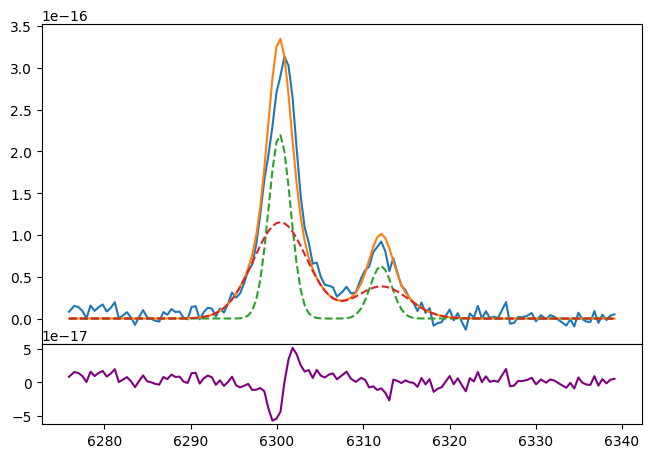

In [152]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oi_siii.wavelength, oi_siii.flux)
bkg = 2.2e-16

oi_nar = gaussian(oi_siii.wavelength, 7e-16, wave_cat['[OI]6300'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6312))
oi_brd = gaussian(oi_siii.wavelength, 9e-16, wave_cat['[OI]6300'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6312))

siiic_nar = gaussian(oi_siii.wavelength, 2e-16, wave_cat['[SIII]6312'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_6312))
siiic_brd = gaussian(oi_siii.wavelength, 3e-16, wave_cat['[SIII]6312'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_6312))

ax.plot(oi_siii.wavelength, siiic_nar + siiic_brd + oi_nar + oi_brd)
ax.plot(oi_siii.wavelength, siiic_nar + oi_nar, ls='--')
ax.plot(oi_siii.wavelength, siiic_brd + oi_brd, ls='--')
ax1.plot(oi_siii.wavelength, oi_siii.flux - siiic_nar - siiic_brd - oi_nar - oi_brd, color='purple')
#ax.set_yscale('log')

In [153]:
params_oi_siii = Parameters()
params_oi_siii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oi_siii.add('z_ratio', value=z_ratio, vary=False)
params_oi_siii.add('sigma_6312_nar', value=upy.nominal_values(sigma_nar_6312), vary=False)
params_oi_siii.add('sigma_6312_brd', value=upy.nominal_values(sigma_brd_6312), vary=False)
params_oi_siii.add('sigma_6300_nar', value=upy.nominal_values(sigma_nar_6312), vary=False)
params_oi_siii.add('sigma_6300_brd', value=upy.nominal_values(sigma_brd_6312), vary=False)
params_oi_siii.add('Oi_nar', value=7.0e-16, min=0.)
params_oi_siii.add('Oi_brd', value=9.0e-16, min=0.)
params_oi_siii.add('Siiic_nar', value=2.0e-16, min=0.)
params_oi_siii.add('Siiic_brd', value=3.0e-16, min=0.)


def residual_oi_siii(params_oi_siii, x, data, uncertainty):
    
    z_nar = params_oi_siii['z_nar']
    z_brd = params_oi_siii['z_nar'] * params_oi_siii['z_ratio']
    sigma_6312_nar = params_oi_siii['sigma_6312_nar']
    sigma_6312_brd = params_oi_siii['sigma_6312_brd']
    sigma_6300_nar = params_oi_siii['sigma_6300_nar']
    sigma_6300_brd = params_oi_siii['sigma_6300_brd']
    oi_nar = params_oi_siii['Oi_nar']
    oi_brd = params_oi_siii['Oi_brd']
    siiic_nar = params_oi_siii['Siiic_nar']
    siiic_brd = params_oi_siii['Siiic_brd']
    
    x = oi_siii.wavelength
    model_oi = gaussian(x, oi_nar, wave_cat['[OI]6300'], z_nar, sigma_6300_nar) \
             + gaussian(x, oi_brd, wave_cat['[OI]6300'], z_brd, sigma_6300_brd)
    model_siii = gaussian(x, siiic_nar, wave_cat['[SIII]6312'], z_nar, sigma_6312_nar) \
               + gaussian(x, siiic_brd, wave_cat['[SIII]6312'], z_brd, sigma_6312_brd)
    
    return (model_siii + model_oi - oi_siii.flux) / oi_siii.noise

In [154]:
np.random.seed(21)
out_oi_siii = minimize(residual_oi_siii, params_oi_siii, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:24<00:00, 103.84it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [105.54964801  51.22257334  55.71728933  45.16982135  49.70863691]


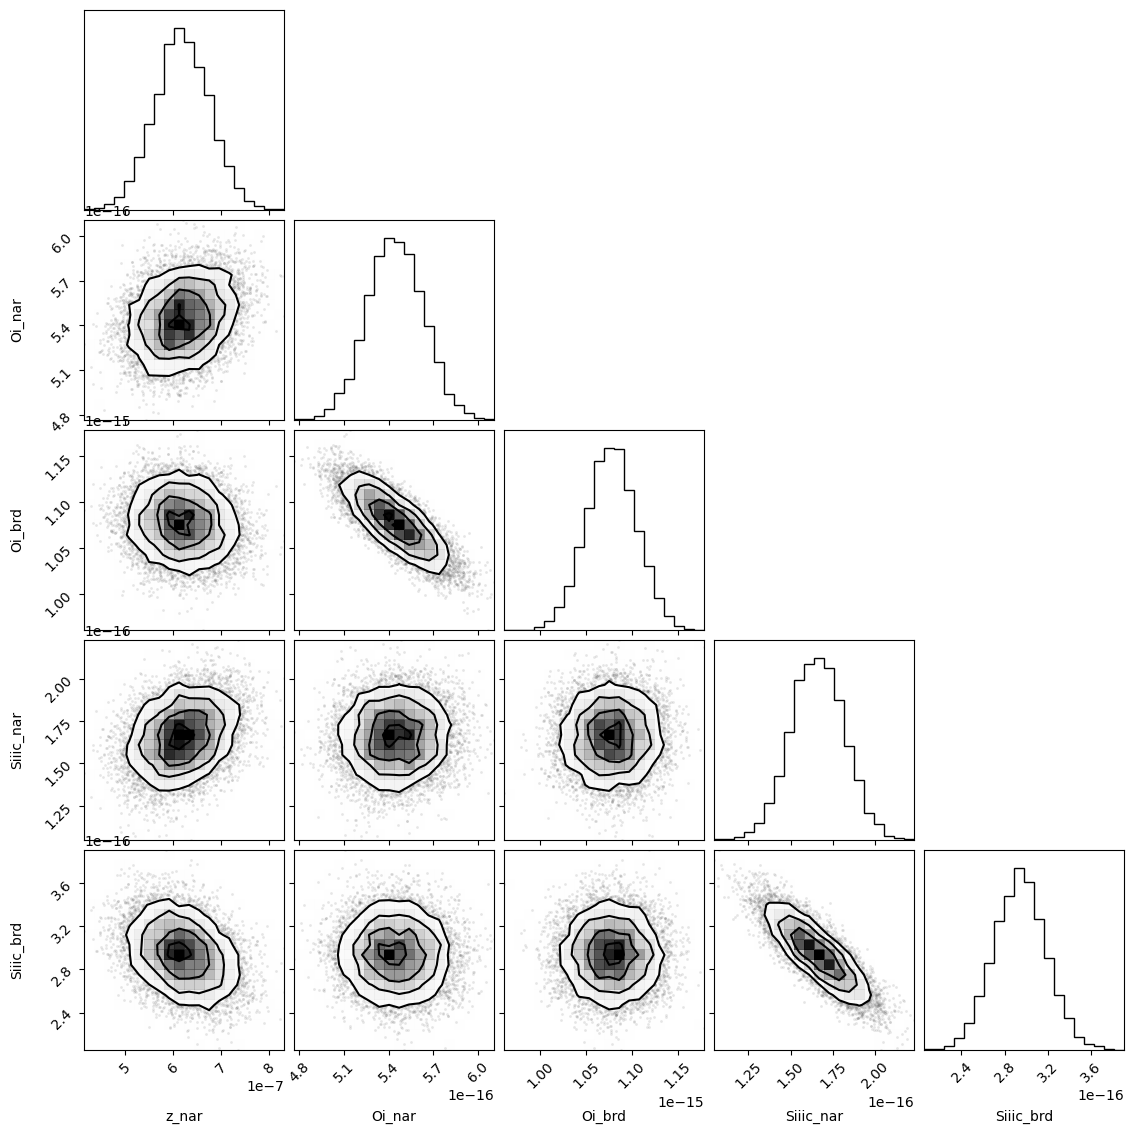

In [155]:
corner.corner(out_oi_siii.flatchain, labels=out_oi_siii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [156]:
out_oi_siii.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,6.1853e-07,5.7478e-08,(9.29%),6.760336358548223e-08,-inf,inf,True
z_ratio,178.554400,,,178.55439986698758,-inf,inf,False
sigma_6312_nar,1.26882925,,,1.2688292547943925,-inf,inf,False
sigma_6312_brd,3.11402334,,,3.114023344479146,-inf,inf,False
sigma_6300_nar,1.26882925,,,1.2688292547943925,-inf,inf,False
sigma_6300_brd,3.11402334,,,3.114023344479146,-inf,inf,False
Oi_nar,5.4443e-16,1.8698e-17,(3.43%),7e-16,0.00000000,inf,True
Oi_brd,1.0775e-15,2.7488e-17,(2.55%),9e-16,0.00000000,inf,True
Siiic_nar,1.6573e-16,1.5693e-17,(9.47%),2e-16,0.00000000,inf,True
Siiic_brd,2.9421e-16,2.4049e-17,(8.17%),3e-16,0.00000000,inf,True


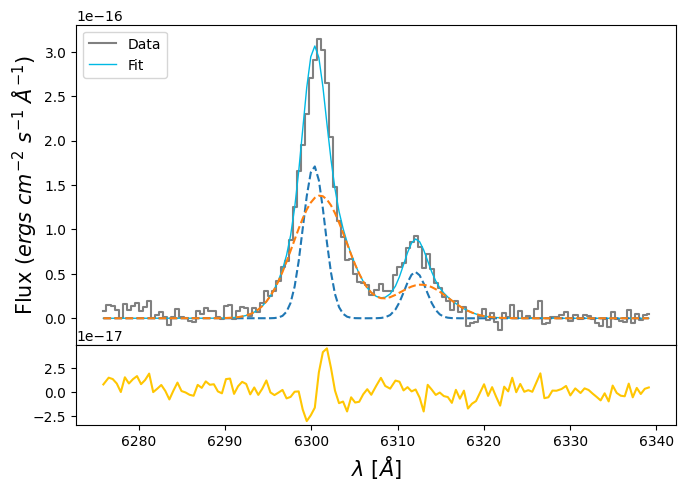

In [158]:
oi_nar_flux = out_oi_siii.flatchain.Oi_nar.mean()
oi_nar_std = out_oi_siii.flatchain.Oi_nar.std()

oi_brd_flux = out_oi_siii.flatchain.Oi_brd.mean()
oi_brd_std = out_oi_siii.flatchain.Oi_brd.std()

siiic_nar_flux = out_oi_siii.flatchain.Siiic_nar.mean()
siiic_nar_std = out_oi_siii.flatchain.Siiic_nar.std()

siiic_brd_flux = out_oi_siii.flatchain.Siiic_brd.mean()
siiic_brd_std = out_oi_siii.flatchain.Siiic_brd.std()

z_oi_siii = out_oi_siii.flatchain.z_nar.mean()
z_oi_siii_std = out_oi_siii.flatchain.z_nar.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oi_siii.wavelength, oi_siii.flux,
            color='gray', label='Data', where='mid')

oi_nar = gaussian(oi_siii.wavelength, oi_nar_flux, wave_cat['[OI]6300'], z_oi_siii, upy.nominal_values(sigma_nar_6312))
oi_brd = gaussian(oi_siii.wavelength, oi_brd_flux, wave_cat['[OI]6300'], z_oi_siii * z_ratio, upy.nominal_values(sigma_brd_6312))

siiic_nar = gaussian(oi_siii.wavelength, siiic_nar_flux, wave_cat['[SIII]6312'], z_oi_siii, upy.nominal_values(sigma_nar_6312))
siiic_brd = gaussian(oi_siii.wavelength, siiic_brd_flux, wave_cat['[SIII]6312'], z_oi_siii * z_ratio, upy.nominal_values(sigma_brd_6312))

oi = oi_nar + oi_brd
siiic = siiic_nar + siiic_brd

ax.plot(oi_siii.wavelength, siiic + oi,
        lw=1, color=c[0], label='Fit')
ax.plot(oi_siii.wavelength, siiic_nar + oi_nar, ls='--')
ax.plot(oi_siii.wavelength, siiic_brd + oi_brd, ls='--')

ax1.plot(oi_siii.wavelength, oi_siii.flux - siiic - oi,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
#ax.set_yscale('log')
ax.legend(loc='upper left')

# [OIII]5007 + HeI 5015

### Arc lines

In [159]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_5007 = [wave_cat['[OIII]5007']*(1 + z_BN[igal]) - 10, wave_cat['[OIII]5007']*(1 + z_BN[igal]) + 10]
mask_arc_5007 = (wcal_red[8].data['wave_soln'][0] >= wlims_5007[0]) & (wcal_red[8].data['wave_soln'][0] < wlims_5007[1])

# Arc spectra around the fitted line
x_arc_5007 = wcal_red[8].data['wave_soln'][0][mask_arc_5007]
y_arc_5007 = wcal_red[21].data[:, 3][mask_arc_5007]

100%|██████████████████████████████████████| 2500/2500 [00:22<00:00, 109.02it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 27.88888667  36.4387168   64.19976547 118.21808815  69.51913566]


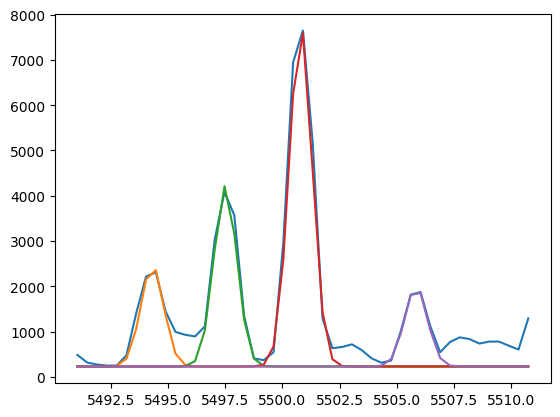

In [160]:
plt.plot(x_arc_5007, y_arc_5007)
plt.plot(x_arc_5007, 230 + gaussian(x_arc_5007, 2800, 5494.3, 0, 0.5))
plt.plot(x_arc_5007, 230 + gaussian(x_arc_5007, 5000, 5497.5, 0, 0.5))
plt.plot(x_arc_5007, 230 + gaussian(x_arc_5007, 9400, 5500.8, 0, 0.5))
plt.plot(x_arc_5007, 230 + gaussian(x_arc_5007, 2200, 5505.85, 0, 0.5))

params_arc_5007 = Parameters()
params_arc_5007.add('z', value=0.0, vary=False)
params_arc_5007.add('mu1', value=5494.3, vary=False)
params_arc_5007.add('mu2', value=5497.5, vary=False)
params_arc_5007.add('mu3', value=5500.8, vary=False)
params_arc_5007.add('mu4', value=5505.85, vary=False)
params_arc_5007.add('arc1', value=2800, min=0.)
params_arc_5007.add('arc2', value=5000, min=0.)
params_arc_5007.add('arc3', value=9400, min=0.)
params_arc_5007.add('arc4', value=2200, min=0.)
params_arc_5007.add('sigma', value=0.5, min=0.)
params_arc_5007.add('bkg', value=230, vary=False)

def residual_arc_5007(params_arc_5007, x, data, uncertainty):
    
    z = params_arc_5007['z']
    mu1 = params_arc_5007['mu1']
    mu2 = params_arc_5007['mu2']
    mu3 = params_arc_5007['mu3']
    mu4 = params_arc_5007['mu4']
    flux1 = params_arc_5007['arc1']
    flux2 = params_arc_5007['arc2']
    flux3 = params_arc_5007['arc3']
    flux4 = params_arc_5007['arc4']
    sigma = params_arc_5007['sigma']
    bkg = params_arc_5007['bkg']
    
    x = x_arc_5007
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model = bkg + model1 + model2 + model3 + model4
    return (model - y_arc_5007) / 10

np.random.seed(21)
out_arc_5007 = minimize(residual_arc_5007, params_arc_5007, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

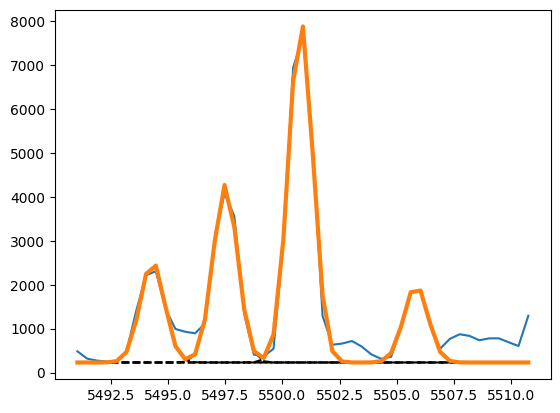

In [161]:
arc1_5007 = out_arc_5007.flatchain.arc1.mean()
arc2_5007 = out_arc_5007.flatchain.arc2.mean()
arc3_5007 = out_arc_5007.flatchain.arc3.mean()
arc4_5007 = out_arc_5007.flatchain.arc4.mean()
sigma_arc_5007 = out_arc_5007.flatchain.sigma.mean()

plt.plot(x_arc_5007, y_arc_5007)

plt.plot(x_arc_5007, 230 + gaussian(x_arc_5007, arc1_5007, 5494.3, 0, sigma_arc_5007), ls='--', color='black')
plt.plot(x_arc_5007, 230 + gaussian(x_arc_5007, arc2_5007, 5497.5, 0, sigma_arc_5007), ls='--', color='black')
plt.plot(x_arc_5007, 230 + gaussian(x_arc_5007, arc3_5007, 5500.8, 0, sigma_arc_5007), ls='--', color='black')
plt.plot(x_arc_5007, 230 + gaussian(x_arc_5007, arc4_5007, 5505.85, 0, sigma_arc_5007), ls='--', color='black')

plt.plot(x_arc_5007, 230 + gaussian(x_arc_5007, arc1_5007, 5494.3, 0, sigma_arc_5007) \
         + gaussian(x_arc_5007, arc2_5007, 5497.5, 0, sigma_arc_5007) \
         + gaussian(x_arc_5007, arc3_5007, 5500.8, 0, sigma_arc_5007) \
         + gaussian(x_arc_5007, arc4_5007, 5505.85, 0, sigma_arc_5007), lw=3
)

### Line fitting

In [162]:
sigma_nar_5007 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_5007**2))
sigma_brd_5007 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_5007**2))

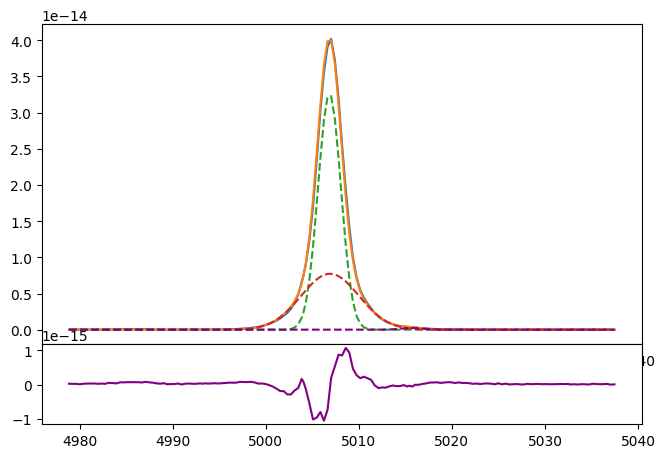

In [165]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_hei.wavelength, oiii_hei.flux)

oiiia_nar = gaussian(oiii_hei.wavelength, 10e-14, wave_cat['[OIII]5007'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_5007))
oiiia_brd = gaussian(oiii_hei.wavelength, 6e-14, wave_cat['[OIII]5007'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_5007))

hei_5015 = gaussian(oiii_hei.wavelength, 7e-16, wave_cat['HeI5015'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_5007))

ax.plot(oiii_hei.wavelength, oiiia_nar + oiiia_brd + hei_5015)
ax.plot(oiii_hei.wavelength, oiiia_nar, ls='--')
ax.plot(oiii_hei.wavelength, oiiia_brd, ls='--')
ax.plot(oiii_hei.wavelength, hei_5015, ls='--', color='purple')
ax1.plot(oiii_hei.wavelength, oiii_hei.flux - oiiia_nar - oiiia_brd - hei_5015, color='purple')
#ax.set_yscale('log')

In [166]:
params_oiii_hei = Parameters()
params_oiii_hei.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oiii_hei.add('z_ratio', value=z_ratio, vary=False)
params_oiii_hei.add('sigma_5007_nar', value=upy.nominal_values(sigma_nar_5007), vary=False)
params_oiii_hei.add('sigma_5007_brd', value=upy.nominal_values(sigma_brd_5007), vary=False)
params_oiii_hei.add('Hei', value=7e-16, min=0.)
params_oiii_hei.add('Oiiia_nar', value=10e-14, min=0.)
params_oiii_hei.add('Oiiia_brd', value=6e-14, min=0.)


def residual_oiii_hei(params_oiii_hei, x, data, uncertainty):
    
    z_nar = params_oiii_hei['z_nar']
    z_brd = params_oiii_hei['z_nar'] * params_oiii_hei['z_ratio']
    sigma_5007_nar = params_oiii_hei['sigma_5007_nar']
    sigma_5007_brd = params_oiii_hei['sigma_5007_brd']
    oiiia_nar = params_oiii_hei['Oiiia_nar']
    oiiia_brd = params_oiii_hei['Oiiia_brd']
    hei = params_oiii_hei['Hei']
    
    x = oiii_hei.wavelength
    model_oiii = gaussian(x, oiiia_nar, wave_cat['[OIII]5007'], z_nar, sigma_5007_nar) \
               + gaussian(x, oiiia_brd, wave_cat['[OIII]5007'], z_brd, sigma_5007_brd)
    model_hei = gaussian(x, hei, wave_cat['HeI5015'], z_nar, sigma_5007_nar)
    
    return (model_oiii + model_hei - oiii_hei.flux) / oiii_hei.noise

In [167]:
np.random.seed(21)
out_oiii_hei = minimize(residual_oiii_hei, params_oiii_hei, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:21<00:00, 117.08it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [96.07919045 57.06663636 41.09051475 39.39218808]


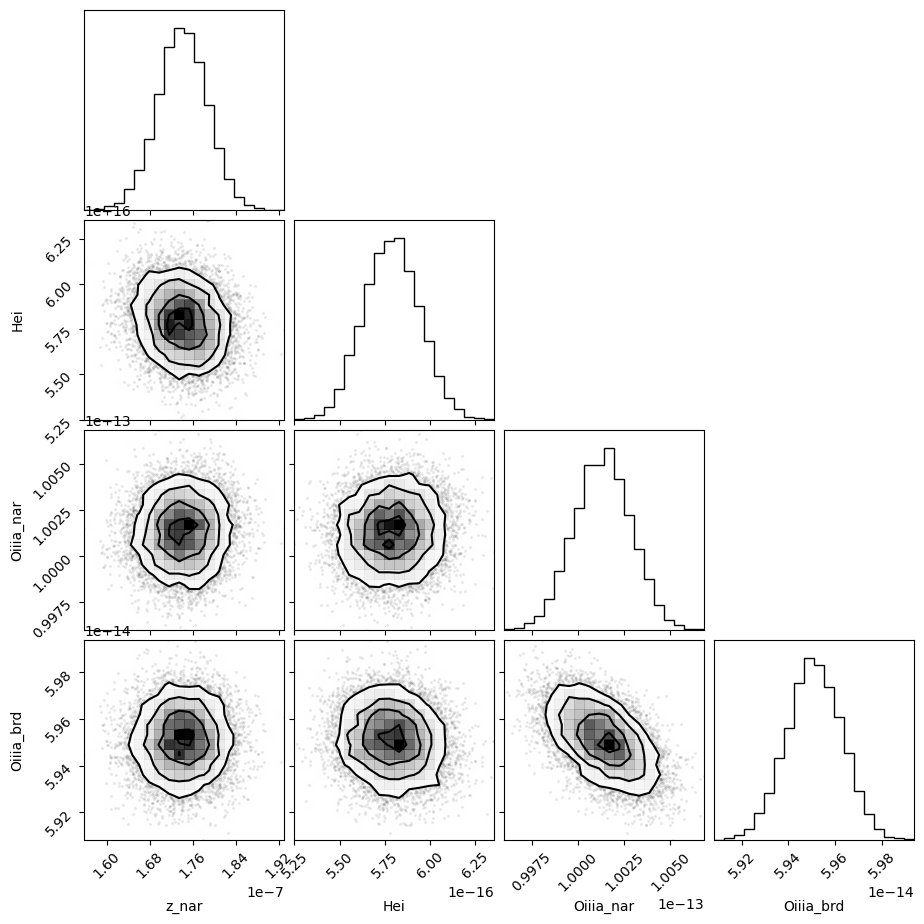

In [168]:
corner.corner(out_oiii_hei.flatchain, labels=out_oiii_hei.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [169]:
out_oiii_hei.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,1.7409e-07,4.5798e-09,(2.63%),6.760336358548223e-08,-inf,inf,True
z_ratio,178.554400,,,178.55439986698758,-inf,inf,False
sigma_5007_nar,1.22290217,,,1.2229021688891244,-inf,inf,False
sigma_5007_brd,3.09559420,,,3.095594196081379,-inf,inf,False
Hei,5.7868e-16,1.5474e-17,(2.67%),7e-16,0.00000000,inf,True
Oiiia_nar,1.0014e-13,1.5555e-16,(0.16%),1e-13,0.00000000,inf,True
Oiiia_brd,5.9512e-14,1.1865e-16,(0.20%),6e-14,0.00000000,inf,True


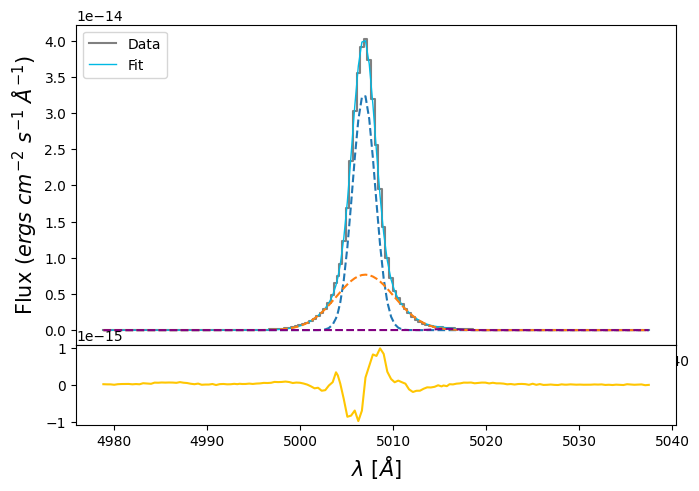

In [171]:
hei_flux = out_oiii_hei.flatchain.Hei.mean()
hei_std = out_oiii_hei.flatchain.Hei.std()

oiiia_nar_flux = out_oiii_hei.flatchain.Oiiia_nar.mean()
oiiia_nar_std = out_oiii_hei.flatchain.Oiiia_nar.std()

oiiia_brd_flux = out_oiii_hei.flatchain.Oiiia_brd.mean()
oiiia_brd_std = out_oiii_hei.flatchain.Oiiia_brd.std()

z_oiii_hei = out_oiii_hei.flatchain.z_nar.mean()
z_oiii_hei_std = out_oiii_hei.flatchain.z_nar.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_hei.wavelength, oiii_hei.flux,
            color='gray', label='Data', where='mid')

hei = gaussian(oiii_hei.wavelength, hei_flux, wave_cat['HeI5015'], z_oiii_hei, upy.nominal_values(sigma_nar_5007))

oiiia_nar = gaussian(oiii_hei.wavelength, oiiia_nar_flux, wave_cat['[OIII]5007'], z_oiii_hei, upy.nominal_values(sigma_nar_5007))
oiiia_brd = gaussian(oiii_hei.wavelength, oiiia_brd_flux, wave_cat['[OIII]5007'], z_oiii_hei * z_ratio, upy.nominal_values(sigma_brd_5007))

oiiia = oiiia_nar + oiiia_brd

ax.plot(oiii_hei.wavelength, oiiia + hei,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_hei.wavelength, oiiia_nar, ls='--')
ax.plot(oiii_hei.wavelength, oiiia_brd, ls='--')
ax.plot(oiii_hei.wavelength, hei, ls='--', color='purple')

ax1.plot(oiii_hei.wavelength, oiii_hei.flux - oiiia - hei,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
#ax.set_yscale('log')
ax.legend(loc='upper left')

# [OIII]4363

### Arc lines

In [172]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_4363 = [wave_cat['[OIII]4363']*(1 + z_BN[igal]) - 10, wave_cat['[OIII]4363']*(1 + z_BN[igal])]
mask_arc_4363 = (wcal_blue[10].data['wave_soln'][0] >= wlims_4363[0]) & (wcal_blue[10].data['wave_soln'][0] < wlims_4363[1])

# Arc spectra around the fitted line
x_arc_4363 = wcal_blue[10].data['wave_soln'][0][mask_arc_4363]
y_arc_4363 = wcal_blue[27].data[:, 4][mask_arc_4363]

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 122.81it/s]


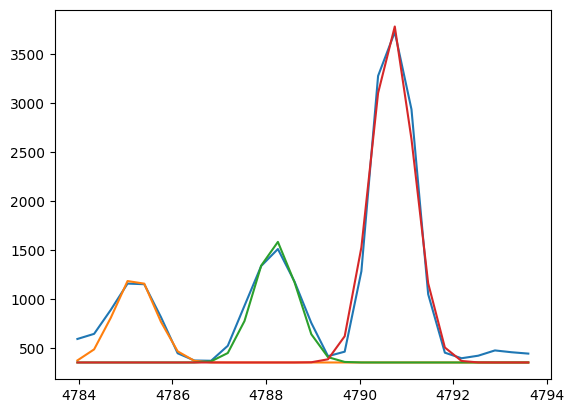

In [ ]:
plt.plot(x_arc_4363, y_arc_4363)
plt.plot(x_arc_4363, 350 + gaussian(x_arc_4363, 1000, 4785.2, 0, 0.45))
plt.plot(x_arc_4363, 350 + gaussian(x_arc_4363, 1400, 4788.2, 0, 0.45))
plt.plot(x_arc_4363, 350 + gaussian(x_arc_4363, 3900, 4790.7, 0, 0.45))

params_arc_4363 = Parameters()
params_arc_4363.add('z', value=0.0, vary=False)
params_arc_4363.add('mu1', value=4785.2, vary=False)
params_arc_4363.add('mu2', value=4788.2, vary=False)
params_arc_4363.add('mu3', value=4790.7, vary=False)
params_arc_4363.add('arc1', value=1000, min=0.)
params_arc_4363.add('arc2', value=1400, min=0.)
params_arc_4363.add('arc3', value=3900, min=0.)
params_arc_4363.add('sigma', value=0.45, min=0.)
params_arc_4363.add('bkg', value=350, vary=False)

def residual_arc_4363(params_arc_4363, x, data, uncertainty):
    
    z = params_arc_4363['z']
    mu1 = params_arc_4363['mu1']
    mu2 = params_arc_4363['mu2']
    mu3 = params_arc_4363['mu3']
    flux1 = params_arc_4363['arc1']
    flux2 = params_arc_4363['arc2']
    flux3 = params_arc_4363['arc3']
    sigma = params_arc_4363['sigma']
    bkg = params_arc_4363['bkg']
    
    x = x_arc_4363
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_4363) / 10

np.random.seed(21)
out_arc_4363 = minimize(residual_arc_4363, params_arc_4363, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

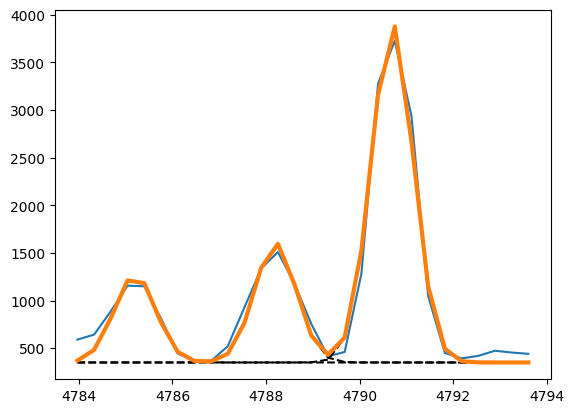

In [ ]:
arc1_4363 = out_arc_4363.flatchain.arc1.mean()
arc2_4363 = out_arc_4363.flatchain.arc2.mean()
arc3_4363 = out_arc_4363.flatchain.arc3.mean()
sigma_arc_4363 = out_arc_4363.flatchain.sigma.mean()

plt.plot(x_arc_4363, y_arc_4363)

plt.plot(x_arc_4363, 350 + gaussian(x_arc_4363, arc1_4363, 4785.2, 0, sigma_arc_4363), ls='--', color='black')
plt.plot(x_arc_4363, 350 + gaussian(x_arc_4363, arc2_4363, 4788.2, 0, sigma_arc_4363), ls='--', color='black')
plt.plot(x_arc_4363, 350 + gaussian(x_arc_4363, arc3_4363, 4790.7, 0, sigma_arc_4363), ls='--', color='black')

plt.plot(x_arc_4363, 350 + gaussian(x_arc_4363, arc1_4363, 4785.2, 0, sigma_arc_4363) \
         + gaussian(x_arc_4363, arc2_4363, 4788.2, 0, sigma_arc_4363) \
         + gaussian(x_arc_4363, arc3_4363, 4790.7, 0, sigma_arc_4363), lw=3
)

### Line fitting

In [ ]:
sigma_nar_4363 = upy.sqrt((sigma_nar_intrinsic**2) + (sigma_arc_4363**2))
sigma_brd_4363 = upy.sqrt((sigma_brd_intrinsic**2) + (sigma_arc_4363**2))

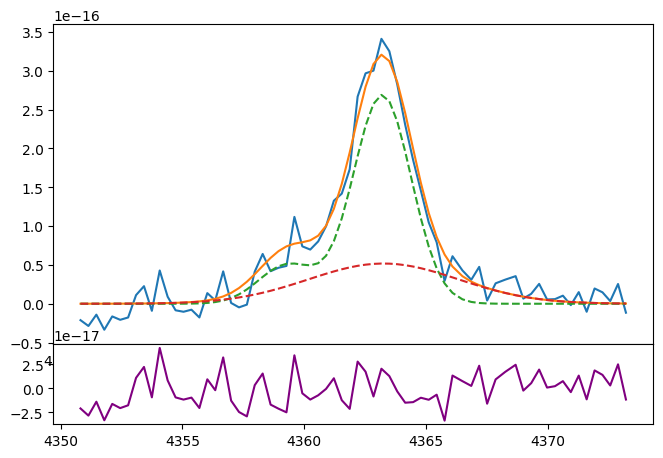

In [178]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4363.wavelength, oiii_4363.flux)

feii_4360 = gaussian(oiii_4363.wavelength, 1.5e-16, wave_cat['[FeII]4360'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4363))
oiiic_nar = gaussian(oiii_4363.wavelength, 8e-16, wave_cat['[OIII]4363'], z=z_nar_oiii_4959, sigma=upy.nominal_values(sigma_nar_4363))
oiiic_brd = gaussian(oiii_4363.wavelength, 4e-16, wave_cat['[OIII]4363'], z=z_brd_oiii_4959, sigma=upy.nominal_values(sigma_brd_4363))

ax.plot(oiii_4363.wavelength, oiiic_nar + oiiic_brd + feii_4360)
ax.plot(oiii_4363.wavelength, oiiic_nar + feii_4360, ls='--')
ax.plot(oiii_4363.wavelength, oiiic_brd, ls='--')
ax1.plot(oiii_4363.wavelength, oiii_4363.flux - oiiic_nar - oiiic_brd - feii_4360, color='purple')

In [179]:
params_oiiic = Parameters()

params_oiiic.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_oiiic.add('z_ratio', value=z_ratio, vary=False)
params_oiiic.add('sigma_4363_nar', value=upy.nominal_values(sigma_nar_4363), vary=False)
params_oiiic.add('sigma_4363_brd', value=upy.nominal_values(sigma_brd_4363), vary=False)
params_oiiic.add('Feii_4360_nar', value=1.5e-16, min=0.)
params_oiiic.add('Oiiic_nar', value=8e-16, min=0.)
params_oiiic.add('Oiiic_brd', value=4e-16, min=0.)


def residual_oiiic(params_oiiic, x, data, uncertainty):
    
    z_nar = params_oiiic['z_nar']
    z_brd = params_oiiic['z_nar'] * params_oiiic['z_ratio']
    sigma_4363_nar = params_oiiic['sigma_4363_nar']
    sigma_4363_brd = params_oiiic['sigma_4363_brd']
    feii_4360_flux = params_oiiic['Feii_4360_nar']
    oiiic_nar_flux = params_oiiic['Oiiic_nar']
    oiiic_brd_flux = params_oiiic['Oiiic_brd']
    
    x = oiii_4363.wavelength
    model = gaussian(x, feii_4360_flux, wave_cat['[FeII]4360'], z_nar, sigma_4363_nar) + \
            gaussian(x, oiiic_nar_flux, wave_cat['[OIII]4363'], z_nar, sigma_4363_nar) + \
            gaussian(x, oiiic_brd_flux, wave_cat['[OIII]4363'], z_brd, sigma_4363_brd)
    
    return (model - oiii_4363.flux) / oiii_4363.noise

In [180]:
np.random.seed(21)
out_oiiic = minimize(residual_oiiic, params_oiiic, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 125.90it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [69.44509558 63.99425232 70.85469097 70.47512058]


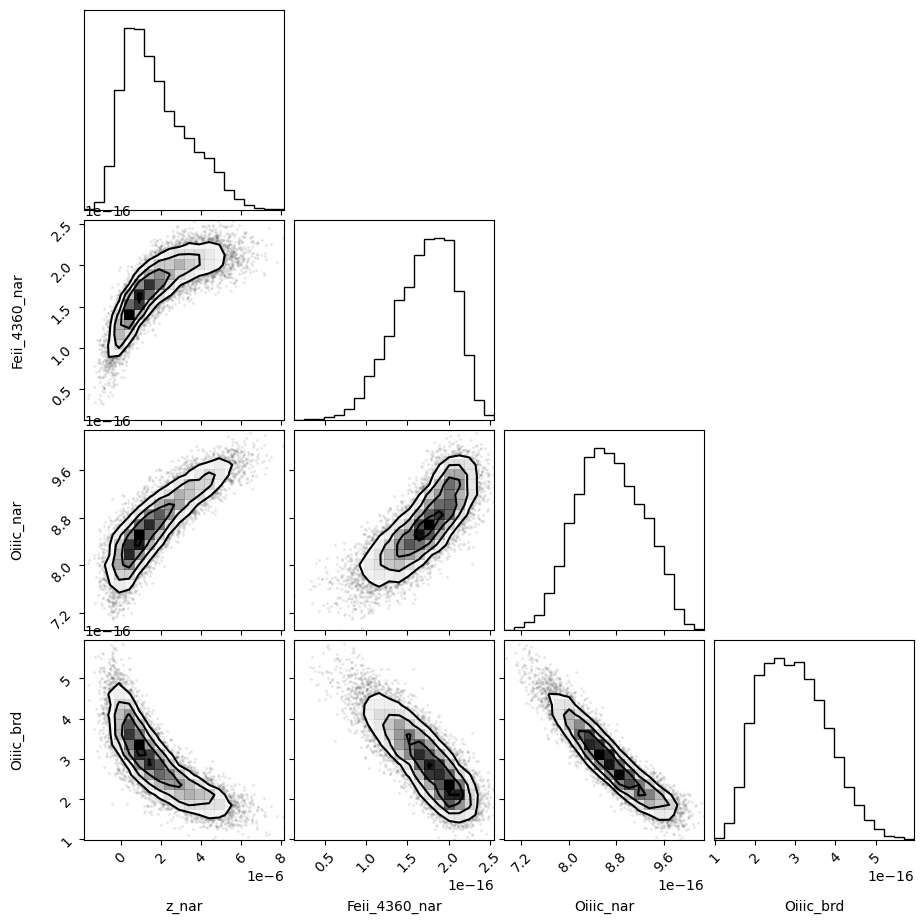

In [181]:
corner.corner(out_oiiic.flatchain, labels=out_oiiic.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [182]:
out_oiiic.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,1.4802e-06,1.6593e-06,(112.10%),6.760336358548223e-08,-inf,inf,True
z_ratio,178.554400,,,178.55439986698758,-inf,inf,False
sigma_4363_nar,1.18769801,,,1.1876980083904634,-inf,inf,False
sigma_4363_brd,3.08185663,,,3.081856627306609,-inf,inf,False
Feii_4360_nar,1.7435e-16,3.6625e-17,(21.01%),1.5e-16,0.00000000,inf,True
Oiiic_nar,8.6737e-16,5.8664e-17,(6.76%),8e-16,0.00000000,inf,True
Oiiic_brd,2.9088e-16,8.6912e-17,(29.88%),4e-16,0.00000000,inf,True


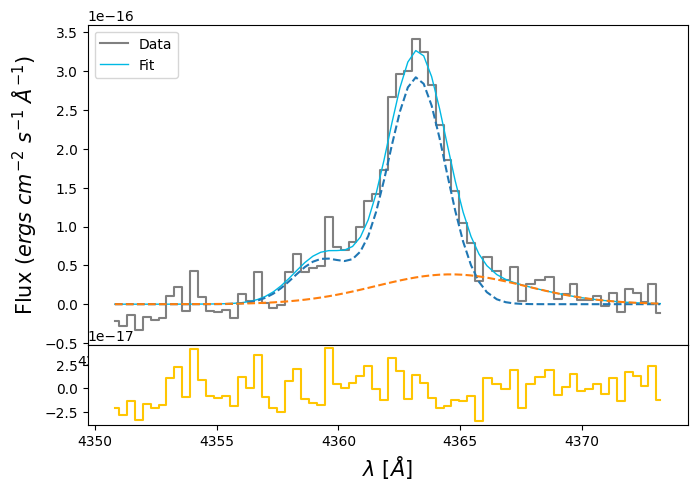

In [184]:
oiiic_nar_flux = out_oiiic.flatchain.Oiiic_nar.mean()
oiiic_nar_std = out_oiiic.flatchain.Oiiic_nar.std()

oiiic_brd_flux = out_oiiic.flatchain.Oiiic_brd.mean()
oiiic_brd_std = out_oiiic.flatchain.Oiiic_brd.std()

feii_4360_flux = out_oiiic.flatchain.Feii_4360_nar.mean()
feii_4360_std = out_oiiic.flatchain.Feii_4360_nar.std()

z_oiii = out_oiiic.flatchain.z_nar.mean()
z_oiii_std = out_oiiic.flatchain.z_nar.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4363.wavelength, oiii_4363.flux,
            color='gray', label='Data', where='mid')

feii_4360 = gaussian(oiii_4363.wavelength, feii_4360_flux, wave_cat['[FeII]4360'], z_oiii, upy.nominal_values(sigma_nar_4363))
oiiic_nar = gaussian(oiii_4363.wavelength, oiiic_nar_flux, wave_cat['[OIII]4363'], z_oiii, upy.nominal_values(sigma_nar_4363))
oiiic_brd = gaussian(oiii_4363.wavelength, oiiic_brd_flux, wave_cat['[OIII]4363'], z_oiii * z_ratio, upy.nominal_values(sigma_brd_4363))
oiiic = oiiic_nar + oiiic_brd

ax.plot(oiii_4363.wavelength, oiiic + feii_4360, lw=1, color=c[0], label='Fit')
ax.plot(oiii_4363.wavelength, oiiic_nar + feii_4360, ls='--')
ax.plot(oiii_4363.wavelength, oiiic_brd, ls='--')
ax1.step(oiii_4363.wavelength, oiii_4363.flux - oiiic - feii_4360, color=c[3], where='mid')
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
#ax.set_yscale('log')
ax.legend(loc='upper left')

# Temperatures and stuff

In [188]:
from magE.functions import TO3, TO2, ne, TN2, TS3, double_log_OH, log_NH_12
from magE.functions import calzetti2000 as k_cal

# Extinction
ext_cat = pd.read_csv(magePath+'results/dust_norm_cal_lines.csv')
index = np.argmax(ext_cat['galname'] == galname)
E_BV = ext_cat['E_BV'][index]

if E_BV < 0:
    E_BV = 0

In [189]:
med_E_BV = np.median(ext_cat['E_BV'][ext_cat['E_BV'] > 0])
i_E_BV = np.argmax(ext_cat['E_BV'] == med_E_BV)
print('Result = {:.2f}'.format(ufloat(ext_cat['E_BV'][i_E_BV], ext_cat['E_BV_err'][i_E_BV])))

Result = 0.12+/-0.01


In [190]:
oiiia_nar_chain = out_oiii_hei.flatchain.Oiiia_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]5007']))
oiiia_brd_chain = out_oiii_hei.flatchain.Oiiia_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]5007']))
oiiia_tot_chain = oiiia_nar_chain + oiiia_brd_chain

oiiib_nar_chain = out_oiii_4959.flatchain.Oiiib_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4959']))
oiiib_brd_chain = out_oiii_4959.flatchain.Oiiib_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4959']))
oiiib_tot_chain = oiiib_nar_chain + oiiib_brd_chain

oiiic_nar_chain = out_oiiic.flatchain.Oiiic_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4363']))
oiiic_brd_chain = out_oiiic.flatchain.Oiiic_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OIII]4363']))
oiiic_tot_chain = oiiic_nar_chain + oiiic_brd_chain

siia_nar_chain = out_sii.flatchain.Siia_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[SII]6730']))
siia_brd_chain = out_sii.flatchain.Siia_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[SII]6730']))
siia_tot_chain = siia_nar_chain + siia_brd_chain

siib_nar_chain = out_sii.flatchain.Siib_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[SII]6716']))
siib_brd_chain = out_sii.flatchain.Siib_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[SII]6716']))
siib_tot_chain = siib_nar_chain + siib_brd_chain

oiia_nar_chain = out_oii_7320.flatchain.Oiia_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]7330']))
oiia_brd_chain = out_oii_7320.flatchain.Oiia_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]7330']))
oiia_tot_chain = oiia_nar_chain + oiia_brd_chain

oiib_nar_chain = out_oii_7320.flatchain.Oiib_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]7319']))
oiib_brd_chain = out_oii_7320.flatchain.Oiib_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]7319']))
oiib_tot_chain = oiib_nar_chain + oiib_brd_chain

oiic_nar_chain = out_oii_3727.flatchain.Oiic_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3729']))
oiic_brd_chain = out_oii_3727.flatchain.Oiic_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3729']))
oiic_tot_chain = oiic_nar_chain + oiic_brd_chain

oiid_nar_chain = out_oii_3727.flatchain.Oiid_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3726']))
oiid_brd_chain = out_oii_3727.flatchain.Oiid_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[OII]3726']))
oiid_tot_chain = oiid_nar_chain + oiid_brd_chain

siiia_nar_chain = out_siiia.flatchain.Siiia_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]9532']))
siiia_brd_chain = out_siiia.flatchain.Siiia_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]9532']))
siiia_tot_chain = siiia_nar_chain + siiia_brd_chain

siiib_nar_chain = out_siiib.flatchain.Siiib_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]9069']))
siiib_brd_chain = out_siiib.flatchain.Siiib_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]9069']))
siiib_tot_chain = siiib_nar_chain + siiib_brd_chain

siiic_nar_chain = out_oi_siii.flatchain.Siiic_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]6312']))
siiic_brd_chain = out_oi_siii.flatchain.Siiic_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[SIII]6312']))
siiic_tot_chain = siiic_nar_chain + siiic_brd_chain

niia_nar_chain = out_ha_nii.flatchain.Niia_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[NII]6584']))
niia_brd_chain = out_ha_nii.flatchain.Niia_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[NII]6584']))
niia_tot_chain = niia_nar_chain + niia_brd_chain

niib_nar_chain = out_ha_nii.flatchain.Niia_nar[1000:] * out_ha_nii.flatchain.Niib_to_niia[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[NII]6548']))
niib_brd_chain = out_ha_nii.flatchain.Niia_brd[1000:] * out_ha_nii.flatchain.Niib_to_niia[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[NII]6548']))
niib_tot_chain = niib_nar_chain + niib_brd_chain

niic_nar_chain = out_nii.flatchain.Niic_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[NII]5755']))
niic_brd_chain = out_nii.flatchain.Niic_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['[NII]5755']))
niic_tot_chain = niic_nar_chain + niic_brd_chain

hb_nar_chain = out_hb.flatchain.Hb_nar[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['Hb']))
hb_brd_chain = out_hb.flatchain.Hb_brd[1000:] * 10**(0.4 * E_BV * k_cal(wave_cat['Hb']))
hb_tot_chain = hb_nar_chain + hb_brd_chain

In [191]:
t_OIII_nar = TO3(oiiia_nar_chain, oiiib_nar_chain, oiiic_nar_chain)
t_OIII_brd = TO3(oiiia_brd_chain, oiiib_brd_chain, oiiic_brd_chain)
t_OIII_tot = TO3(oiiia_tot_chain, oiiib_tot_chain, oiiic_tot_chain)

O2_H_nar = 10**(double_log_OH(oiiia_nar_chain, oiiib_nar_chain, hb_nar_chain, t_OIII_nar) - 12)
O2_H_brd = 10**(double_log_OH(oiiia_brd_chain, oiiib_brd_chain, hb_brd_chain, t_OIII_brd) - 12)
O2_H_tot = 10**(double_log_OH(oiiia_tot_chain, oiiib_tot_chain, hb_tot_chain, t_OIII_tot) - 12)

IO2_R_nar = 9.36 * (t_OIII_nar**0.44) * O2_H_nar * hb_nar_chain
IO2_R_brd = 9.36 * (t_OIII_brd**0.44) * O2_H_brd * hb_brd_chain
IO2_R_tot = 9.36 * (t_OIII_tot**0.44) * O2_H_tot * hb_tot_chain

den_nar = ne(siia_nar_chain, siib_nar_chain, t_OIII_nar)
den_brd = ne(siia_brd_chain, siib_brd_chain, t_OIII_brd)
den_tot = ne(siia_tot_chain, siib_tot_chain, t_OIII_tot)

t_OII_nar = TO2(oiia_nar_chain, oiib_nar_chain, oiic_nar_chain, oiid_nar_chain, den_nar, IO2_R_nar)
t_OII_brd = TO2(oiia_brd_chain, oiib_brd_chain, oiic_brd_chain, oiid_brd_chain, den_brd, IO2_R_brd)
t_OII_tot = TO2(oiia_tot_chain, oiib_tot_chain, oiic_tot_chain, oiid_tot_chain, den_tot, IO2_R_tot)

N_H_nar = 10**(log_NH_12(niia_nar_chain, niib_nar_chain, hb_nar_chain, t_OII_nar) - 12)
N_H_brd = 10**(log_NH_12(niia_brd_chain, niib_brd_chain, hb_brd_chain, t_OII_brd) - 12)
N_H_tot = 10**(log_NH_12(niia_tot_chain, niib_tot_chain, hb_tot_chain, t_OII_tot) - 12)

IN2_R_nar = 3.19 * ((t_OII_nar*10000)**0.30) * N_H_nar * hb_nar_chain
IN2_R_brd = 3.19 * ((t_OII_brd*10000)**0.30) * N_H_brd * hb_brd_chain
IN2_R_tot = 3.19 * ((t_OII_tot*10000)**0.30) * N_H_tot * hb_tot_chain

t_SIII_nar = TS3(siiia_nar_chain, siiib_nar_chain, siiic_nar_chain)
t_SIII_brd = TS3(siiia_brd_chain, siiib_brd_chain, siiic_brd_chain)
t_SIII_tot = TS3(siiia_tot_chain, siiib_tot_chain, siiic_tot_chain)

t_NII_nar = TN2(niia_nar_chain, niib_nar_chain, niic_nar_chain, IN2_R_nar)
t_NII_brd = TN2(niia_brd_chain, niib_brd_chain, niic_brd_chain, IN2_R_brd)
t_NII_tot = TN2(niia_tot_chain, niib_tot_chain, niic_tot_chain, IN2_R_tot)

/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/numpy/lib/histograms.py:824: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/numpy/lib/histograms.py:825: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


Text(0.5, 0, 'T[NII]$_{tot}$ (10$^{4}$ K)')

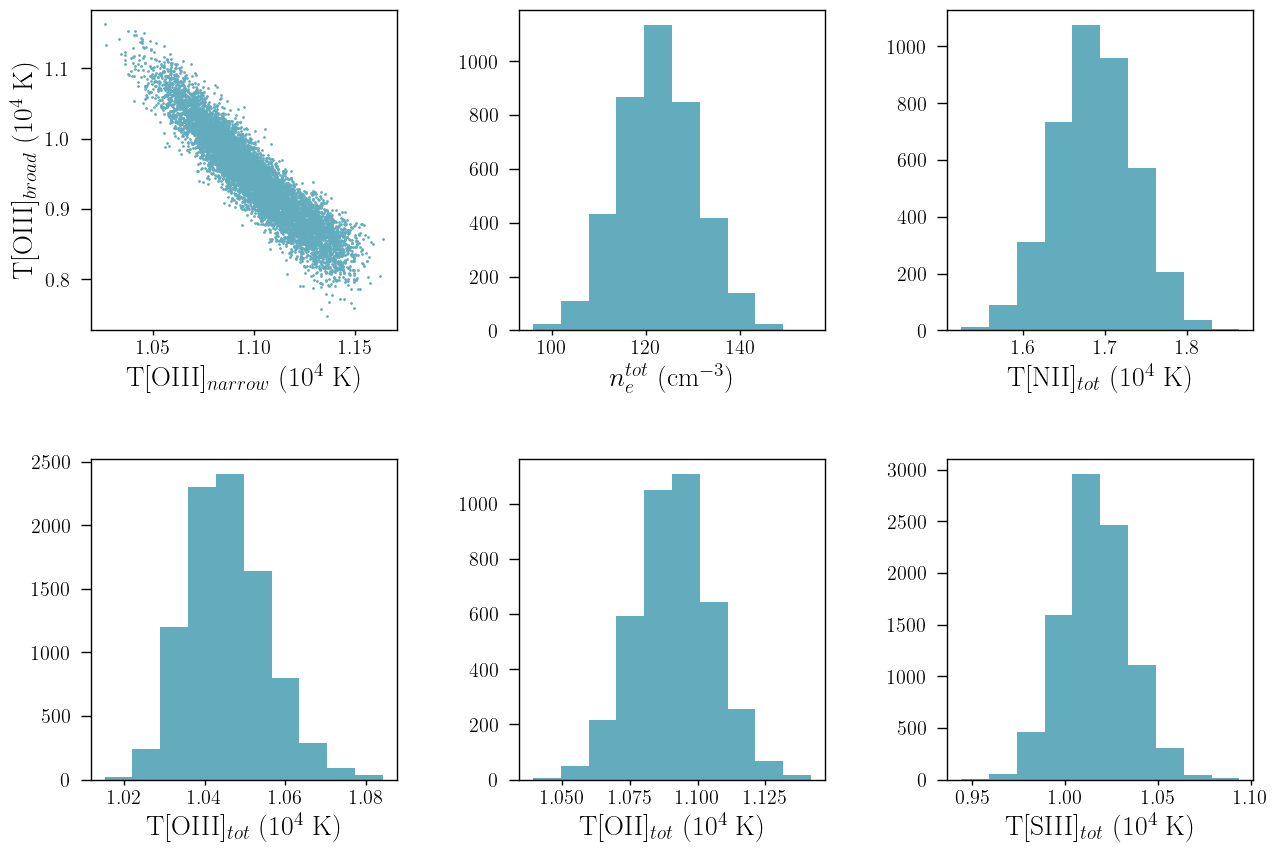

In [192]:
texPlot('on')
fig, axs = plt.subplots(2, 3)
fig.set_size_inches((15, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.4)

axs[0, 0].scatter(t_OIII_nar, t_OIII_brd, s=1, color=cr[2])
axs[0, 0].set_xlabel(r'T[OIII]$_{narrow}$ (10$^{4}$ K)')
axs[0, 0].set_ylabel(r'T[OIII]$_{broad}$ (10$^{4}$ K)')

axs[1, 0].hist(t_OIII_tot, color=cr[2])
axs[1, 0].set_xlabel(r'T[OIII]$_{tot}$ (10$^{4}$ K)')

axs[0, 1].hist(den_tot, color=cr[2])
axs[0, 1].set_xlabel(r'$n_{e}^{tot}$ (cm$^{-3}$)')

axs[1, 1].hist(t_OII_tot, color=cr[2])
axs[1, 1].set_xlabel(r'T[OII]$_{tot}$ (10$^{4}$ K)')

axs[1, 2].hist(t_SIII_tot, color=cr[2])
axs[1, 2].set_xlabel(r'T[SIII]$_{tot}$ (10$^{4}$ K)')

axs[0, 2].hist(t_NII_tot, color=cr[2])
axs[0, 2].set_xlabel(r'T[NII]$_{tot}$ (10$^{4}$ K)')

In [193]:
t_OIII_nar_mean = np.nanpercentile(t_OIII_nar, 50)
t_OIII_nar_16 = np.nanpercentile(t_OIII_nar, 16)
t_OIII_nar_84 = np.nanpercentile(t_OIII_nar, 84)

t_OIII_brd_mean = np.nanpercentile(t_OIII_brd, 50)
t_OIII_brd_16 = np.nanpercentile(t_OIII_brd, 16)
t_OIII_brd_84 = np.nanpercentile(t_OIII_brd, 84)

t_OIII_tot_mean = np.nanpercentile(t_OIII_tot, 50)
t_OIII_tot_16 = np.nanpercentile(t_OIII_tot, 16)
t_OIII_tot_84 = np.nanpercentile(t_OIII_tot, 84)

t_OII = np.nanpercentile(t_OII_tot, 50)
t_OII_16 = np.nanpercentile(t_OII_tot, 16)
t_OII_84 = np.nanpercentile(t_OII_tot, 84)

density = np.nanpercentile(den_tot, 50)
density_16 = np.nanpercentile(den_tot, 16)
density_84 = np.nanpercentile(den_tot, 84)

t_NII = np.nanpercentile(t_NII_tot, 50)
t_NII_16 = np.nanpercentile(t_NII_tot, 16)
t_NII_84 = np.nanpercentile(t_NII_tot, 84)

t_SIII = np.nanpercentile(t_SIII_tot, 50)
t_SIII_16 = np.nanpercentile(t_SIII_tot, 16)
t_SIII_84 = np.nanpercentile(t_SIII_tot, 84)

In [194]:
temden_dict = {'galname': galname,
               'tOIII_nar': t_OIII_nar_mean,
               'tOIII_nar_16': t_OIII_nar_16,
               'tOIII_nar_84': t_OIII_nar_84,
               'tOIII_brd': t_OIII_brd_mean,
               'tOIII_brd_16': t_OIII_brd_16,
               'tOIII_brd_84': t_OIII_brd_84,
               'tOIII_tot': t_OIII_tot_mean,
               'tOIII_tot_16': t_OIII_tot_16,
               'tOIII_tot_84': t_OIII_tot_84,
               'tOII': t_OII,
               'tOII_16': t_OII_16,
               'tOII_84': t_OII_84,
               'ne': density,
               'ne_16': density_16,
               'ne_84': density_84,
               'tNII': t_NII,
               'tNII_16': t_NII_16,
               'tNII_84': t_NII_84,
               'tSIII': t_SIII,
               'tSIII_16': t_SIII_16,
               'tSIII_84': t_SIII_84,
}
temden_dict_pd = pd.DataFrame(data=temden_dict, index=[0])
save_catalog(galname, temden_dict_pd, magePath + '/results/metals/temden_final_subspec.csv')

File does not exist, creating new catalog...
Done.


In [195]:
# Velocities
vel = {'galname': galname,
       'dV': dV_4959.nominal_value,
       'dV_err': dV_4959.std_dev,
       'FWHM_nar': FWHM_4959_nar.nominal_value,
       'FWHM_nar_err': FWHM_4959_nar.std_dev,
       'FWHM_brd': FWHM_4959_brd.nominal_value,
       'FWHM_brd_err': FWHM_4959_brd.std_dev
}

vel_catalog_pd = pd.DataFrame(data=vel, index=[0])
save_catalog(galname, vel_catalog_pd, magePath + '/results/vel_catalog_subspec.csv')

File does not exist, creating new catalog...
Done.


In [229]:
ufloat(ha_nar_flux, ha_nar_std) + ufloat(ha_brd_flux, ha_nar_std)

1.1361362494009987e-13+/-1.653766214789412e-16

In [230]:
4.0204e-14 + 8.3200e-14

1.23404e-13

In [235]:
(1.23404e-13 - 1.1361362494009987e-13) / 1.653766214789412e-16

59.200478110788